In [24]:
import os
import scipy.stats 
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# Setup

### Config

In [25]:
# ============================================================
# CONFIG
# ============================================================
# All paths, group names, and output identifiers are defined
# here. Update this cell when running on a new system or
# moving data directories. Nothing below this cell should
# contain hardcoded paths or group identifiers.
# ============================================================

# --- Shared output directory ---
# Must match OUTPUT_DIR used in the modeling notebook
OUTPUT_DIR = Path("../maize_outputs/model_outputs")

# --- Network-specific output directory ---
# Individual network plots, heatmaps, and edge tables are
# saved here. Created automatically if it does not exist.
# Kept local and regenerable — not tracked in git (see .gitignore).
NETWORK_DIR = Path("../maize_outputs/network_output")
os.makedirs(NETWORK_DIR, exist_ok=True)

# --- Group definitions ---
# ORDER MATTERS: the 2x2 combined figure uses indices 1-4 (Groups I-IV).
# "All" is included for individual plots only.
GROUPS = ["All", "I", "II", "III", "IV"]

GROUP_LABELS = {
    "All": "All Maize1/Maize2",
    "I":   "Group I",
    "II":  "Group II",
    "III": "Group III",
    "IV":  "Group IV",
}

PREFIXES = {
    "All": "groupAll",
    "I":   "groupI",
    "II":  "groupII",
    "III": "groupIII",
    "IV":  "groupIV",
}

# --- .npz file paths (one per group, produced by modeling notebook) ---
NPZ_PATHS = {
    group: os.path.join(OUTPUT_DIR, f"{PREFIXES[group]}_shap_by_label.npz")
    for group in GROUPS
}

# --- Validate all files exist before proceeding ---
missing_files = [path for path in NPZ_PATHS.values() if not os.path.exists(path)]
if missing_files:
    raise FileNotFoundError(
        f"The following .npz files were not found. Run the modeling notebook "
        f"for each group before proceeding:\n" +
        "\n".join(missing_files)
    )
else:
    print("All .npz files found:")
    for group, path in NPZ_PATHS.items():
        print(f"  {group}: {path}")

All .npz files found:
  All: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs/groupAll_shap_by_label.npz
  I: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs/groupI_shap_by_label.npz
  II: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs/groupII_shap_by_label.npz
  III: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs/groupIII_shap_by_label.npz
  IV: /blue/meixiazhao/laylaaschuster/maizeGDM/final_models/model_outputs/groupIV_shap_by_label.npz


### Load Data

In [26]:
# ==========================================================================
# LOAD DATA
# ==========================================================================
# Loads SHAP arrays and feature names from .npz files
# produced by the modeling notebook. All five groups are
# loaded into a single dict for clean downstream access.
#
# Keys available per group after loading:
#   shap_data[group]["shap_all"]      — full SHAP array (all samples)
#   shap_data[group]["shap_label0"]   — SHAP for WGD=0 (Maize1, dominant)
#   shap_data[group]["shap_label1"]   — SHAP for WGD=1 (Maize2, submissive)
#   shap_data[group]["feature_names"] — feature name array
#   shap_data[group]["counts"]        — [n_label0, n_label1]
#   shap_data[group]["shap_interaction_all"] — Shapley interaction values (all samples),
#                                               shape (n_samples, n_features, n_features)
#   shap_data[group]["true_labels"]          — label vector aligned to shap_all rows 
#                                              (0=Maize1/dominant, 1=Maize2/submissive)
#   shap_data[group]["shap_interaction_label0"] — interaction values for Maize1 samples only
#   shap_data[group]["shap_interaction_label1"] — interaction values for Maize2 samples only
# ==========================================================================

shap_data = {}

for group in GROUPS:
    path = NPZ_PATHS[group]
    data = np.load(path, allow_pickle=False)

    shap_data[group] = {
        "shap_all"             : data["shap_all"].astype(np.float64),
        "shap_label0"          : data["shap_label0"].astype(np.float64),
        "shap_label1"          : data["shap_label1"].astype(np.float64),
        "shap_interaction_all" : data["shap_interaction_all"].astype(np.float64),
        "true_labels"          : data["true_labels"].astype(np.int8),
        "feature_names"        : data["feature_names"].tolist(),
        "counts"               : data["counts"],
    }

    print(f"Group {group}:")
    print(f"  shap_all    : {shap_data[group]['shap_all'].shape}")
    print(f"  shap_label0 : {shap_data[group]['shap_label0'].shape}")
    print(f"  shap_label1 : {shap_data[group]['shap_label1'].shape}")
    print(f"  n_features  : {len(shap_data[group]['feature_names'])}")
    print(f"  counts      : label0={shap_data[group]['counts'][0]}, "
          f"label1={shap_data[group]['counts'][1]}")
    
    print(f"  shap_interaction_all: {shap_data[group]['shap_interaction_all'].shape}")

    # --- Symmetry check ---
    # Shapley interaction values are symmetric by definition (φ_jk = φ_kj).
    # Numerical precision can introduce small asymmetries; tolerance of 1e-4
    # is appropriate for float32 data cast to float64.
    interact = shap_data[group]["shap_interaction_all"]
    max_asymmetry = np.abs(interact - interact.transpose(0, 2, 1)).max()
    assert max_asymmetry < 1e-4, (
        f"Group {group}: interaction matrix asymmetry {max_asymmetry:.2e} "
        f"exceeds tolerance. Check shap_interaction_values() output."
    )
    print(f"  symmetry check passed (max asymmetry: {max_asymmetry:.2e})")
    print()
    
    # --- Split interaction array by subgenome label ---
    # Allows label-specific network analysis downstream.
    # Biological motivation: dominant (Maize1) and submissive (Maize2)
    # subgenomes may show asymmetric feature interactions — averaging
    # across labels could suppress subgenome-specific signal.
    _labels = shap_data[group]["true_labels"]
    _mask0  = (_labels == 0)
    _mask1  = (_labels == 1)
    shap_data[group]["shap_interaction_label0"] = (
        shap_data[group]["shap_interaction_all"][_mask0]
    )
    shap_data[group]["shap_interaction_label1"] = (
        shap_data[group]["shap_interaction_all"][_mask1]
    )
    print(f"  shap_interaction_label0: {shap_data[group]['shap_interaction_label0'].shape}")
    print(f"  shap_interaction_label1: {shap_data[group]['shap_interaction_label1'].shape}")

# --- Validate expected feature counts ---
# 'all' group includes 'location' (60 features total).
# Groups I-IV exclude 'location' (59 features each).
# These counts reflect the finalized preprocessing output.
# If either check fails, the modeling notebook was run with
# the wrong preprocessing file or USE_LOCATION setting.
EXPECTED_FEATURES_ALL    = 60
EXPECTED_FEATURES_GROUPS = 59

n_all = len(shap_data["All"]["feature_names"])
if n_all != EXPECTED_FEATURES_ALL:
    raise ValueError(
        f"Group 'all' has {n_all} features, expected {EXPECTED_FEATURES_ALL}. "
        f"Check USE_LOCATION=True was set when running the 'all' model."
    )

for group in GROUPS[1:]:
    n = len(shap_data[group]["feature_names"])
    if n != EXPECTED_FEATURES_GROUPS:
        raise ValueError(
            f"Group {group} has {n} features, expected {EXPECTED_FEATURES_GROUPS}. "
            f"Check USE_LOCATION=False was set when running this model."
        )

print(f"Feature count validation passed:")
print(f"  'all' group : {n_all} features (includes 'location')")
for group in GROUPS[1:]:
    print(f"  Group {group}    : {len(shap_data[group]['feature_names'])} features")
    
# --- Validate feature names are identical across all groups ---
# 'location' is excluded from Groups I-IV (USE_LOCATION=False for those groups)
# but present in the 'all' group. Validation checks the shared feature set only.
reference_features_no_loc = [f for f in shap_data["All"]["feature_names"]
                              if f != "location"]

for group in GROUPS[1:]:
    group_features = shap_data[group]["feature_names"]
    if group_features != reference_features_no_loc:
        raise ValueError(
            f"Feature names for Group {group} do not match the expected "
            f"shared feature set (excluding 'location'). Check that all "
            f"groups were preprocessed with the same pipeline."
        )

print("Feature name validation passed: all groups share identical feature names "
      "(excluding 'location', which is present in 'all' only).")

# --- Extract shared feature names as a plain list ---
# Each group's feature_names is used directly when passed to downstream
# functions — do not use a single shared list, since 'all' differs from
# Groups I-IV by the presence of 'location'.
feature_names = {group: shap_data[group]["feature_names"] for group in GROUPS}
print("Feature name dict built for all groups.")

Group All:
  shap_all    : (7072, 60)
  shap_label0 : (3536, 60)
  shap_label1 : (3536, 60)
  n_features  : 60
  counts      : label0=3536, label1=3536
  shap_interaction_all: (7072, 60, 60)
  symmetry check passed (max asymmetry: 9.87e-08)

  shap_interaction_label0: (3536, 60, 60)
  shap_interaction_label1: (3536, 60, 60)
Group I:
  shap_all    : (4292, 59)
  shap_label0 : (2146, 59)
  shap_label1 : (2146, 59)
  n_features  : 59
  counts      : label0=2146, label1=2146
  shap_interaction_all: (4292, 59, 59)
  symmetry check passed (max asymmetry: 3.78e-07)

  shap_interaction_label0: (2146, 59, 59)
  shap_interaction_label1: (2146, 59, 59)
Group II:
  shap_all    : (724, 59)
  shap_label0 : (362, 59)
  shap_label1 : (362, 59)
  n_features  : 59
  counts      : label0=362, label1=362
  shap_interaction_all: (724, 59, 59)
  symmetry check passed (max asymmetry: 1.56e-07)

  shap_interaction_label0: (362, 59, 59)
  shap_interaction_label1: (362, 59, 59)
Group III:
  shap_all    : (1156,

### Global Statistical Parameters

In [27]:
# ============================================================
# GLOBAL STATISTICAL PARAMETERS
# ============================================================
# These constants control the significance thresholds across
# all network generation and plotting functions.

# Co-variation Networks (Permutation)
ALPHA_PERMUTATION = 0.05
N_PERMUTATIONS    = 1000

# Interaction Networks (Effect Size)
K_INTERACTION     = 12

### Feature Definitions

In [28]:
# ============================================================
# FEATURE DEFINITIONS
# ============================================================
# All downstream cells reference these dictionaries.
# Do not redefine feature_rename_dict, feature_groups,
# feature_to_group, group_to_color, or renamed_feature_names
# anywhere else in this notebook.
#
# Feature names reflect the updated preprocessing output.
# renamed_feature_names is a dict keyed by group because
# the 'All' group includes 'location' while Groups I-IV
# do not.
# ============================================================

# --- Short display names for all features ---
feature_rename_dict = {
    'location':             'Loc',
    'GC_genic':             'GCd',
    'GC_prom':              'GCp',
    'avg_expression':       'Exp',
    'tau':                  '\u03C4',
    'Ka':                   'Ka',
    'Ks':                   'Ks',
    'O':                    '\u03C9',
    'acr_Lup':              'ACRdu',
    'acr_Ldown':            'ACRdd',
    'acr_S':                'ACRs',
    'recomb':               'Re',
    'CHH_up_avg':           'M1',
    'CHH_down_avg':         'M2',
    'CHH_body_avg':         'M3',
    'CHG_up_avg':           'M4',
    'CHG_down_avg':         'M5',
    'CHG_body_avg':         'M6',
    'CG_up_avg':            'M7',
    'CG_down_avg':          'M8',
    'CG_body_avg':          'M9',
    'CHH_up_max':           'M10',
    'CHH_down_max':         'M11',
    'CHG_up_max':           'M12',
    'CHG_down_max':         'M13',
    'CG_up_max':            'M14',
    'CG_down_max':          'M15',
    'TEdist':               'TEdi',
    'TEdenseAvgUp':         'TEu1',
    'TEdenseAvgDown':       'TEd1',
    'TEdenseMaxUp':         'TEu2',
    'TEdenseMaxDown':       'TEd2',
    'TE1':                  'TE1',
    'TE2':                  'TE2',
    'TE3':                  'TE3',
    'TE4':                  'TE4',
    'H2AZ_down':            'Hd1',
    'H3K4me1_down':         'Hd2',
    'H3K4me3_down':         'Hd3',
    'H3K9ac_down':          'Hd4',
    'H3K27ac_down':         'Hd5',
    'H3K27me3_down':        'Hd6',
    'H3K36me3_down':        'Hd7',
    'H3K56ac_down':         'Hd8',
    'H2AZ_genebody':        'Hg1',
    'H3K4me1_genebody':     'Hg2',
    'H3K4me3_genebody':     'Hg3',
    'H3K9ac_genebody':      'Hg4',
    'H3K27ac_genebody':     'Hg5',
    'H3K27me3_genebody':    'Hg6',
    'H3K36me3_genebody':    'Hg7',
    'H3K56ac_genebody':     'Hg8',
    'H2AZ_up':              'Hu1',
    'H3K4me1_up':           'Hu2',
    'H3K4me3_up':           'Hu3',
    'H3K9ac_up':            'Hu4',
    'H3K27ac_up':           'Hu5',
    'H3K27me3_up':          'Hu6',
    'H3K36me3_up':          'Hu7',
    'H3K56ac_up':           'Hu8',
}

# --- Feature group membership ---
feature_groups = {
    'ACR': [
        'acr_Lup', 'acr_Ldown', 'acr_S',
    ],
    'Methylation': [
        'CHH_up_avg', 'CHH_down_avg', 'CHH_body_avg',
        'CHG_up_avg', 'CHG_down_avg', 'CHG_body_avg',
        'CG_up_avg',  'CG_down_avg',  'CG_body_avg',
        'CHH_up_max', 'CHH_down_max',
        'CHG_up_max', 'CHG_down_max',
        'CG_up_max',  'CG_down_max',
    ],
    'TE': [
        'TEdenseAvgUp', 'TEdenseAvgDown',
        'TEdenseMaxUp', 'TEdenseMaxDown',
        'TE1', 'TE2', 'TE3', 'TE4',
        'TEdist',
    ],
    'Histone Modifications Downstream': [
        'H2AZ_down',    'H3K4me1_down',  'H3K4me3_down',  'H3K9ac_down',
        'H3K27ac_down', 'H3K27me3_down', 'H3K36me3_down', 'H3K56ac_down',
    ],
    'Histone Modifications Genebody': [
        'H2AZ_genebody',    'H3K4me1_genebody',  'H3K4me3_genebody',  'H3K9ac_genebody',
        'H3K27ac_genebody', 'H3K27me3_genebody', 'H3K36me3_genebody', 'H3K56ac_genebody',
    ],
    'Histone Modifications Upstream': [
        'H2AZ_up',    'H3K4me1_up',  'H3K4me3_up',  'H3K9ac_up',
        'H3K27ac_up', 'H3K27me3_up', 'H3K36me3_up', 'H3K56ac_up',
    ],
    'Recombination':        ['recomb'],
    'Evolutionary Pressure': ['Ka', 'Ks', 'O'],
    'Location':             ['location'],
    'GC Content':           ['GC_genic', 'GC_prom'],
    'Expression':           ['avg_expression', 'tau'],
}

# --- Derived lookups (do not edit below this line) ---

# Maps each feature name to its group label
feature_to_group = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

# Assigns one color per group — consistent across all plots
_n_groups   = len(feature_groups)
_group_cmap = plt.colormaps['tab20b'](np.linspace(0, 1, _n_groups))
group_to_color = {
    group: color
    for group, color in zip(feature_groups.keys(), _group_cmap)
}

# Short display names for each group's active feature set
# Dict keyed by group because 'all' includes 'location',
# Groups I-IV do not
renamed_feature_names = {
    group: [feature_rename_dict.get(f, f) for f in feature_names[group]]
    for group in GROUPS
}

# --- Validation: warn if any active feature is missing from rename dict ---
all_missing = {}
for group in GROUPS:
    missing = [f for f in feature_names[group] if f not in feature_rename_dict]
    if missing:
        all_missing[group] = missing

if all_missing:
    print("WARNING: the following features are missing from feature_rename_dict")
    print("and will display raw column names on plots:")
    for group, missing in all_missing.items():
        print(f"  Group {group}: {missing}")
else:
    print("Feature rename dict validated: all active features have short names.")

print(f"\nGroups defined      : {len(feature_groups)}")
print(f"Features — 'all'      : {len(feature_names['All'])}")
print(f"Features — I-IV       : {len(feature_names['I'])}")

Feature rename dict validated: all active features have short names.

Groups defined      : 11
Features — 'all'      : 60
Features — I-IV       : 59


# Covariate Processing

## Network Helper Functions

In [29]:
# ============================================================
# NETWORK HELPER FUNCTIONS
# ============================================================
# Utility functions used by all network plotting cells.
# Define once here — do not redefine in downstream cells.
# ============================================================

def assign_colour(correlation):
    """
    Returns edge color based on sign of SHAP co-variation score.
    Positive co-variation (features vary together): red/pink.
    Negative co-variation (features vary in opposition): blue.
    """
    if correlation > 0:
        return "#ffa09b"   # red/pink — positive co-variation
    else:
        return "#0047ab"   # blue — negative co-variation


def assign_node_size(degree, scaling_factor=200):
    """
    Returns node size scaled linearly by degree.
    scaling_factor controls the size range across all panels
    and must be consistent across all calls for a shared legend
    to be interpretable.
    """
    return degree * scaling_factor


def assign_node_colors_by_group(
    Gx,
    feature_to_group,
    group_to_color,
    fallback_color=(0.5, 0.5, 0.5, 1.0)
):
    """
    Returns a list of colors for each node in Gx, based on
    the feature group the node belongs to. Nodes not found
    in feature_to_group receive the fallback gray color.
    Color order matches the node iteration order of Gx.
    """
    node_colors = []
    for node in Gx.nodes():
        group = feature_to_group.get(node)
        color = group_to_color.get(group, fallback_color)
        node_colors.append(color)
    return node_colors


def make_colors_transparent(color_list, alpha=0.5):
    """
    Applies a uniform alpha value to a list of colors.
    Accepts any matplotlib-compatible color format.
    Returns a list of RGBA tuples.
    """
    return [mcolors.to_rgba(c, alpha=alpha) for c in color_list]


def plot_clustered_heatmap(
    matrix_df,
    title,
    save_path,
    colorbar_label = 'Value',
):
    """
    Shared core heatmap function. Called by plot_covariate_heatmap()
    and plot_interaction_heatmap() — do not call directly from
    analysis loops.

    Clusters rows and columns independently using Ward linkage +
    Euclidean distance. Colorscale is symmetric around zero.
    For symmetric input matrices, row and column dendrograms
    must be identical — confirmed by assert.

    Parameters
    ----------
    matrix_df      : pd.DataFrame, shape (n_features, n_features)
                     Square matrix with short feature labels as
                     index and columns. Diagonal must already be
                     zeroed by the calling wrapper.
    title          : str
    save_path      : str
    colorbar_label : str
    """
    abs_max = np.abs(matrix_df.values).max()

    cg = sns.clustermap(
        matrix_df,
        method      = 'ward',
        metric      = 'euclidean',
        cmap        = 'RdBu_r',
        center      = 0,
        vmin        = -abs_max,
        vmax        =  abs_max,
        figsize     = (20, 20),
        xticklabels = True,
        yticklabels = True,
        linewidths  = 0,
        cbar_kws    = {'label': colorbar_label},
    )

    # --- Dendrogram symmetry assert ---
    # Both the co-variation matrix and the interaction matrix are
    # symmetric by construction. Row and column linkages must
    # therefore be identical. A failure indicates the input matrix
    # was not symmetric — check the calling wrapper.
    assert np.allclose(
        cg.dendrogram_row.linkage,
        cg.dendrogram_col.linkage,
        atol = 1e-5,
    ), (
        f"Row and column dendrograms differ for: {title}\n"
        f"Input matrix may not be symmetric."
    )
    print(f"  Dendrogram symmetry confirmed.")

    cg.ax_heatmap.set_xticklabels(
        cg.ax_heatmap.get_xticklabels(),
        fontsize = 7,
        rotation = 90,
    )
    cg.ax_heatmap.set_yticklabels(
        cg.ax_heatmap.get_yticklabels(),
        fontsize = 7,
        rotation = 0,
    )
    cg.ax_heatmap.set_title(title, fontsize=13, fontweight='bold', pad=12)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()
    plt.close('all')

## Co-variate Matrix Function

In [30]:
# ============================================================
# CO-VARIATION MATRIX FUNCTION
# ============================================================
# Computes the pairwise SHAP co-variation matrix from a SHAP
# value array. This matrix is the foundation for both the
# heatmap and network analyses.
#
# IMPORTANT — terminology and methods note:
# This matrix is computed as a normalized dot product of SHAP
# value vectors across samples. Entry (j, k) reflects how
# consistently features j and k vary together in their SHAP
# importance across the test set. This is NOT equivalent to
# Shapley interaction indices, which would require calling
# TreeExplainer.shap_interaction_values() at inference time
# and scales quadratically in both features and samples.
# This metric is referred to throughout as the "SHAP
# co-variation score" to distinguish it from true Shapley
# interaction values. See methods section for full discussion.
# ============================================================

def compute_covariation_matrix(shap_array, feature_labels):
    """
    Compute the pairwise SHAP co-variation matrix.

    The matrix entry (j, k) is defined as:
        (1 / n_samples) * sum_i [ shap_i_j * shap_i_k ]
    where shap_i_j is the SHAP value for sample i and feature j.
    This is equivalent to the unnormalized sample covariance of
    SHAP vectors (with mean NOT subtracted), implemented
    efficiently via einsum.

    Parameters
    ----------
    shap_array    : np.ndarray, shape (n_samples, n_features)
                    SHAP value matrix for one group and one label
                    set (all samples, label0, or label1).
    feature_labels: list of str
                    Feature names corresponding to columns of
                    shap_array. Must match shap_array.shape[1].

    Returns
    -------
    covariation_df : pd.DataFrame, shape (n_features, n_features)
                     Co-variation matrix with feature_labels as
                     both index and columns.
    covariation_scores : pd.Series
                     Upper-triangle values only (excluding diagonal),
                     indexed by (feature_i, feature_j) pairs.
                     Used directly by significance testing and
                     heatmap functions.
    """
    assert shap_array.ndim == 2, \
        f"shap_array must be 2D, got shape {shap_array.shape}"
    assert shap_array.shape[1] == len(feature_labels), \
        (f"shap_array has {shap_array.shape[1]} columns but "
         f"{len(feature_labels)} feature labels were provided.")

    # --- Compute co-variation matrix ---
    # Result shape: (n_features, n_features)
    # Diagonal entries are the mean squared SHAP values per feature
    # (always positive). Off-diagonal entries reflect co-variation
    # in importance between feature pairs.
    shap_interaction = (
        np.einsum('ij,ik->jk', shap_array, shap_array)
        / shap_array.shape[0]
    )

    covariation_df = pd.DataFrame(
        shap_interaction,
        index   = feature_labels,
        columns = feature_labels
    )

    # --- Extract upper triangle (unique feature pairs only) ---
    # Diagonal excluded (k=1) to avoid self-co-variation inflating
    # the null distribution in significance testing.
    upper_mask = np.triu(np.ones(covariation_df.shape), k=1).astype(bool)
    covariation_scores = covariation_df.where(upper_mask).stack()

    # --- Diagnostic summary ---
    print(f"  Co-variation matrix shape : {shap_interaction.shape}")
    print(f"  Max score                 : {shap_interaction.max():.6f}")
    print(f"  Min score                 : {shap_interaction.min():.6f}")
    print(f"  Unique feature pairs      : {len(covariation_scores)}")
    print(f"  Mean abs score            : {np.abs(covariation_scores).mean():.6f}")
    print(f"  Std abs score             : {np.abs(covariation_scores).std():.6f}")

    return covariation_df, covariation_scores 

## Compute Co-variate Matrices

In [31]:
# ============================================================
# COMPUTE CO-VARIATION MATRICES
# ============================================================
# Calls compute_covariation_matrix() once per group and stores
# results in covariation_data, keyed by group name.
#
# All downstream cells (heatmap, permutation
# network) read from covariation_data — the matrix is never
# recomputed. This ensures all analyses are derived from an
# identical matrix for each group.
#
# covariation_data[group] keys:
#   "covariation_df"     : pd.DataFrame (n_features x n_features)
#                          full co-variation matrix
#   "covariation_scores" : pd.Series
#                          upper-triangle values, indexed by
#                          (feature_i, feature_j) pairs
# ============================================================

covariation_data = {}

for group in GROUPS:
    print(f"\n--- Group {group} ({GROUP_LABELS[group]}) ---")

    covariation_data[group] = {}

    shap_array     = shap_data[group]["shap_all"]
    feat_labels    = feature_names[group]

    covariation_df, covariation_scores = compute_covariation_matrix(
        shap_array     = shap_array,
        feature_labels = feat_labels,
    )

    covariation_data[group]["covariation_df"]     = covariation_df
    covariation_data[group]["covariation_scores"] = covariation_scores

    # Save upper-triangle scores as CSV for supplemental reference
    scores_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_covariation_scores.csv"
    )
    covariation_scores.rename(
        index=lambda x: feature_rename_dict.get(x, x)
    ).to_csv(scores_path, header=["covariation_score"])
    print(f"  Saved scores: {scores_path}")

print("\nAll co-variation matrices computed and stored in covariation_data.")


--- Group All (All Maize1/Maize2) ---
  Co-variation matrix shape : (60, 60)
  Max score                 : 0.013203
  Min score                 : -0.000013
  Unique feature pairs      : 1770
  Mean abs score            : 0.000001
  Std abs score             : 0.000010
  Saved scores: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_covariation_scores.csv

--- Group I (Group I) ---
  Co-variation matrix shape : (59, 59)
  Max score                 : 0.611113
  Min score                 : -0.001673
  Unique feature pairs      : 1711
  Mean abs score            : 0.000059
  Std abs score             : 0.000168
  Saved scores: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_covariation_scores.csv

--- Group II (Group II) ---
  Co-variation matrix shape : (59, 59)
  Max score                 : 0.165486
  Min score                 : -0.001057
  Unique feature pairs      : 1711
  Mean abs score            : 0.000041
  Std abs score             : 0.000113
  Saved 

## Covariate Heatmaps

In [32]:
# ============================================================
# COVARIATE HEATMAPS — ONE PER GROUP
# ============================================================
# For each group, plots a clustered heatmap of the full
# pairwise SHAP co-variation matrix computed in Cell 10.
#
# The diagonal is zeroed before plotting — self-covariation
# (mean(shap_j^2)) is always positive and would compress the
# colorscale, obscuring the between-feature signal.
#
# These heatmaps are complementary to the co-variation networks:
# networks show only significant pairs (permutation p<=0.05),
# heatmaps show the full co-variation landscape regardless of
# significance. Clustering uses Ward linkage + Euclidean
# distance, independently per group.
#
# plot_covariate_heatmap() wraps plot_clustered_heatmap().
# ============================================================


def plot_covariate_heatmap(
    covariation_df,
    feature_rename_dict,
    title,
    save_path,
):
    """
    Thin wrapper for covariate heatmaps.

    Zeros the diagonal of the co-variation matrix, renames
    features to short display names, then calls
    plot_clustered_heatmap().

    Parameters
    ----------
    covariation_df      : pd.DataFrame, shape (n_features, n_features)
                          Full co-variation matrix from covariation_data.
    feature_rename_dict : dict, original name -> short display name
    title               : str
    save_path           : str
    """
    matrix = covariation_df.copy()
    np.fill_diagonal(matrix.values, 0)
    short_labels   = [feature_rename_dict.get(f, f) for f in matrix.index]
    matrix.index   = short_labels
    matrix.columns = short_labels
    plot_clustered_heatmap(
        matrix_df      = matrix,
        title          = title,
        save_path      = save_path,
        colorbar_label = 'SHAP co-variation score',
    )


# --- Generate one heatmap per group ---

from unittest.mock import patch

with patch('matplotlib.pyplot.show'):
    for group in GROUPS:
        print(f"\n--- Group {group} ({GROUP_LABELS[group]}) ---")
        plot_covariate_heatmap(
            covariation_df      = covariation_data[group]["covariation_df"],
            feature_rename_dict = feature_rename_dict,
            title               = (
                f"SHAP Co-variation Heatmap — {GROUP_LABELS[group]}"
            ),
            save_path           = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}_covariation_heatmap.png"
            ),
        )


--- Group All (All Maize1/Maize2) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_covariation_heatmap.png

--- Group I (Group I) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_covariation_heatmap.png

--- Group II (Group II) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_covariation_heatmap.png

--- Group III (Group III) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_covariation_heatmap.png

--- Group IV (Group IV) ---
  Dendrogram symmetry confirmed.
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_covariation_heatmap.png


# Covariate Networks

#### Function: compute_permutation_significance

In [34]:
# --- Permutation significance filtering ---

def compute_permutation_significance(
    shap_array,
    covariate_scores,
    feature_labels,
    alpha           = 0.05,
    n_permutations  = 1000,
    random_seed     = 42,
):
    """
    Assess significance of pairwise SHAP co-variation scores
    using a permutation-based empirical null distribution.

    Each feature (column) of shap_array is independently permuted
    across samples, breaking between-feature co-variation while
    preserving each feature's own value distribution. All
    upper-triangle scores from all permutations are pooled into
    one null distribution.

    Parameters
    ----------
    shap_array       : np.ndarray, shape (n_samples, n_features)
                       Full SHAP array for this group (shap_all).
                       Must match the array used to compute
                       covariate_scores in Cell 7.
    covariate_scores : pd.Series
                       Observed upper-triangle co-variation scores,
                       indexed by (feature_i, feature_j) pairs.
                       From covariation_data[group]["covariate_scores"].
    feature_labels   : list of str
                       Feature names corresponding to shap_array
                       columns.
    alpha            : float
                       Significance threshold. Default 0.05.
    n_permutations   : int
                       Number of row-shuffle permutations.
                       Default 1000.
    random_seed      : int
                       Seed for reproducibility. Default 42.

    Returns
    -------
    sig_edges : pd.DataFrame
        Significant edges with columns:
        source, target, weight, p_value, abs_weight.
        Sorted by abs_weight descending.
    all_edges : pd.DataFrame
        All edges with permutation p-values.
    """
    rng         = np.random.default_rng(random_seed)
    n_samples   = shap_array.shape[0]
    upper_mask  = np.triu(np.ones(
        (len(feature_labels), len(feature_labels))), k=1
    ).astype(bool)

    # --- Build permutation null distribution ---
    print(f"  Running {n_permutations} permutations...", end=" ")
    null_scores = []

    for _ in range(n_permutations):
        # Independently permute each feature (column) across samples —
        # decouples feature pairings while preserving each feature's
        # own value distribution. Breaks between-feature co-variation.
        perm_array       = np.apply_along_axis(rng.permutation, 0, shap_array)
        perm_interaction = (
            np.einsum('ij,ik->jk', perm_array, perm_array)
            / n_samples
        )
        # Collect upper-triangle scores from this permutation
        null_scores.append(perm_interaction[upper_mask])

    null_scores = np.concatenate(null_scores)
    print("done.")
    print(f"  Null distribution size: {len(null_scores):,} values")
    print(f"  Null abs mean: {np.abs(null_scores).mean():.6f}")
    print(f"  Null abs std : {np.abs(null_scores).std():.6f}")

    # --- Compute two-sided p-values ---
    # p-value for pair (j,k) = proportion of null scores with
    # abs(null) >= abs(observed)
    obs_values = covariate_scores.values
    p_values   = np.array([
        np.mean(np.abs(null_scores) >= abs(obs))
        for obs in obs_values
    ])

    # --- Build edge tables ---
    all_edges = pd.DataFrame({
        'source' : covariate_scores.index.get_level_values(0),
        'target' : covariate_scores.index.get_level_values(1),
        'weight' : obs_values,
        'p_value': p_values,
    })

    rejected  = p_values <= alpha
    sig_edges = all_edges[rejected].copy()
    sig_edges['abs_weight'] = sig_edges['weight'].abs()
    sig_edges = sig_edges.sort_values(
        by='abs_weight', ascending=False
    ).reset_index(drop=True)

    return sig_edges, all_edges


#### Function: build_network_and_layout

In [35]:
# --- Build NetworkX graph and Kamada-Kawai layout ---

def build_network_and_layout(sig_edges):
    """
    Build a NetworkX graph from significant edges and compute
    Kamada-Kawai layout.

    Isolated nodes (no significant edges) are removed.
    Kamada-Kawai layout is distance-aware: shortest-path
    distances between nodes are used to position them, so
    highly connected nodes tend to cluster together.

    Parameters
    ----------
    sig_edges : pd.DataFrame
        Significant edges with columns: source, target, weight.

    Returns
    -------
    Gx     : nx.Graph
    layout : dict mapping node -> (x, y) position
    """
    Gx = nx.from_pandas_edgelist(
        sig_edges, "source", "target", edge_attr=["weight"]
    )
    Gx.remove_nodes_from(list(nx.isolates(Gx)))

    if Gx.number_of_nodes() == 0:
        print("  WARNING: No nodes remain after isolate removal. "
              "Network is empty — no plot will be generated.")
        return Gx, {}

    # Kamada-Kawai layout using shortest-path distances
    df_dist = pd.DataFrame(index=Gx.nodes(), columns=Gx.nodes())
    for row, data in nx.shortest_path_length(Gx):
        for col, dist in data.items():
            df_dist.loc[row, col] = dist

    df_dist = df_dist.astype(float)
    df_dist.fillna(df_dist.max().max(), inplace=True)
    df_dist += df_dist.max().max()
    layout = nx.kamada_kawai_layout(Gx, dist=df_dist.to_dict())

    return Gx, layout


#### Function: plot_single_network

In [36]:
# --- Plot a single network ---

def plot_single_network(
    Gx,
    layout,
    title,
    save_path,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    node_scaling_factor=200,
    max_edge_thickness=6.0,
):
    """
    Plot and save a single SHAP co-variation network.

    Edge width is scaled locally: the strongest edge in this
    network receives max_edge_thickness. Node size is scaled
    by degree. Node color reflects feature group membership.
    Node labels use short names from feature_rename_dict.

    Parameters
    ----------
    Gx                 : nx.Graph
    layout             : dict, node positions from Kamada-Kawai
    title              : str, plot title
    save_path          : str, full path for saved .png
    feature_rename_dict: dict, original name -> short name
    feature_to_group   : dict, original name -> group label
    group_to_color     : dict, group label -> color
    node_scaling_factor: int, controls node size range
    max_edge_thickness : float, thickness of strongest edge
    """
    if Gx.number_of_nodes() == 0:
        print(f"  Skipping plot — empty network: {title}")
        return

    # --- Edge attributes ---
    edge_weights  = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    max_abs_weight = max(abs(w) for w in edge_weights) if edge_weights else 1.0

    edge_colours = [assign_colour(w) for w in edge_weights]
    edge_widths  = [
        max_edge_thickness * (abs(w) / max_abs_weight)
        for w in edge_weights
    ]

    # --- Node attributes ---
    node_sizes = [
        assign_node_size(deg, scaling_factor=node_scaling_factor)
        for _, deg in Gx.degree()
    ]
    node_colors = make_colors_transparent(
        assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
        alpha=0.7
    )

    labels = {
        node: feature_rename_dict.get(node, node)
        for node in Gx.nodes()
    }

    # --- Edge range for the legend ---
    edge_weights = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    if edge_weights:
        min_w, max_w = min(edge_weights), max(edge_weights)
        # Change :.4f to :.2e for scientific notation
        weight_range_str = f"Edge weight range: {min_w:.2e} to {max_w:.2e}"
    else:
        weight_range_str = "Edge weight range: N/A"
        
    # --- Degree summary ---
    degrees    = [deg for _, deg in Gx.degree()]
    min_deg    = min(degrees)
    max_deg    = max(degrees)
    n_nodes    = Gx.number_of_nodes()
    n_edges    = Gx.number_of_edges()

    print(f"  Nodes: {n_nodes}  |  Edges: {n_edges}  |  "
          f"Degree range: {min_deg}–{max_deg}")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(10, 8))

    nx.draw(
        Gx,
        pos             = layout,
        ax              = ax,
        with_labels     = True,
        labels          = labels,
        node_size       = node_sizes,
        node_color      = node_colors,
        edge_color      = edge_colours,
        width           = edge_widths,
        font_size       = 16,
        font_weight     = "bold",
    )

    # Per-plot annotation
    ax.annotate(
        f"Nodes: {Gx.number_of_nodes()}  |  Edges: {Gx.number_of_edges()}\n"
        f"Degree range: {min(degrees)}–{max(degrees)}\n"
        f"{weight_range_str}",
        xy         = (0.02, -0.05),
        xycoords   = 'axes fraction',
        fontsize   = 12,
        va         = 'top',
        ha         = 'left',
        bbox       = dict(
            boxstyle='round,pad=0.3',
            fc='white', alpha=0.7, ec='none'
        )
    )

    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"  Saved: {save_path}")
    plt.show()
    plt.close()

#### Function: plot_combined_networks_3x2

In [37]:
# ============================================================
# COMBINED 3×2 FIGURE FUNCTION
# ============================================================
# Produces a 3×2 combined figure for permutation co-variation 
# network analysis.
#
# Layout:
#   [ All Maize1/Maize2  | Node degree legend ]
#   [ Group I            | Group II           ]
#   [ Group III          | Group IV           ]
#
# Edge widths are scaled globally across all five panels so
# that co-variation scores are directly comparable across
# groups. Node size is scaled by degree with a consistent
# scaling factor across all panels.
#
# NOTE on global scaling: the "All" panel is included in the
# global weight normalization. If a single group dominates
# the weight range, edges in other panels will appear thin
# by comparison. This is intentional — it reflects the true
# relative magnitude of co-variation scores across groups
# and should be noted in the methods.
# ============================================================

def plot_combined_networks_3x2(
    network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    method_label,
    node_scaling_factor=200,
    max_edge_thickness=4.0,
):
    """
    Plot a 3×2 combined SHAP co-variation network figure
    for all five groups (All, I, II, III, IV).

    Layout:
        [ All Maize1/Maize2  | Node degree legend ]
        [ Group I            | Group II           ]
        [ Group III          | Group IV           ]

    Parameters
    ----------
    network_data : dict
        Keyed by group. Each entry must have 'Gx', 'layout',
        'sig_edges'. Output of the permutation
        significance loops.
    group_labels : dict
        Maps group key -> display label for panel titles.
    feature_rename_dict : dict
    feature_to_group : dict
    group_to_color : dict
    save_path : str
    method_label : str
        Short label for the figure subtitle, e.g.
        "Permutation method, α=0.05, n=1000".
        Appears in each panel title.
    node_scaling_factor : int
        Must be consistent across all calls using a shared
        legend so degree sizes are interpretable.
    max_edge_thickness : float
        Thickness assigned to the globally strongest edge.
        All other edges scaled relative to this value.
    """
    # Panel order: (group_key, row, col)
    panel_positions = [
        ("All", 0, 0),
        ("I",   1, 0),
        ("II",  1, 1),
        ("III", 2, 0),
        ("IV",  2, 1),
    ]

    # --- Global edge weight scaling across all five panels ---
    # Ensures edge thickness is directly comparable across groups.
    all_abs_weights = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        for u, v in Gx.edges():
            all_abs_weights.append(abs(Gx[u][v]["weight"]))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight ({method_label}): {global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    # --- Collect all degrees for legend range ---
    all_degrees = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # --- Build figure ---
    # No separate legend row — legend occupies top-right panel slot.
    fig = plt.figure(figsize=(18, 22), layout="constrained")
    gs = fig.add_gridspec(3, 2)

    # --- Draw network panels ---
    for group, row, col in panel_positions:
        ax = fig.add_subplot(gs[row, col])
        Gx     = network_data[group]["Gx"]
        layout = network_data[group]["layout"]

        if Gx.number_of_nodes() == 0:
            ax.set_title(
                f"{group_labels[group]}\n(no significant edges)",
                fontsize=13, fontweight="bold"
            )
            ax.axis("off")
            continue

        edge_weights = [Gx[u][v]["weight"] for u, v in Gx.edges()]
        edge_colours = [assign_colour(w) for w in edge_weights]
        edge_widths  = [global_edge_thickness(w) for w in edge_weights]

        node_sizes = [
            assign_node_size(deg, scaling_factor=node_scaling_factor)
            for _, deg in Gx.degree()
        ]
        node_colors = make_colors_transparent(
            assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
            alpha=0.7
        )
        labels = {
            node: feature_rename_dict.get(node, node)
            for node in Gx.nodes()
        }

        nx.draw(
            Gx,
            pos        = layout,
            ax         = ax,
            with_labels= True,
            labels     = labels,
            node_size  = node_sizes,
            node_color = node_colors,
            edge_color = edge_colours,
            width      = edge_widths,
            font_size  = 9,
            font_weight= "bold",
        )

        degrees = [deg for _, deg in Gx.degree()]
        ax.annotate(
            f"Nodes: {Gx.number_of_nodes()} | "
            f"Edges: {Gx.number_of_edges()}\n"
            f"Degree range: {min(degrees)}–{max(degrees)}",
            xy=(0.02, 0.02), xycoords="axes fraction",
            fontsize=9, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
        )
        ax.set_title(
            f"{group_labels[group]}\n({method_label})",
            fontsize=13, fontweight="bold", pad=10
        )

    # --- Node degree legend in top-right panel slot ---
    ax_legend = fig.add_subplot(gs[0, 1])
    ax_legend.set_axis_off()

    # Enforce axis limits so transAxes behaves predictably
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    # 1. Node Degree Title (Pushed above 1.0 to align with adjacent panel titles)
    ax_legend.text(
        0.5, 1.02, "Node Degree",
        transform=ax_legend.transAxes,
        fontsize=15, fontweight="bold",
        ha="center", va="top"
    )

    example_degrees = [1, 5, 10, 20]
    valid_degrees = [deg for deg in example_degrees if deg <= global_max_degree]
    
    # Shifted all nodes upward to consume dead space at the top
    optimal_y_spacings = [0.90, 0.77, 0.62, 0.45] 
    
    node_x   = 0.30
    label_x  = 0.55

    for i, deg in enumerate(valid_degrees):
        y_cursor = optimal_y_spacings[i]
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        
        ax_legend.scatter(
            node_x, y_cursor,
            s           = size,
            color       = "gray",
            alpha       = 0.4,
            edgecolors  = "black",
            linewidths  = 1.0,
            transform   = ax_legend.transAxes,
            zorder      = 3,
        )
        
        ax_legend.text(
            label_x, y_cursor,
            f"Degree {deg}",
            transform=ax_legend.transAxes,
            fontsize=12, va="center", ha="left"
        )

    # 2. Edge Co-variation Title (Shifted up to close the gap)
    ax_legend.text(
        0.5, 0.30, "Edge Co-variation",
        transform=ax_legend.transAxes,
        fontsize=15, fontweight="bold",
        ha="center", va="top"
    )
    
    # 3. Edge Examples (Shifted up proportionately)
    for color, label, y in [
        ("#ffa09b", "Positive", 0.20),
        ("#0047ab", "Negative", 0.12),
    ]:
        ax_legend.plot(
            [0.25, 0.45], [y, y],
            transform=ax_legend.transAxes,
            color=color, lw=4, solid_capstyle="round"
        )
        ax_legend.text(
            label_x, y, label,
            transform=ax_legend.transAxes,
            fontsize=12, va="center", ha="left"
        )

    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)


#### Function: plot_combined_networks_2x2

In [38]:
def plot_combined_networks_2x2(
    network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    method_label,
    node_scaling_factor=200,
    max_edge_thickness=4.0,
):
    """
    Plot a 2×2 combined SHAP co-variation network figure
    including only All, Group I, and Group II.

    Layout:
        [ All Maize1/Maize2  | Node degree legend ]
        [ Group I            | Group II           ]
    """
    # Panel order: (group_key, row, col)
    panel_positions = [
        ("All", 0, 0),
        ("I",   1, 0),
        ("II",  1, 1),
    ]

    # --- Global edge weight scaling across the three panels ---
    all_abs_weights = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        for u, v in Gx.edges():
            all_abs_weights.append(abs(Gx[u][v]["weight"]))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    
    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    # --- Collect all degrees for legend range ---
    all_degrees = []
    for group, _, _ in panel_positions:
        Gx = network_data[group]["Gx"]
        all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # --- Build figure ---
    fig = plt.figure(figsize=(18, 15), layout="constrained")
    gs = fig.add_gridspec(2, 2)

    # --- Draw network panels ---
    for group, row, col in panel_positions:
        ax = fig.add_subplot(gs[row, col])
        Gx     = network_data[group]["Gx"]
        layout = network_data[group]["layout"]

        if Gx.number_of_nodes() == 0:
            ax.set_title(f"{group_labels[group]}\n(no significant edges)", fontsize=13, fontweight="bold")
            ax.axis("off")
            continue

        edge_weights = [Gx[u][v]["weight"] for u, v in Gx.edges()]
        edge_colours = [assign_colour(w) for w in edge_weights]
        edge_widths  = [global_edge_thickness(w) for w in edge_weights]

        node_sizes = [assign_node_size(deg, scaling_factor=node_scaling_factor) for _, deg in Gx.degree()]
        node_colors = make_colors_transparent(
            assign_node_colors_by_group(Gx, feature_to_group, group_to_color), alpha=0.7
        )
        labels = {node: feature_rename_dict.get(node, node) for node in Gx.nodes()}

        nx.draw(
            Gx, pos=layout, ax=ax, with_labels=True, labels=labels,
            node_size=node_sizes, node_color=node_colors, edge_color=edge_colours,
            width=edge_widths, font_size=9, font_weight="bold",
        )

        degrees = [deg for _, deg in Gx.degree()]
        ax.annotate(
            f"Nodes: {Gx.number_of_nodes()} | Edges: {Gx.number_of_edges()}\nDegree range: {min(degrees)}–{max(degrees)}",
            xy=(0.02, 0.02), xycoords="axes fraction", fontsize=9, va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
        )
        ax.set_title(f"{group_labels[group]}\n({method_label})", fontsize=13, fontweight="bold", pad=10)

    # --- Node degree legend in top-right panel slot ---
    ax_legend = fig.add_subplot(gs[0, 1])
    ax_legend.set_axis_off()
    ax_legend.set_xlim(0, 1)
    ax_legend.set_ylim(0, 1)

    ax_legend.text(0.5, 1.02, "Node Degree", transform=ax_legend.transAxes, fontsize=15, fontweight="bold", ha="center", va="top")

    example_degrees = [1, 5, 10, 20]
    valid_degrees = [deg for deg in example_degrees if deg <= global_max_degree]
    optimal_y_spacings = [0.90, 0.77, 0.62, 0.45] 
    
    node_x, label_x = 0.30, 0.55

    for i, deg in enumerate(valid_degrees):
        y_cursor = optimal_y_spacings[i]
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        ax_legend.scatter(node_x, y_cursor, s=size, color="gray", alpha=0.4, edgecolors="black", linewidths=1.0, transform=ax_legend.transAxes, zorder=3)
        ax_legend.text(label_x, y_cursor, f"Degree {deg}", transform=ax_legend.transAxes, fontsize=12, va="center", ha="left")

    ax_legend.text(0.5, 0.30, "Edge Co-variation", transform=ax_legend.transAxes, fontsize=15, fontweight="bold", ha="center", va="top")
    
    for color, label, y in [("#ffa09b", "Positive", 0.20), ("#0047ab", "Negative", 0.12)]:
        ax_legend.plot([0.25, 0.45], [y, y], transform=ax_legend.transAxes, color=color, lw=4, solid_capstyle="round")
        ax_legend.text(label_x, y, label, transform=ax_legend.transAxes, fontsize=12, va="center", ha="left")

    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.show()
    plt.close(fig)

## Networks: Permutation Method

### Permutation Method: Individual Netowrks


--- Group All (All Maize1/Maize2) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 1,770,000 values
  Null abs mean: 0.000000
  Null abs std : 0.000005
  Total feature pairs : 1770
  Significant edges   : 339
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_permutation_node_degrees.csv
  Nodes: 56  |  Edges: 339  |  Degree range: 1–46
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_permutation_network.png


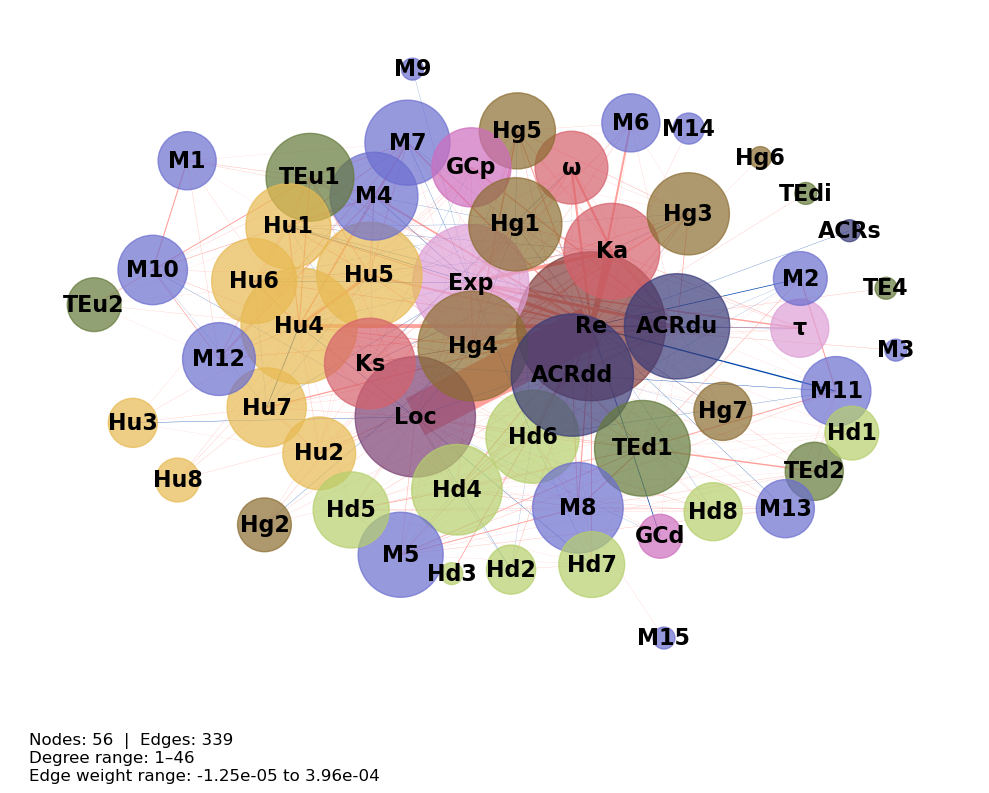


--- Group I (Group I) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 1,711,000 values
  Null abs mean: 0.000027
  Null abs std : 0.000093
  Total feature pairs : 1711
  Significant edges   : 277
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_permutation_node_degrees.csv
  Nodes: 53  |  Edges: 277  |  Degree range: 1–46
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_permutation_network.png


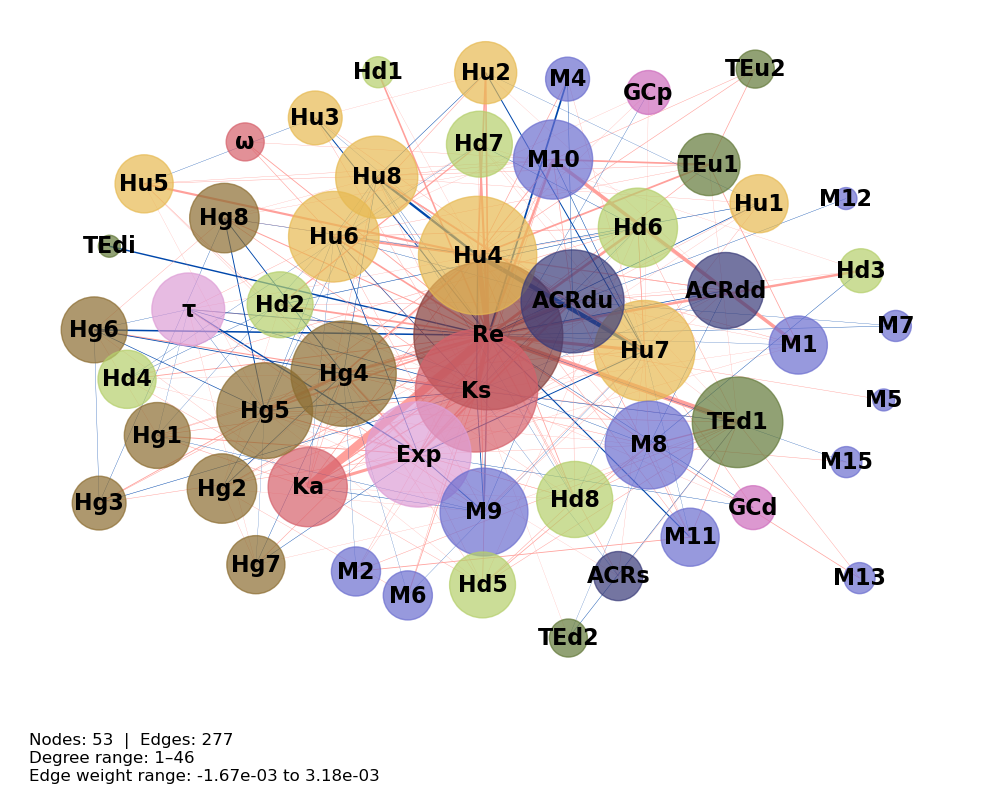


--- Group II (Group II) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 1,711,000 values
  Null abs mean: 0.000035
  Null abs std : 0.000112
  Total feature pairs : 1711
  Significant edges   : 126
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_permutation_node_degrees.csv
  Nodes: 40  |  Edges: 126  |  Degree range: 1–31
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_permutation_network.png


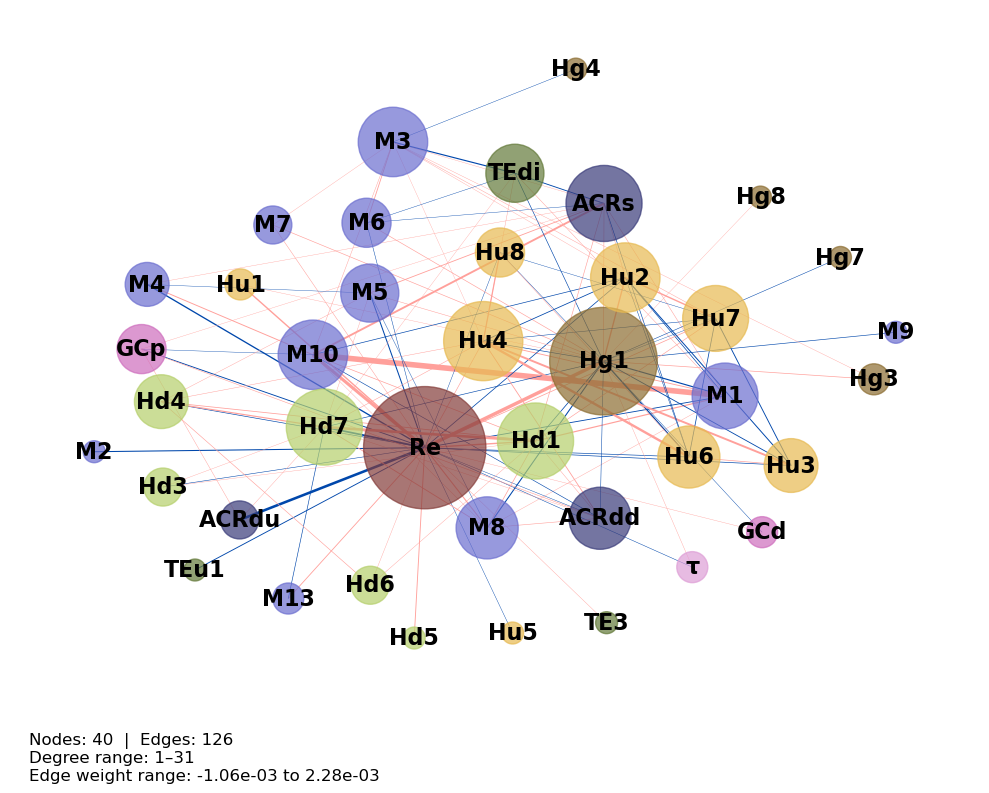


--- Group III (Group III) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 1,711,000 values
  Null abs mean: 0.000007
  Null abs std : 0.000081
  Total feature pairs : 1711
  Significant edges   : 149
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_permutation_node_degrees.csv
  Nodes: 49  |  Edges: 149  |  Degree range: 1–48
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_permutation_network.png


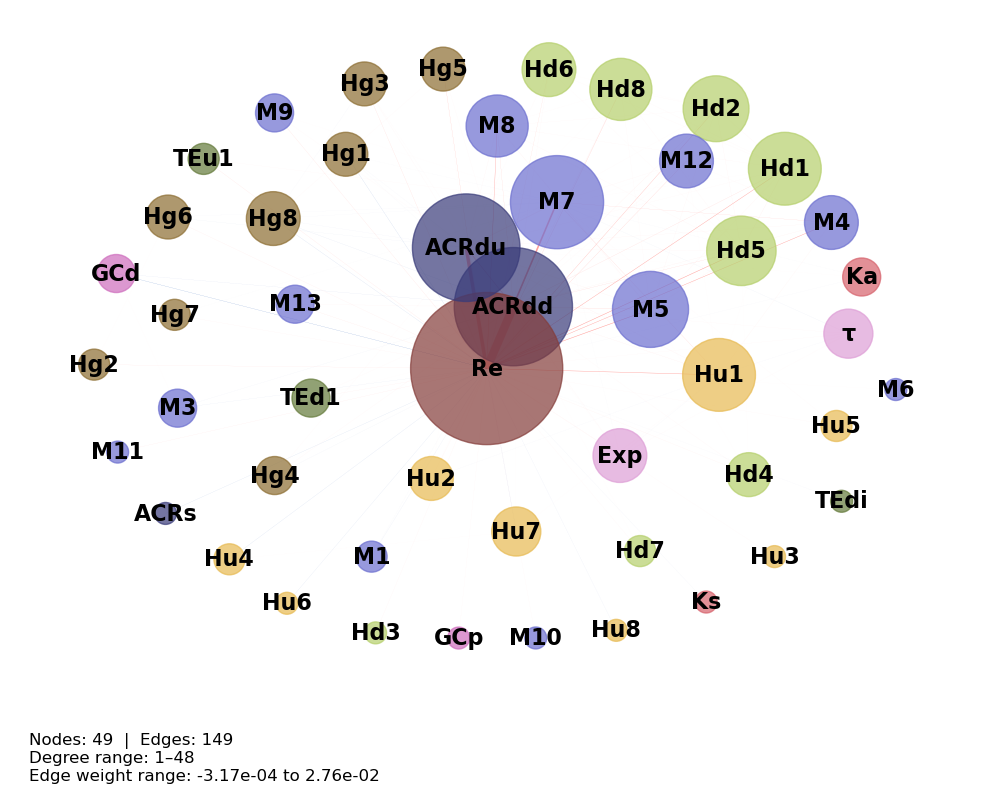


--- Group IV (Group IV) — Permutation ---
  Running 1000 permutations... done.
  Null distribution size: 1,711,000 values
  Null abs mean: 0.000048
  Null abs std : 0.000370
  Total feature pairs : 1711
  Significant edges   : 117
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_permutation_all_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_permutation_significant_edges.csv
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_permutation_node_degrees.csv
  Nodes: 46  |  Edges: 117  |  Degree range: 1–43
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_permutation_network.png


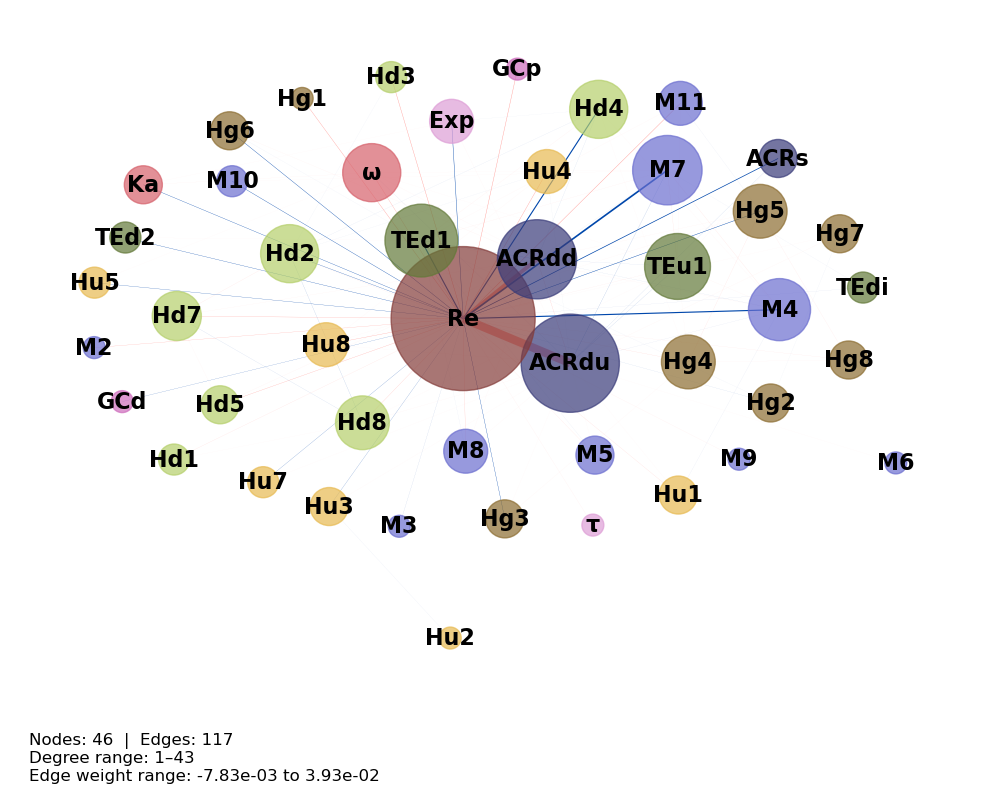

In [42]:
# ============================================================
# INDIVIDUAL NETWORK PLOTS — PERMUTATION METHOD
# ============================================================
# Constructs and plots one SHAP co-variation network per group
# (5 total) using permutation-based significance filtering.
# This is the primary significance method for the manuscript.
#
# METHODS NOTE — permutation approach:
# An empirical null distribution is constructed by permuting
# rows of the SHAP array (n_permutations=1000). Each permutation
# randomly reassigns each sample's full SHAP vector to a
# different sample, preserving the marginal distribution of
# each feature's SHAP values and within-sample feature
# correlations, while destroying systematic co-variation
# between features across samples. The co-variation matrix
# is recomputed for each permuted array and all upper-triangle
# scores are pooled into a single null distribution. The
# two-sided p-value for each observed feature pair score is
# the proportion of pooled null scores whose absolute value
# meets or exceeds the observed absolute score.
#
# Limitation: pooling all feature pairs into one null
# distribution assumes a shared null across pairs. Pairs
# involving features with higher SHAP variance may have
# inflated null scores. A per-pair null would be more
# precise but is computationally heavier and produces
# consistent results when SHAP variance is homogeneous
# across features.
#
# build_network_and_layout() and plot_single_network() are
# defined in Cell 9 and reused here without modification.
# ============================================================

# --- Generate individual permutation networks for all 5 groups ---

# --- Define custom thicknesses here ---
custom_thickness = {
    "All": 30.0,
    "I": 6.0,
    "II": 4.0,
    "III": 6.0,
    "IV": 6.0
}

permutation_network_data = {}  # stores Gx and layout for Cell 12

for group in GROUPS:
    print(f"\n--- Group {group} ({GROUP_LABELS[group]}) "
          f"— Permutation ---")

    shap_array       = shap_data[group]["shap_all"]
    covariate_scores = covariation_data[group]["covariation_scores"]
    feat_labels      = feature_names[group]

    # Significance filtering
    sig_edges, all_edges = compute_permutation_significance(
        shap_array       = shap_array,
        covariate_scores = covariate_scores,
        feature_labels   = feat_labels,
        alpha            = ALPHA_PERMUTATION,
        n_permutations   = 1000,
        random_seed      = 42,
    )

    print(f"  Total feature pairs : {len(covariate_scores)}")
    print(f"  Significant edges   : {len(sig_edges)}")
        
    # Save edge tables
    all_edges_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_permutation_all_edges.csv"
    )
    sig_edges_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_permutation_significant_edges.csv"
    )
    
    all_edges.assign(
        source=all_edges['source'].map(feature_rename_dict).fillna(all_edges['source']),
        target=all_edges['target'].map(feature_rename_dict).fillna(all_edges['target'])
    ).to_csv(all_edges_path, index=False)

    sig_edges.assign(
        source=sig_edges['source'].map(feature_rename_dict).fillna(sig_edges['source']),
        target=sig_edges['target'].map(feature_rename_dict).fillna(sig_edges['target'])
    ).to_csv(sig_edges_path, index=False)

    print(f"  Saved: {all_edges_path}")
    print(f"  Saved: {sig_edges_path}")

    # Build graph and layout
    Gx, layout = build_network_and_layout(sig_edges)

    # Save degree table
    if Gx.number_of_nodes() > 0:
        degree_df = pd.DataFrame(
            Gx.degree, columns=['node', 'degree']
        ).sort_values(
            by='degree', ascending=False
        ).reset_index(drop=True)
        degree_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}_permutation_node_degrees.csv"
        )
        degree_df.assign(
            node=degree_df['node'].map(feature_rename_dict).fillna(degree_df['node'])
        ).to_csv(degree_path, index=False)
        print(f"  Saved: {degree_path}")

    # Store for combined figure in Cell 12
    permutation_network_data[group] = {
        "Gx"       : Gx,
        "layout"   : layout,
        "sig_edges": sig_edges,
    }

    thickness = custom_thickness.get(group, 8.0)
    
    # Plot individual network
    plot_single_network(
        Gx                  = Gx,
        layout              = layout,
        title               = (None
            # f"SHAP Co-variation Network — {GROUP_LABELS[group]}\n"
            # f"(Permutation method, α={ALPHA_PERMUTATION}, n={1000})"
        ),
        save_path           = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}_permutation_network.png"
        ),
        feature_rename_dict = feature_rename_dict,
        feature_to_group    = feature_to_group,
        group_to_color      = group_to_color,
        node_scaling_factor=250,
        max_edge_thickness=thickness,
    )

### Permutation Method: Combined Figure

Global max abs edge weight (Permutation method, n=1000,  α=0.05): 0.039272
Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/combined_permutation_network.png


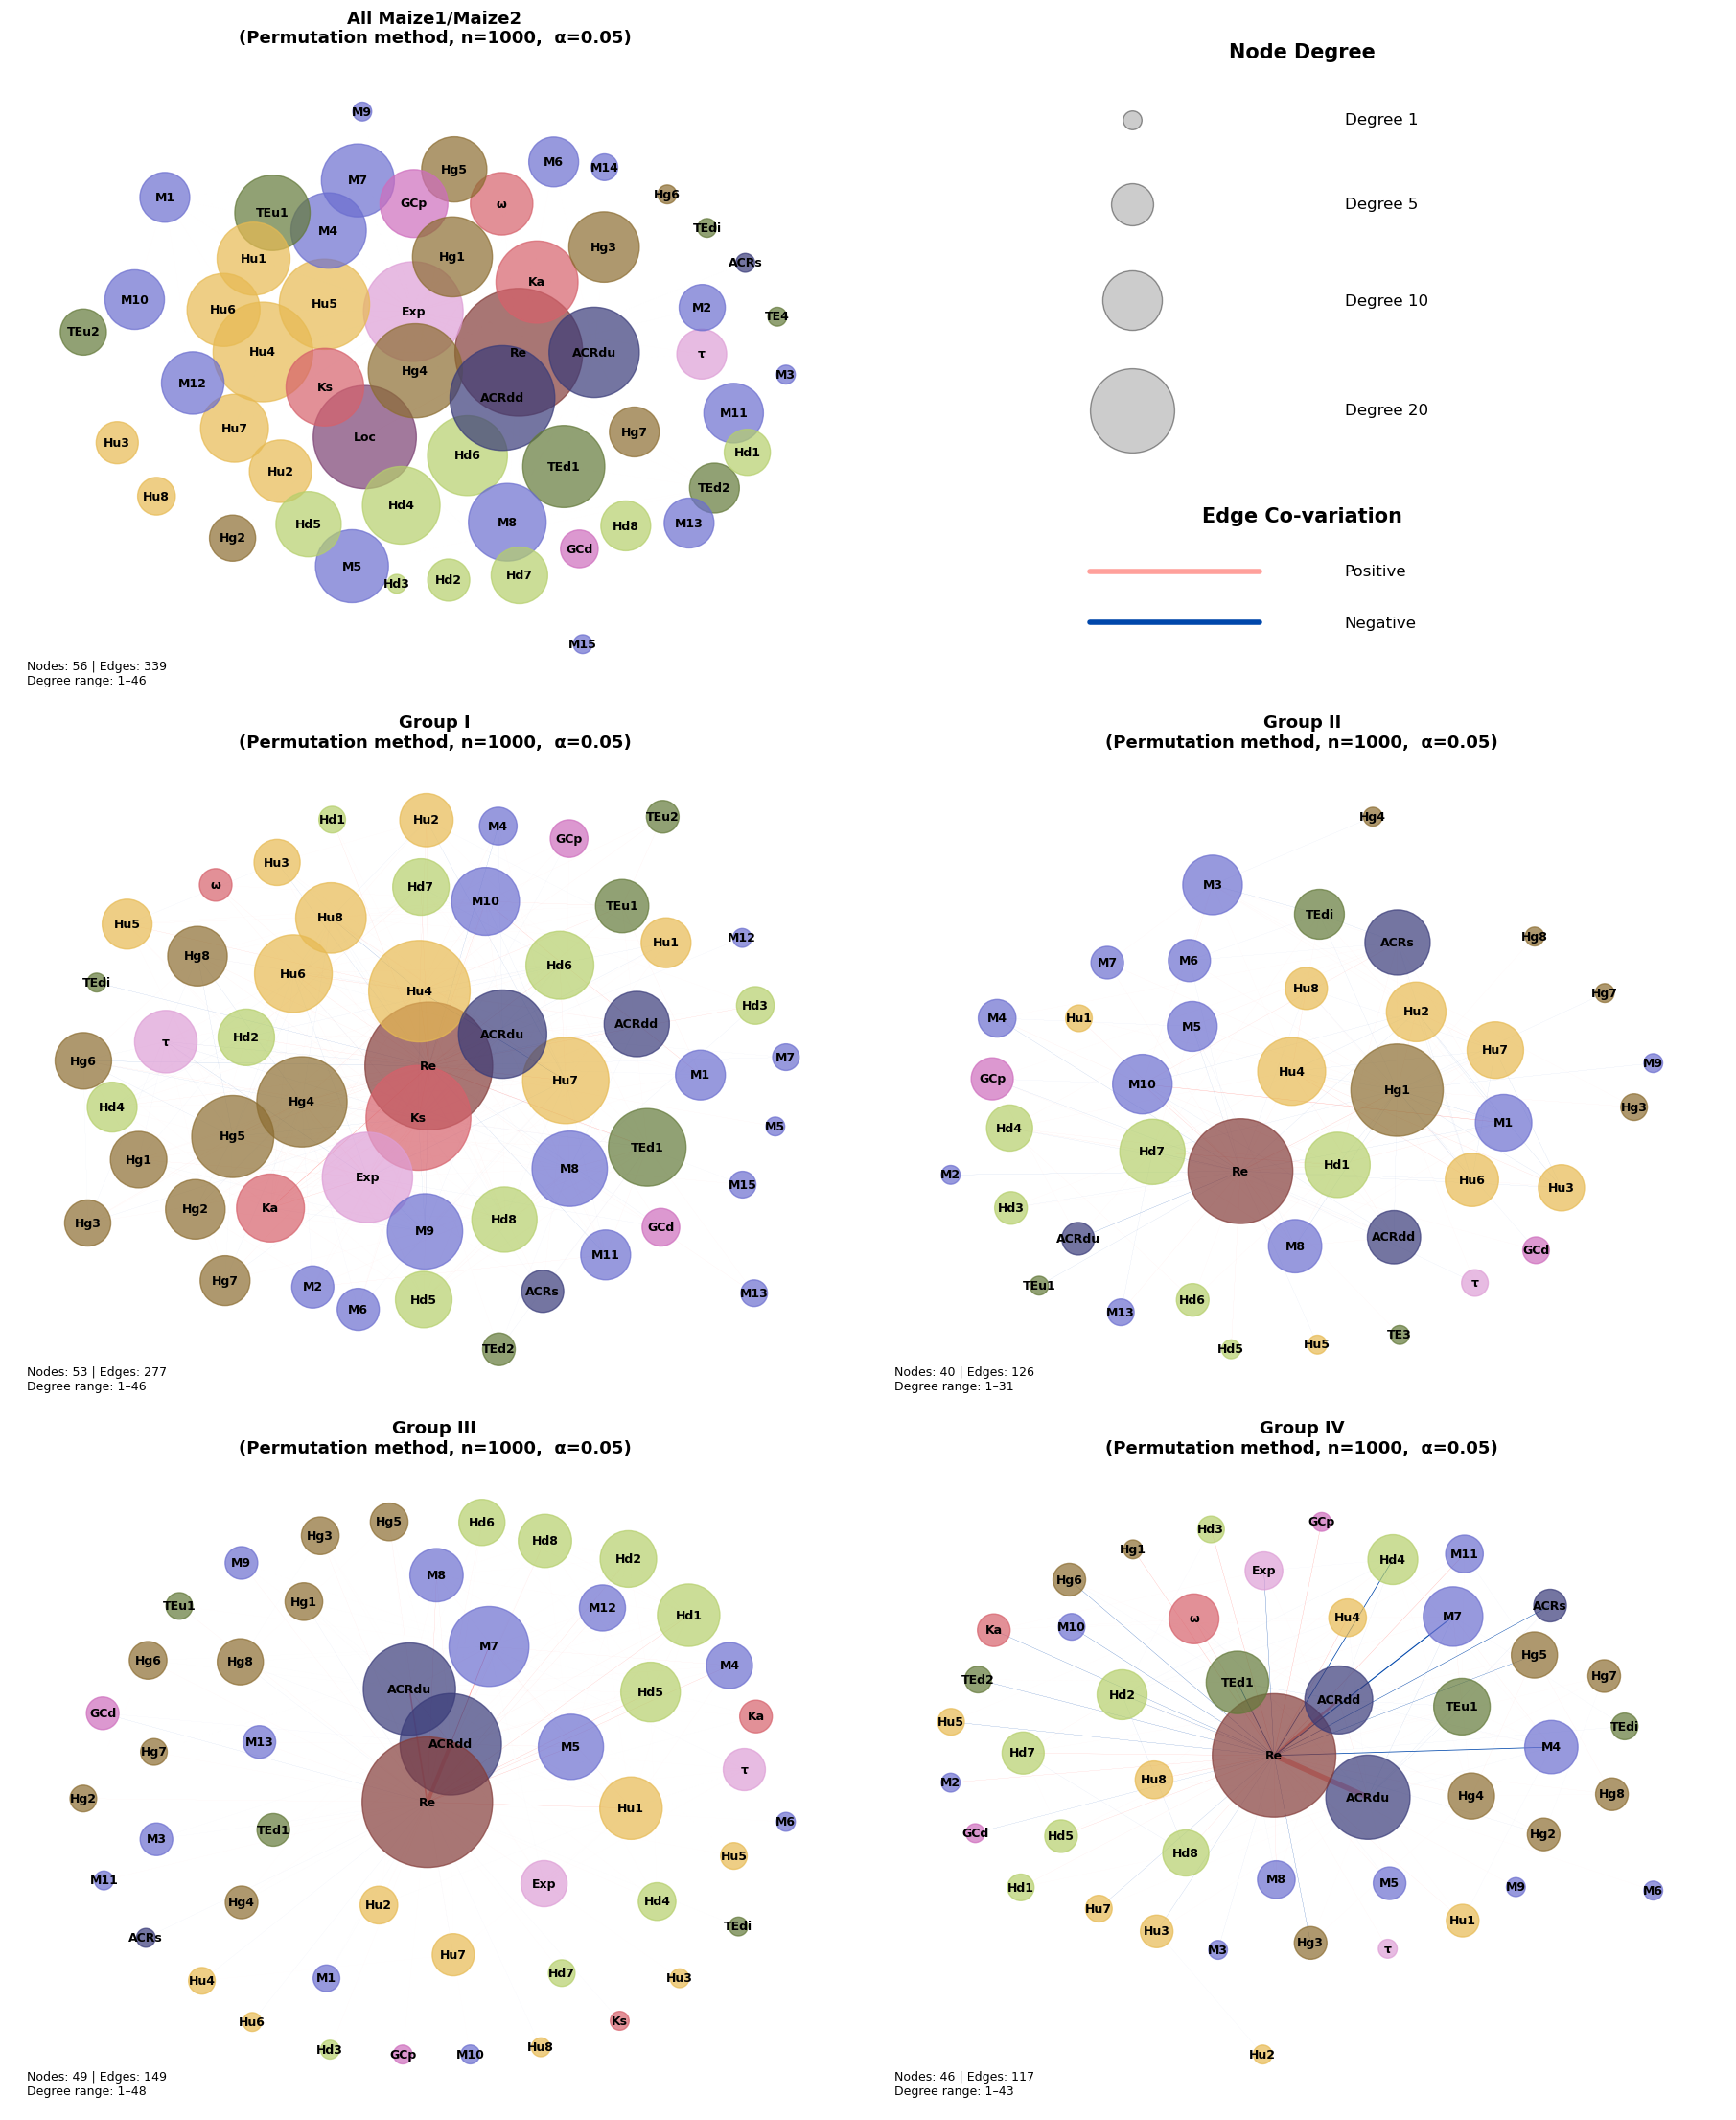

In [43]:
# ============================================================
# COMBINED 2×2 FIGURE — PERMUTATION METHOD
# ============================================================
# Produces the primary manuscript figure for the SHAP
# co-variation network analysis. Uses permutation-based
# significance filtering rather than the z-score
# approach.
# ============================================================

# --- Permutation combined figure (x×2) ---
plot_combined_networks_3x2(
    network_data      = permutation_network_data,
    group_labels      = GROUP_LABELS,
    feature_rename_dict = feature_rename_dict,
    feature_to_group  = feature_to_group,
    group_to_color    = group_to_color,
    save_path         = os.path.join(NETWORK_DIR, "combined_permutation_network.png"),
    method_label      = f"Permutation method, n=1000,  α={ALPHA_PERMUTATION}",
)

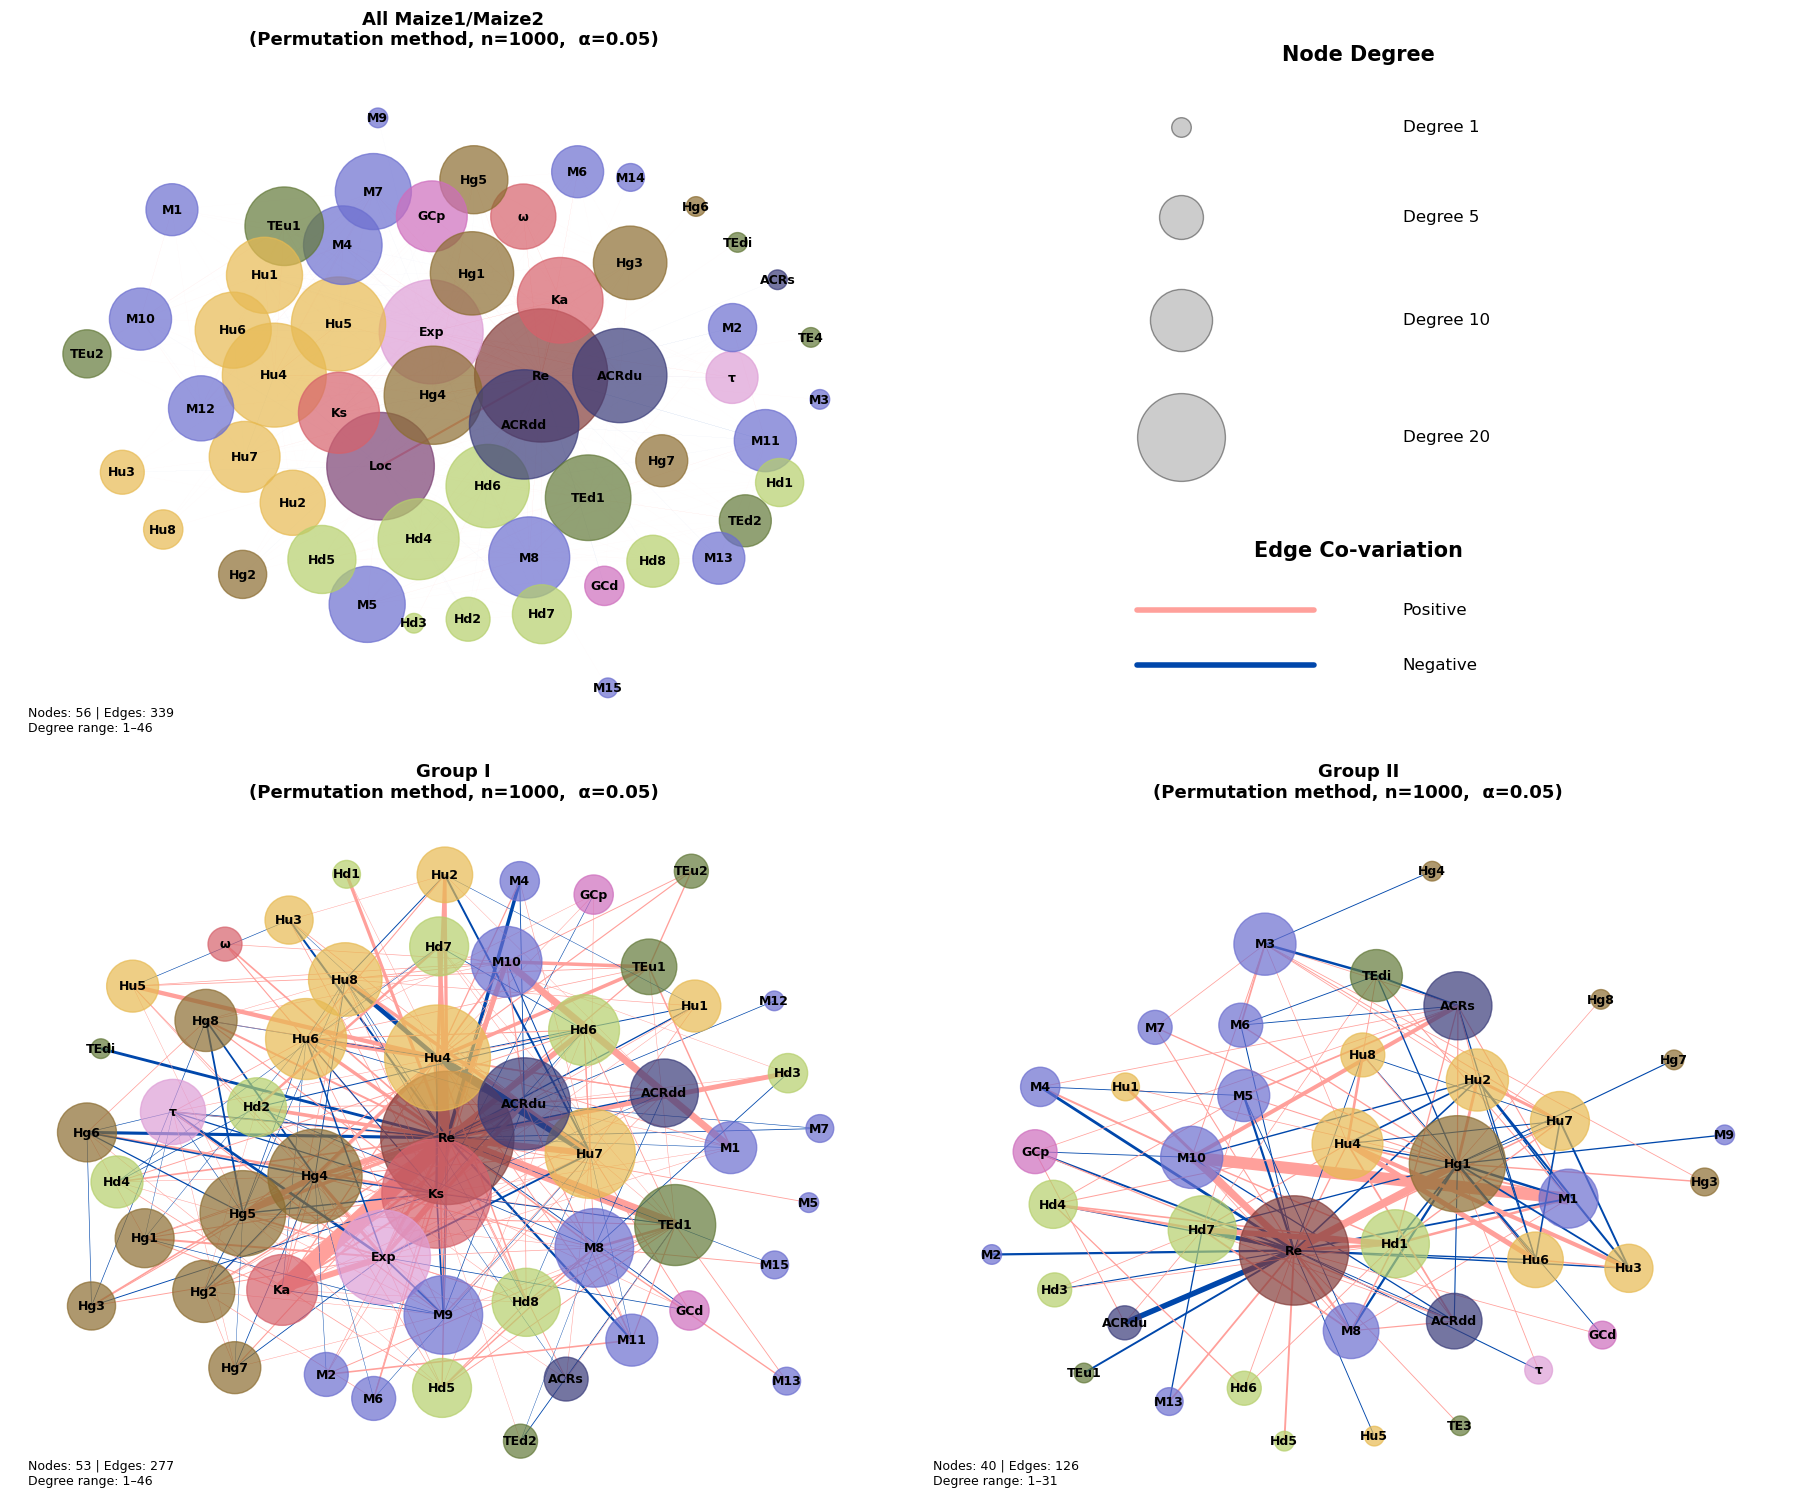

In [44]:
# --- Permutation combined figure (2×2) ---
plot_combined_networks_2x2(
    network_data      = permutation_network_data,
    group_labels      = GROUP_LABELS,
    feature_rename_dict = feature_rename_dict,
    feature_to_group  = feature_to_group,
    group_to_color    = group_to_color,
    save_path         = os.path.join(NETWORK_DIR, "combined_permutation_network_clipped.png"),
    method_label      = f"Permutation method, n=1000,  α={ALPHA_PERMUTATION}",
    max_edge_thickness  = 12.0,
    node_scaling_factor = 200
)

# SHAP Interaction Data

## Interaction Data Exploration

### Step 1: Violin Plots

Group All: 1770 pairs | mean=-0.000009 | std=0.000350 | min=-0.014731 | max=0.000149
Group I: 1711 pairs | mean=-0.000006 | std=0.000149 | min=-0.002530 | max=0.001193
Group II: 1711 pairs | mean=0.000000 | std=0.000106 | min=-0.001563 | max=0.001135
Group III: 1711 pairs | mean=-0.000003 | std=0.000099 | min=-0.003232 | max=0.000514
Group IV: 1711 pairs | mean=-0.000000 | std=0.000062 | min=-0.000912 | max=0.000963
Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_distribution_violin.png


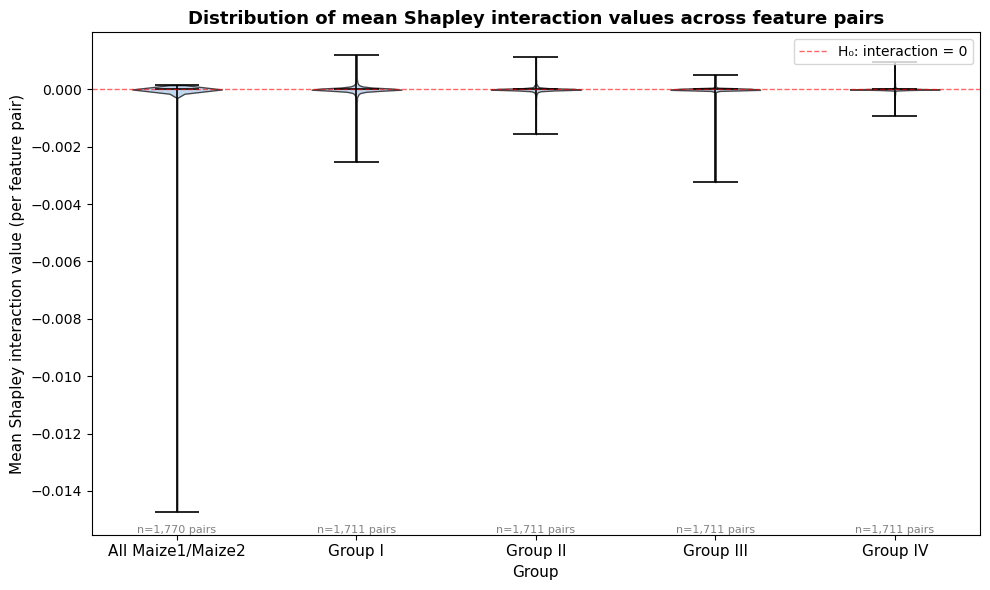

In [45]:
# ============================================================
# STEP 1: VIOLIN PLOTS — DISTRIBUTION OF MEAN INTERACTION
# VALUES PER FEATURE PAIR ACROSS GROUPS
# ============================================================
# For each group, computes the mean Shapley interaction value
# across samples for every upper-triangle feature pair.
# Plots distributions as violins on a shared axis to compare
# the spread and shape of interaction values across groups.
#
# Signed values are shown (not absolute) to reveal asymmetry.
# A symmetric distribution centered on zero would support the
# t-test assumption; asymmetry motivates non-parametric
# alternatives. The spread across groups informs whether a
# single effect size cutoff is appropriate for all groups.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# --- Compute mean interaction value per pair for each group ---
# Result per group: 1D array of length n_pairs (upper triangle only)
mean_interaction_per_pair = {}

for group in GROUPS:
    interact = shap_data[group]["shap_interaction_all"]  
    # shape: (n_samples, n_features, n_features)
    n_features = interact.shape[1]

    # Mean across samples for each pair, then extract upper triangle
    mean_matrix = interact.mean(axis=0)  
    # shape: (n_features, n_features)

    upper_mask = np.triu(np.ones((n_features, n_features), dtype=bool), k=1)
    pair_means = mean_matrix[upper_mask]  
    # shape: (n_pairs,) — signed mean interaction per pair

    mean_interaction_per_pair[group] = pair_means

    print(f"Group {group}: {len(pair_means)} pairs | "
          f"mean={pair_means.mean():.6f} | "
          f"std={pair_means.std():.6f} | "
          f"min={pair_means.min():.6f} | "
          f"max={pair_means.max():.6f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

violin_data  = [mean_interaction_per_pair[g] for g in GROUPS]
violin_parts = ax.violinplot(
    violin_data,
    positions   = range(len(GROUPS)),
    showmedians = True,
    showextrema = True,
)

# Style violins
for pc in violin_parts["bodies"]:
    pc.set_facecolor("#a8c8e8")
    pc.set_edgecolor("black")
    pc.set_alpha(0.7)
for part in ["cmedians", "cmins", "cmaxes", "cbars"]:
    violin_parts[part].set_color("black")
    violin_parts[part].set_linewidth(1.2)

# Zero reference line — H0: interaction = 0
ax.axhline(0, color="red", linestyle="--", linewidth=1.0, alpha=0.6, label="H₀: interaction = 0")

ax.set_xticks(range(len(GROUPS)))
ax.set_xticklabels([GROUP_LABELS[g] for g in GROUPS], fontsize=11)
ax.set_ylabel("Mean Shapley interaction value (per feature pair)", fontsize=11)
ax.set_xlabel("Group", fontsize=11)
ax.set_title(
    "Distribution of mean Shapley interaction values across feature pairs",
    fontsize=13, fontweight="bold"
)
ax.legend(fontsize=10)

# Annotate n pairs per group
for i, group in enumerate(GROUPS):
    n = len(mean_interaction_per_pair[group])
    ax.annotate(
        f"n={n:,} pairs",
        xy=(i, ax.get_ylim()[0]),
        xycoords="data",
        fontsize=8,
        ha="center", va="bottom",
        color="gray"
    )

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, "interaction_distribution_violin.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 2: Retention Curves

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_retention_curves.png


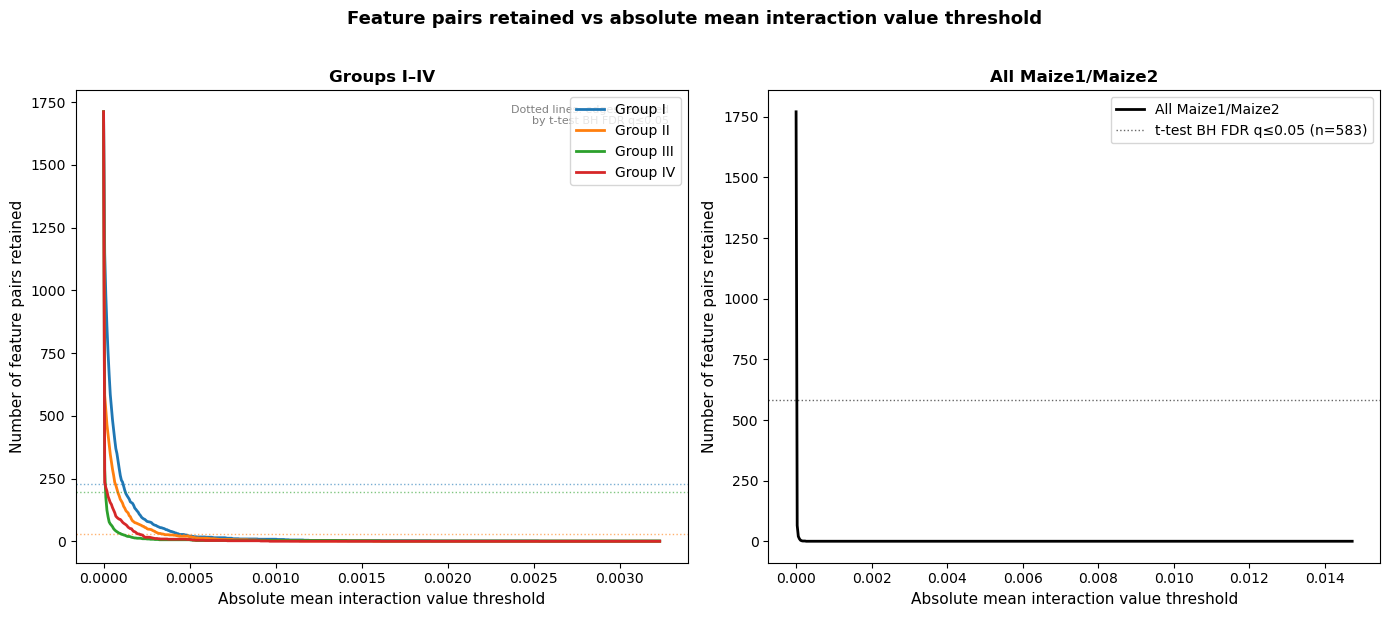

In [46]:
# ============================================================
# STEP 2: RETENTION CURVES — EDGES RETAINED VS ABSOLUTE
# WEIGHT THRESHOLD
# ============================================================
# For each group, sweeps a range of absolute mean interaction
# value cutoffs and counts how many feature pairs survive.
# Helps identify a natural elbow — a threshold where the
# curve flattens, suggesting diminishing returns from lowering
# the cutoff further.
#
# "All" group is plotted separately (right panel) because its
# value range (~0.015) is ~5x larger than Groups I–IV (~0.003),
# and including it on a shared axis compresses the group-level
# structure into illegibility (as seen in the violin plot).
#
# Horizontal dashed lines show the number of significant edges
# retained by the current t-test + BH FDR approach (q<=0.05)
# for reference.
#
# Uses mean_interaction_per_pair computed in Step 1.
# ============================================================

# --- Significant edge counts from the exploratory t-test + BH FDR approach ---
# This was the initial method tried (see methods note in the Interaction
# Networks section) and was superseded by the effect-size/median+MAD
# threshold actually used in the final networks. These counts are shown
# here only as retention-curve context from that earlier exploration —
# they are not expected to match the final interaction network edge counts.
sig_edge_counts = {
    "All"  : 583,
    "I"    : 227,
    "II"   : 29,
    "III"  : 197,
    "IV"   : 0,
}

# --- Compute retention curves ---
# For each group: array of absolute mean interaction values
abs_means = {
    group: np.abs(mean_interaction_per_pair[group])
    for group in GROUPS
}

# Threshold ranges — separate for All vs I-IV to respect scale difference
n_points       = 500
thresholds_groups = np.linspace(0, max(abs_means[g].max() for g in ["I","II","III","IV"]), n_points)
thresholds_all    = np.linspace(0, abs_means["All"].max(), n_points)

def retention_counts(abs_vals, thresholds):
    """Count pairs surviving each threshold."""
    return np.array([(abs_vals >= t).sum() for t in thresholds])

retention = {
    group: retention_counts(abs_means[group], thresholds_groups)
    for group in ["I", "II", "III", "IV"]
}
retention["All"] = retention_counts(abs_means["All"], thresholds_all)

# --- Colors for groups I-IV ---
group_colors = {
    "I"  : "#1f77b4",
    "II" : "#ff7f0e",
    "III": "#2ca02c",
    "IV" : "#d62728",
}

# --- Plot ---
fig, (ax_groups, ax_all) = plt.subplots(
    1, 2,
    figsize=(14, 6),
    sharey=False,
)

# Left panel: Groups I-IV
for group in ["I", "II", "III", "IV"]:
    ax_groups.plot(
        thresholds_groups,
        retention[group],
        label     = GROUP_LABELS[group],
        color     = group_colors[group],
        linewidth = 2.0,
    )
    # Horizontal reference: current significant edge count
    n_sig = sig_edge_counts[group]
    if n_sig > 0:
        ax_groups.axhline(
            n_sig,
            color     = group_colors[group],
            linestyle = ":",
            linewidth = 1.0,
            alpha     = 0.6,
        )

ax_groups.set_xlabel("Absolute mean interaction value threshold", fontsize=11)
ax_groups.set_ylabel("Number of feature pairs retained", fontsize=11)
ax_groups.set_title("Groups I–IV", fontsize=12, fontweight="bold")
ax_groups.legend(fontsize=10)
ax_groups.annotate(
    "Dotted lines: edges retained\nby t-test BH FDR q≤0.05",
    xy=(0.97, 0.97), xycoords="axes fraction",
    fontsize=8, ha="right", va="top", color="gray",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
)

# Right panel: All
ax_all.plot(
    thresholds_all,
    retention["All"],
    label     = GROUP_LABELS["All"],
    color     = "black",
    linewidth = 2.0,
)
ax_all.axhline(
    sig_edge_counts["All"],
    color     = "black",
    linestyle = ":",
    linewidth = 1.0,
    alpha     = 0.6,
    label     = f"t-test BH FDR q≤0.05 (n={sig_edge_counts['All']})",
)
ax_all.set_xlabel("Absolute mean interaction value threshold", fontsize=11)
ax_all.set_ylabel("Number of feature pairs retained", fontsize=11)
ax_all.set_title("All Maize1/Maize2", fontsize=12, fontweight="bold")
ax_all.legend(fontsize=10)

fig.suptitle(
    "Feature pairs retained vs absolute mean interaction value threshold",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, "interaction_retention_curves.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 3: Interaction Magnitude vs Main Effect Magnitude

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_vs_maineffect.png


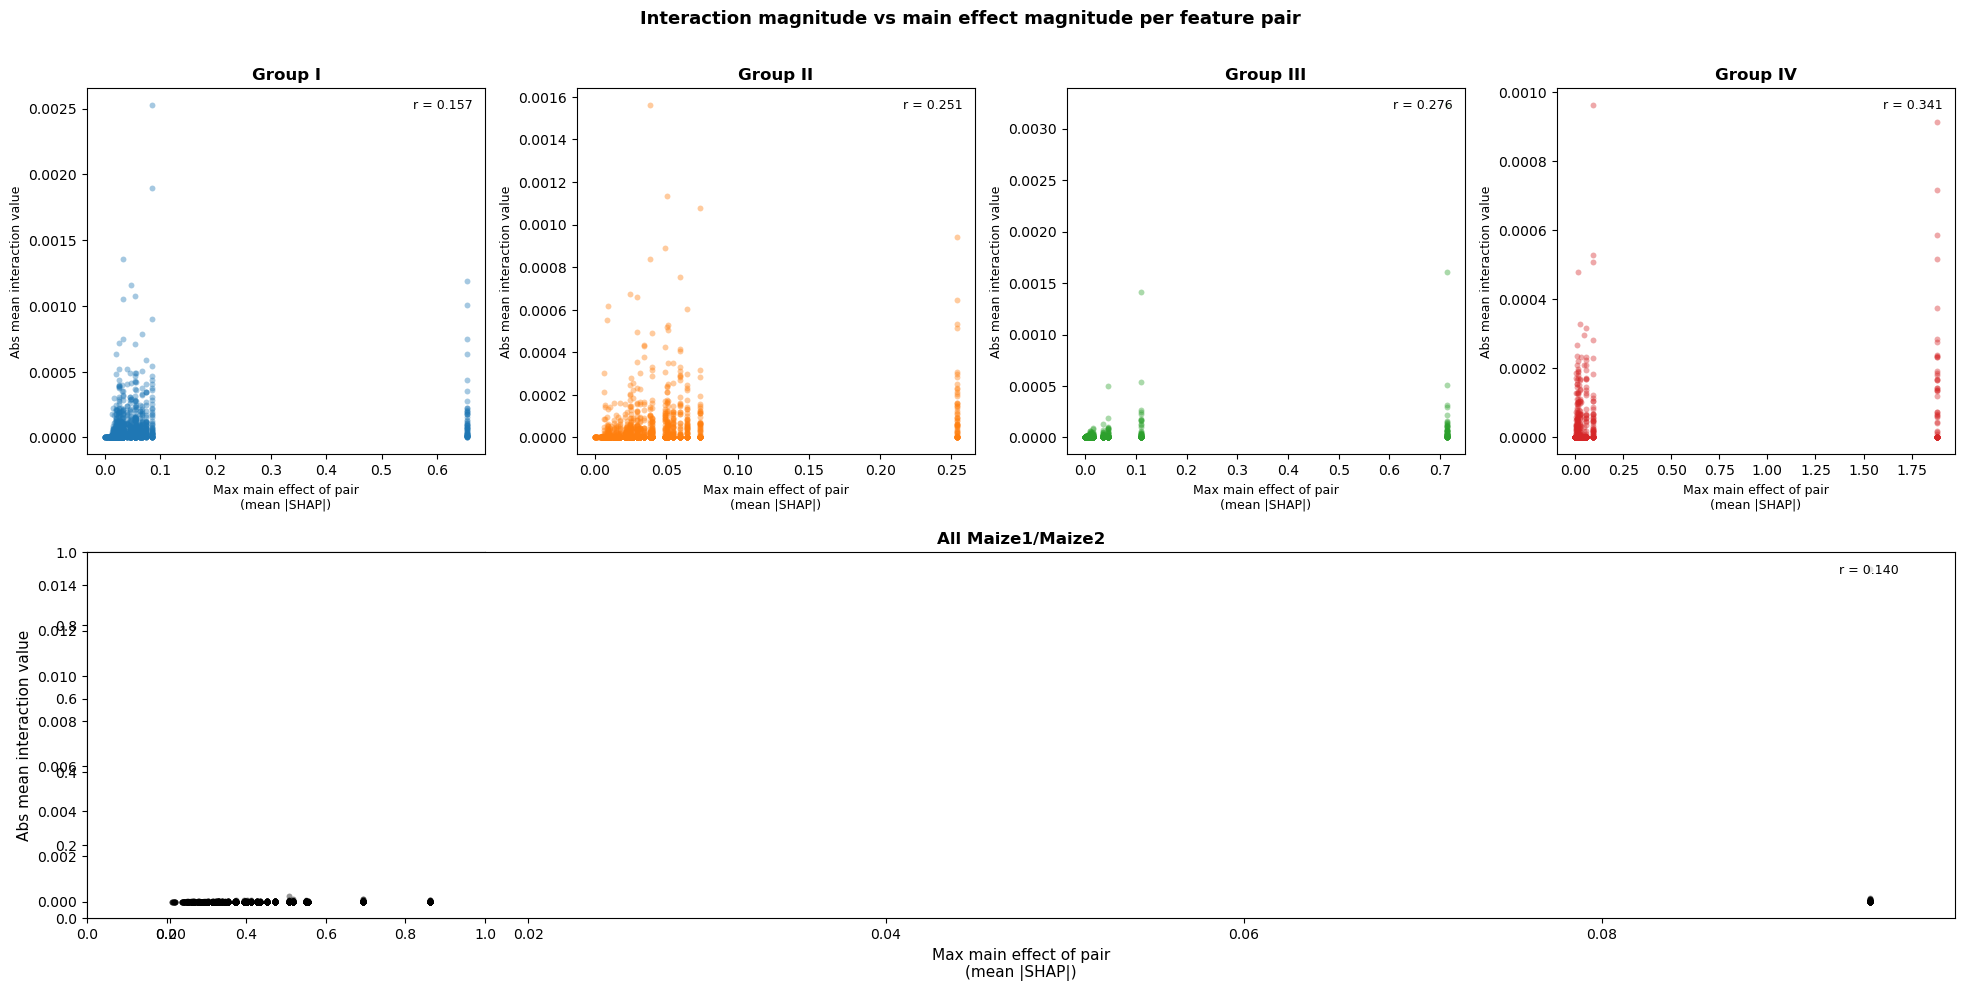

In [47]:
# ============================================================
# STEP 3: INTERACTION MAGNITUDE VS MAIN EFFECT MAGNITUDE
# ============================================================
# For each group, plots the absolute mean interaction value
# per feature pair against the main effect of that pair,
# defined as max(mean_abs_shap[j], mean_abs_shap[k]).
#
# Main effect: mean(abs(shap_all[:, j])) for feature j —
# how much feature j contributes on average to predictions
# regardless of direction. The maximum of the two features
# in a pair is used because the stronger individual
# contributor dominates the pair's main effect context.
#
# Motivation: if large interactions only occur between
# features that also have large main effects, the interaction
# signal may be secondary to main effect structure. If large
# interactions occur between low-main-effect features, that
# is more surprising and biologically interesting.
#
# "All" is plotted on its own row given its different scale.
# Groups I-IV share a row. Axes are NOT shared because
# the groups have different value ranges — the goal is to
# see structure within each group, not to compare absolute
# magnitudes across groups (the retention curves already
# showed that).
#
# Uses mean_interaction_per_pair from Step 1.
# ============================================================

fig, axes = plt.subplots(
    2, 4,
    figsize = (20, 10),
    gridspec_kw = {"height_ratios": [1, 1]},
)

# Top row: Groups I-IV in columns 0-3
# Bottom row: All in column 0-1 (merged), empty in 2-3
for ax in axes[1, 1:]:
    ax.set_visible(False)
ax_all = fig.add_subplot(2, 1, 2)  # full-width bottom panel for All

group_colors_scatter = {
    "I"  : "#1f77b4",
    "II" : "#ff7f0e",
    "III": "#2ca02c",
    "IV" : "#d62728",
}

for col, group in enumerate(["I", "II", "III", "IV"]):
    ax = axes[0, col]

    # --- Main effects: mean abs SHAP per feature ---
    shap_all_group  = shap_data[group]["shap_all"]
    mean_abs_shap   = np.abs(shap_all_group).mean(axis=0)
    # shape: (n_features,)

    # Recompute more cleanly from the matrix
    interact      = shap_data[group]["shap_interaction_all"]
    mean_matrix   = interact.mean(axis=0)
    n_features    = mean_matrix.shape[0]
    pair_main     = []
    pair_inter    = []

    for j in range(n_features):
        for k in range(j + 1, n_features):
            pair_main.append(max(mean_abs_shap[j], mean_abs_shap[k]))
            pair_inter.append(abs(mean_matrix[j, k]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    ax.scatter(
        pair_main,
        pair_inter,
        alpha     = 0.4,
        s         = 18,
        color     = group_colors_scatter[group],
        linewidths= 0,
    )
    ax.set_title(GROUP_LABELS[group], fontsize=12, fontweight="bold")
    ax.set_xlabel("Max main effect of pair\n(mean |SHAP|)", fontsize=9)
    ax.set_ylabel("Abs mean interaction value", fontsize=9)

    # Pearson correlation annotation
    r = np.corrcoef(pair_main, pair_inter)[0, 1]
    ax.annotate(
        f"r = {r:.3f}",
        xy=(0.97, 0.97), xycoords="axes fraction",
        fontsize=9, ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
    )

# --- All group: bottom panel ---
shap_all_group  = shap_data["All"]["shap_all"]
mean_abs_shap   = np.abs(shap_all_group).mean(axis=0)
interact        = shap_data["All"]["shap_interaction_all"]
mean_matrix     = interact.mean(axis=0)
n_features      = mean_matrix.shape[0]

pair_main_all  = []
pair_inter_all = []
for j in range(n_features):
    for k in range(j + 1, n_features):
        pair_main_all.append(max(mean_abs_shap[j], mean_abs_shap[k]))
        pair_inter_all.append(abs(mean_matrix[j, k]))

pair_main_all  = np.array(pair_main_all)
pair_inter_all = np.array(pair_inter_all)

ax_all.scatter(
    pair_main_all,
    pair_inter_all,
    alpha     = 0.4,
    s         = 18,
    color     = "black",
    linewidths= 0,
)
r_all = np.corrcoef(pair_main_all, pair_inter_all)[0, 1]
ax_all.annotate(
    f"r = {r_all:.3f}",
    xy=(0.97, 0.97), xycoords="axes fraction",
    fontsize=9, ha="right", va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7, ec="none")
)
ax_all.set_title(GROUP_LABELS["All"], fontsize=12, fontweight="bold")
ax_all.set_xlabel("Max main effect of pair\n(mean |SHAP|)", fontsize=11)
ax_all.set_ylabel("Abs mean interaction value", fontsize=11)

fig.suptitle(
    "Interaction magnitude vs main effect magnitude per feature pair",
    fontsize=13, fontweight="bold", y=1.01
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, "interaction_vs_maineffect.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 3.1: Identify Rightmost Outliers per Group

In [48]:
# ============================================================
# IDENTIFY RIGHTMOST OUTLIER FEATURES PER GROUP
# ============================================================
# For each group, finds which feature has the highest mean
# absolute SHAP value (main effect), and reports the top N
# pairs by max main effect to confirm which feature drives
# the rightmost cluster in the scatter plots.
# ============================================================

print("Top 5 features by mean |SHAP| (main effect) per group:\n")

top_feature_per_group = {}

for group in GROUPS:
    shap_array   = shap_data[group]["shap_all"]
    mean_abs     = np.abs(shap_array).mean(axis=0)
    feat_names   = feature_names[group]

    # Rank features by mean abs SHAP
    ranked_idx   = np.argsort(mean_abs)[::-1]

    print(f"--- Group {group} ({GROUP_LABELS[group]}) ---")
    for rank, idx in enumerate(ranked_idx[:5]):
        print(f"  {rank+1}. {feat_names[idx]:<25} "
              f"mean |SHAP| = {mean_abs[idx]:.6f}")

    top_feature_per_group[group] = feat_names[ranked_idx[0]]
    print()

print("\nTop 5 pairs by max main effect per group:\n")

for group in GROUPS:
    shap_array   = shap_data[group]["shap_all"]
    mean_abs     = np.abs(shap_array).mean(axis=0)
    feat_names   = feature_names[group]
    interact     = shap_data[group]["shap_interaction_all"]
    mean_matrix  = interact.mean(axis=0)
    n_features   = len(feat_names)

    pair_records = []
    for j in range(n_features):
        for k in range(j + 1, n_features):
            pair_records.append({
                "feature_j"   : feat_names[j],
                "feature_k"   : feat_names[k],
                "max_main"    : max(mean_abs[j], mean_abs[k]),
                "abs_interact": abs(mean_matrix[j, k]),
            })

    pair_df = pd.DataFrame(pair_records).sort_values(
        "max_main", ascending=False
    ).reset_index(drop=True)

    print(f"--- Group {group} ({GROUP_LABELS[group]}) ---")
    print(pair_df[["feature_j", "feature_k",
                   "max_main", "abs_interact"]].head(5).to_string(index=False))
    print()
    

Top 5 features by mean |SHAP| (main effect) per group:

--- Group All (All Maize1/Maize2) ---
  1. recomb                    mean |SHAP| = 0.095002
  2. location                  mean |SHAP| = 0.014500
  3. acr_Lup                   mean |SHAP| = 0.010771
  4. Ka                        mean |SHAP| = 0.007691
  5. avg_expression            mean |SHAP| = 0.007557

--- Group I (Group I) ---
  1. recomb                    mean |SHAP| = 0.653930
  2. H3K9ac_up                 mean |SHAP| = 0.085916
  3. acr_Lup                   mean |SHAP| = 0.074355
  4. H3K36me3_up               mean |SHAP| = 0.067827
  5. CHH_up_max                mean |SHAP| = 0.063770

--- Group II (Group II) ---
  1. recomb                    mean |SHAP| = 0.253875
  2. acr_S                     mean |SHAP| = 0.073506
  3. CHH_up_max                mean |SHAP| = 0.064184
  4. H2AZ_genebody             mean |SHAP| = 0.059559
  5. CHH_body_avg              mean |SHAP| = 0.054708

--- Group III (Group III) ---
  1. reco

### Step 4: K-Sweep Median + k × MAD Threshold with Zeros

Group-specific threshold components:

Group All:
  Median abs interaction : 0.00000135
  MAD                    : 0.00000124
  Ratio median/MAD       : 1.09 (how many MADs the median sits above zero)

Group I:
  Median abs interaction : 0.00001957
  MAD                    : 0.00001957
  Ratio median/MAD       : 1.00 (how many MADs the median sits above zero)

Group II:
  Median abs interaction : 0.00000000
  MAD                    : 0.00000000
  Ratio median/MAD       : nan (how many MADs the median sits above zero)

Group III:
  Median abs interaction : 0.00000093
  MAD                    : 0.00000093
  Ratio median/MAD       : 1.00 (how many MADs the median sits above zero)

Group IV:
  Median abs interaction : 0.00000000
  MAD                    : 0.00000000
  Ratio median/MAD       : nan (how many MADs the median sits above zero)

Edges retained per group across k values:

      All    I   II  III   IV
k                            
1.0   634  582  640  642  254
1.5   562  511  640 

/scratch/local/33280310/ipykernel_2060342/3607513430.py:80: RuntimeWarning: invalid value encountered in scalar divide
  f"{med/mad:.2f} (how many MADs the median sits above zero)")


Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_ksweep_retention_curves.png


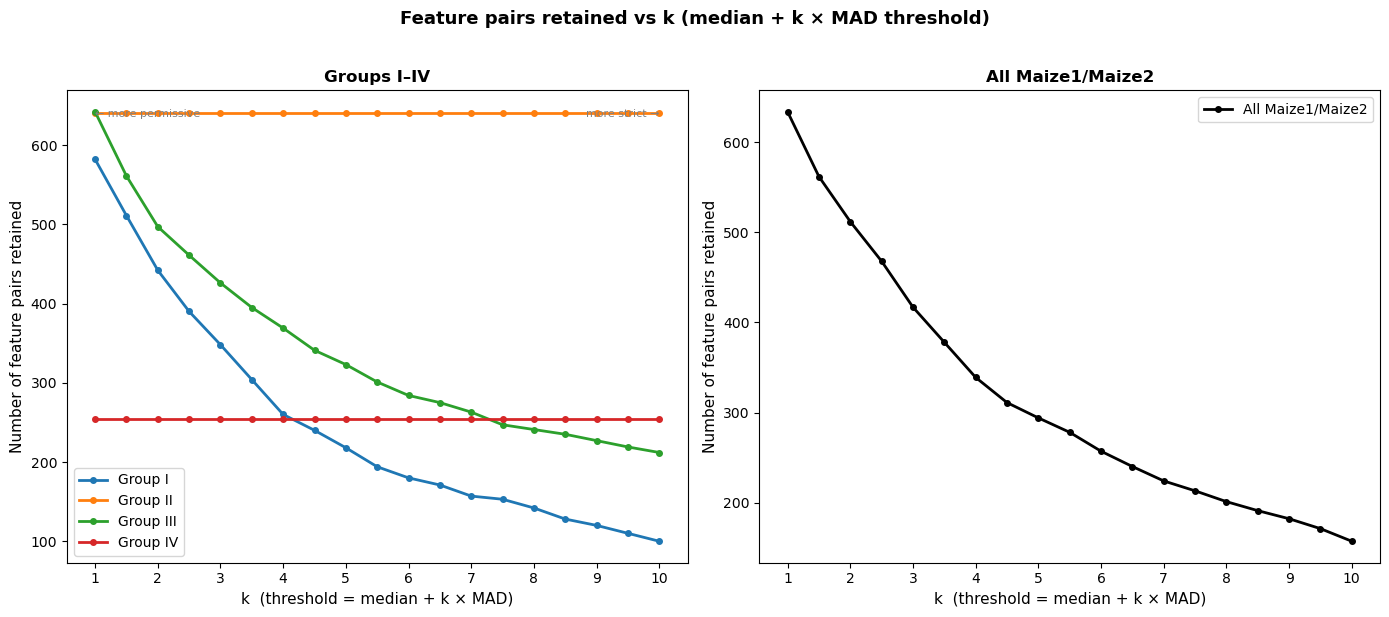

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_ksweep_scatter_overlay.png


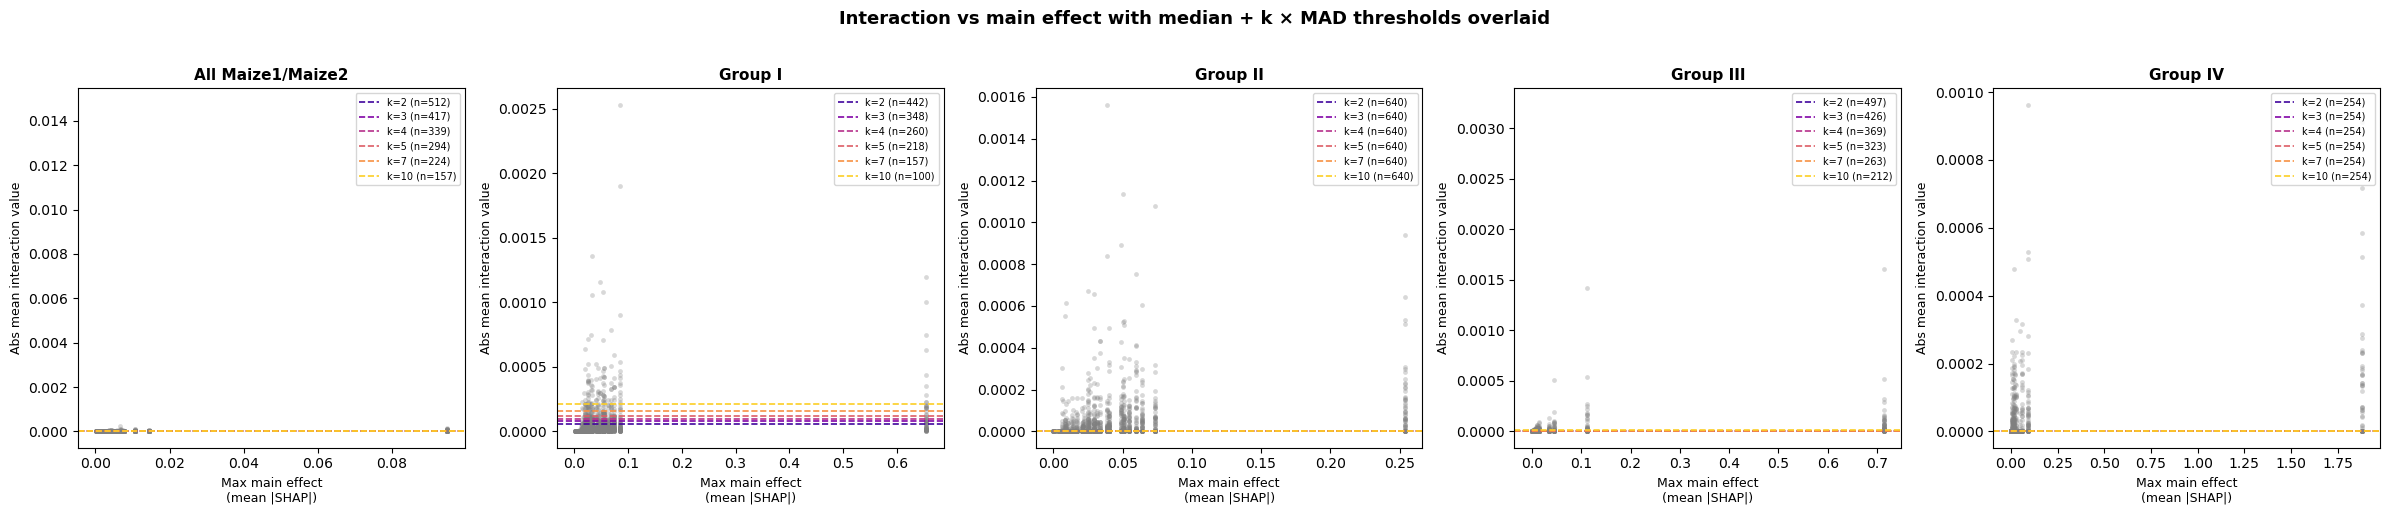

In [49]:
# ============================================================
# K-SWEEP: MEDIAN + k × MAD THRESHOLD
# ============================================================
# For each group, computes a robust effect-size threshold
# using the median and MAD (median absolute deviation) of
# all absolute mean interaction values across feature pairs.
#
# The threshold for a given k is:
#   threshold = median(abs_mean_interactions)
#               + k * MAD(abs_mean_interactions)
#
# Any pair whose absolute mean interaction value exceeds this
# threshold is retained as a meaningful interaction for that
# group. Pairs below it are considered indistinguishable from
# the group's own noise floor.
#
# WHY MEDIAN AND MAD INSTEAD OF MEAN AND STD:
# From the violin plots, we know the distribution of
# interaction values is heavily skewed with a long negative
# tail and most pairs near zero. The mean and standard
# deviation are sensitive to these extreme values and would
# give a misleading picture of the "typical" pair. The median
# and MAD are resistant to outliers — they describe the
# center and spread of the bulk of the distribution, not the
# extremes. This means Re-containing pairs with large
# interaction values do not artificially inflate the
# threshold for everyone else.
#
# WHY THIS IS GROUP-SPECIFIC:
# The absolute scale of interaction values differs across
# groups (as shown in the violin plots and retention curves).
# Using each group's own median and MAD means "meaningful"
# is defined relative to that group's noise floor, not a
# global cutoff. If Group IV's interactions are genuinely
# all near zero relative to its own spread, no edges will
# survive — and that is a real biological result.
#
# OUTPUTS:
# 1. A table of edges retained per group across k values
# 2. A line plot of retention vs k per group (Groups I-IV
#    and All on separate panels as before)
# 3. The step 3 scatter plot (interaction vs main effect)
#    with the threshold at each k overlaid as a horizontal
#    line, so you can see which pairs survive visually
# ============================================================

from scipy.stats import median_abs_deviation

# --- Compute group-specific median and MAD ---
# These are fixed per group — only k varies in the sweep
print("Group-specific threshold components:\n")

group_medians = {}
group_mads    = {}

for group in GROUPS:
    # abs_means was computed in Step 1:
    # abs mean interaction value for each upper-triangle pair
    abs_vals = np.abs(mean_interaction_per_pair[group])

    # median: the middle value when all pairs are ranked
    # by absolute interaction — our estimate of the
    # "typical" (near-zero) pair
    med = np.median(abs_vals)

    # MAD: median of how far each pair's value is from
    # the median. Resistant to the long tails we saw.
    # scale=1 returns the raw MAD without any normal
    # distribution scaling factor — we want the raw
    # deviation in interaction value units
    mad = median_abs_deviation(abs_vals, scale=1)

    group_medians[group] = med
    group_mads[group]    = mad

    print(f"Group {group}:")
    print(f"  Median abs interaction : {med:.8f}")
    print(f"  MAD                    : {mad:.8f}")
    print(f"  Ratio median/MAD       : "
          f"{med/mad:.2f} (how many MADs the median sits above zero)")
    print()

# --- Define k sweep range ---
# k=1 to k=10 in steps of 0.5
# Lower k = more permissive (more edges retained)
# Higher k = more strict (fewer edges retained)
k_values = np.arange(1, 10.5, 0.5)

# --- Compute retention count for each group at each k ---
# For a given k and group:
#   threshold = median + k * MAD
#   retained  = number of pairs where abs_mean > threshold
print("Edges retained per group across k values:\n")

# Store results in a DataFrame for easy inspection
retention_rows = []

for k in k_values:
    row = {"k": k}
    for group in GROUPS:
        abs_vals  = np.abs(mean_interaction_per_pair[group])
        threshold = group_medians[group] + k * group_mads[group]
        n_retained = (abs_vals > threshold).sum()
        row[group] = n_retained
    retention_rows.append(row)

retention_df = pd.DataFrame(retention_rows)
retention_df = retention_df.set_index("k")

# Print the full table so you can inspect it
print(retention_df.to_string())
print()

# Save the table
retention_table_path = os.path.join(
    NETWORK_DIR, "interaction_ksweep_retention_table.csv"
)
retention_df.to_csv(retention_table_path)
print(f"Saved retention table: {retention_table_path}\n")

# ============================================================
# PLOT 1: RETENTION CURVES ACROSS K VALUES
# ============================================================
# One line per group showing how many edges survive as k
# increases. Groups I-IV on left panel, All on right.
# The x-axis is now k (not absolute threshold value) so
# all groups are directly comparable on the same scale.
# ============================================================

fig, (ax_groups, ax_all) = plt.subplots(
    1, 2,
    figsize=(14, 6),
)

group_colors_sweep = {
    "I"  : "#1f77b4",
    "II" : "#ff7f0e",
    "III": "#2ca02c",
    "IV" : "#d62728",
}

# Left panel: Groups I-IV
for group in ["I", "II", "III", "IV"]:
    ax_groups.plot(
        k_values,
        retention_df[group].values,
        label     = GROUP_LABELS[group],
        color     = group_colors_sweep[group],
        linewidth = 2.0,
        marker    = "o",
        markersize= 4,
    )

ax_groups.set_xlabel(
    "k  (threshold = median + k × MAD)", fontsize=11
)
ax_groups.set_ylabel("Number of feature pairs retained", fontsize=11)
ax_groups.set_title("Groups I–IV", fontsize=12, fontweight="bold")
ax_groups.legend(fontsize=10)
ax_groups.set_xticks(k_values[::2])  # label every other k for readability

# Annotate what k means at the extremes
ax_groups.annotate(
    "← more permissive",
    xy=(1.0, ax_groups.get_ylim()[1] * 0.95),
    fontsize=8, color="gray", ha="left"
)
ax_groups.annotate(
    "more strict →",
    xy=(10.0, ax_groups.get_ylim()[1] * 0.95),
    fontsize=8, color="gray", ha="right"
)

# Right panel: All group
ax_all.plot(
    k_values,
    retention_df["All"].values,
    color     = "black",
    linewidth = 2.0,
    marker    = "o",
    markersize= 4,
    label     = GROUP_LABELS["All"],
)
ax_all.set_xlabel(
    "k  (threshold = median + k × MAD)", fontsize=11
)
ax_all.set_ylabel("Number of feature pairs retained", fontsize=11)
ax_all.set_title("All Maize1/Maize2", fontsize=12, fontweight="bold")
ax_all.legend(fontsize=10)
ax_all.set_xticks(k_values[::2])

fig.suptitle(
    "Feature pairs retained vs k (median + k × MAD threshold)",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
save_path = os.path.join(NETWORK_DIR, "interaction_ksweep_retention_curves.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

# ============================================================
# PLOT 2: STEP 3 SCATTER WITH K THRESHOLDS OVERLAID
# ============================================================
# Recreates the interaction magnitude vs main effect scatter
# from Step 3, but adds horizontal lines showing where the
# threshold falls for selected k values (k=2,3,4,5,7,10).
# This lets you see visually which pairs survive at each k
# and whether the surviving pairs make biological sense
# (e.g. are they dominated by Re or spread across features).
#
# Selected k values only — plotting all 19 would clutter
# the figure. Chosen to span the range meaningfully.
# ============================================================

# K values to overlay on scatter — a representative subset
k_to_show   = [2, 3, 4, 5, 7, 10]
k_colors    = plt.cm.plasma(np.linspace(0.1, 0.9, len(k_to_show)))

fig, axes = plt.subplots(
    1, 5,
    figsize=(24, 5),
)

for ax_idx, group in enumerate(GROUPS):
    ax = axes[ax_idx]

    # Recompute pair-level main effect and abs interaction
    # (same computation as Step 3)
    shap_array    = shap_data[group]["shap_all"]
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    interact      = shap_data[group]["shap_interaction_all"]
    mean_matrix   = interact.mean(axis=0)
    n_features    = len(feature_names[group])

    pair_main  = []
    pair_inter = []
    for j in range(n_features):
        for k_idx in range(j + 1, n_features):
            pair_main.append(
                max(mean_abs_shap[j], mean_abs_shap[k_idx])
            )
            pair_inter.append(abs(mean_matrix[j, k_idx]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    # Base scatter — all pairs in gray
    ax.scatter(
        pair_main,
        pair_inter,
        alpha     = 0.3,
        s         = 12,
        color     = "gray",
        linewidths= 0,
        label     = "_nolegend_",
        zorder    = 1,
    )

    # Overlay horizontal threshold lines for each k
    for k_line, color in zip(k_to_show, k_colors):
        threshold = (group_medians[group]
                     + k_line * group_mads[group])
        n_above   = (pair_inter > threshold).sum()

        ax.axhline(
            threshold,
            color    = color,
            linewidth= 1.2,
            linestyle= "--",
            label    = f"k={k_line} (n={n_above})",
            zorder   = 2,
        )

    ax.set_title(
        GROUP_LABELS[group],
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel(
        "Max main effect\n(mean |SHAP|)", fontsize=9
    )
    ax.set_ylabel(
        "Abs mean interaction value", fontsize=9
    )
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Interaction vs main effect with median + k × MAD thresholds overlaid",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
save_path = os.path.join(
    NETWORK_DIR, "interaction_ksweep_scatter_overlay.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

### Step 4.1: K-Sweep Median + k × MAD Threshold Non-Zeros

Non-zero pair counts and threshold components per group:

Group All (All Maize1/Maize2):
  Total pairs     : 1,770
  Non-zero pairs  : 1,754 (99.1% of all pairs)
  Median (nonzero): 0.00000138
  MAD   (nonzero): 0.00000126
  Ratio med/MAD   : 1.09
  Example thresholds:
    k= 3: threshold=0.00000517, pairs retained=411
    k= 5: threshold=0.00000770, pairs retained=292
    k= 7: threshold=0.00001022, pairs retained=221
    k=10: threshold=0.00001401, pairs retained=156
    k=12: threshold=0.00001654, pairs retained=131
    k=15: threshold=0.00002033, pairs retained=106

Group I (Group I):
  Total pairs     : 1,711
  Non-zero pairs  : 1,396 (81.6% of all pairs)
  Median (nonzero): 0.00003018
  MAD   (nonzero): 0.00002405
  Ratio med/MAD   : 1.25
  Example thresholds:
    k= 3: threshold=0.00010234, pairs retained=247
    k= 5: threshold=0.00015044, pairs retained=166
    k= 7: threshold=0.00019855, pairs retained=119
    k=10: threshold=0.00027070, pairs retained=76
    k=12: threshold=

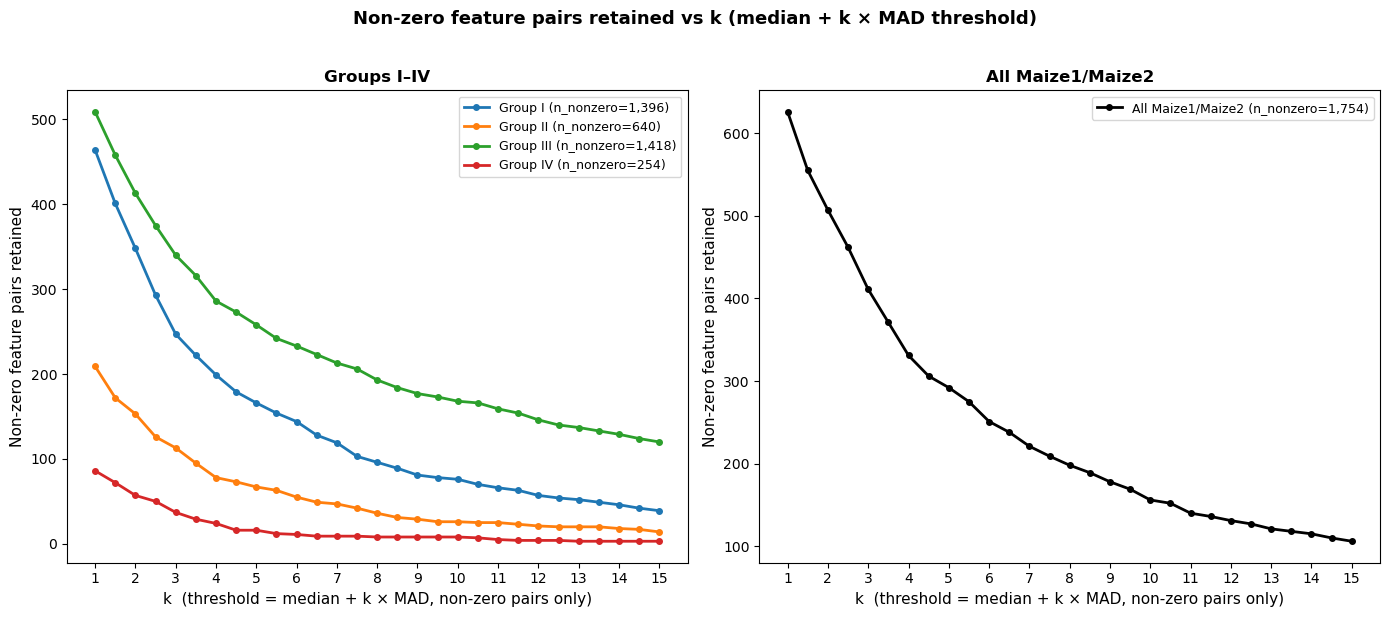

Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_ksweep_scatter_overlay_nonzero.png


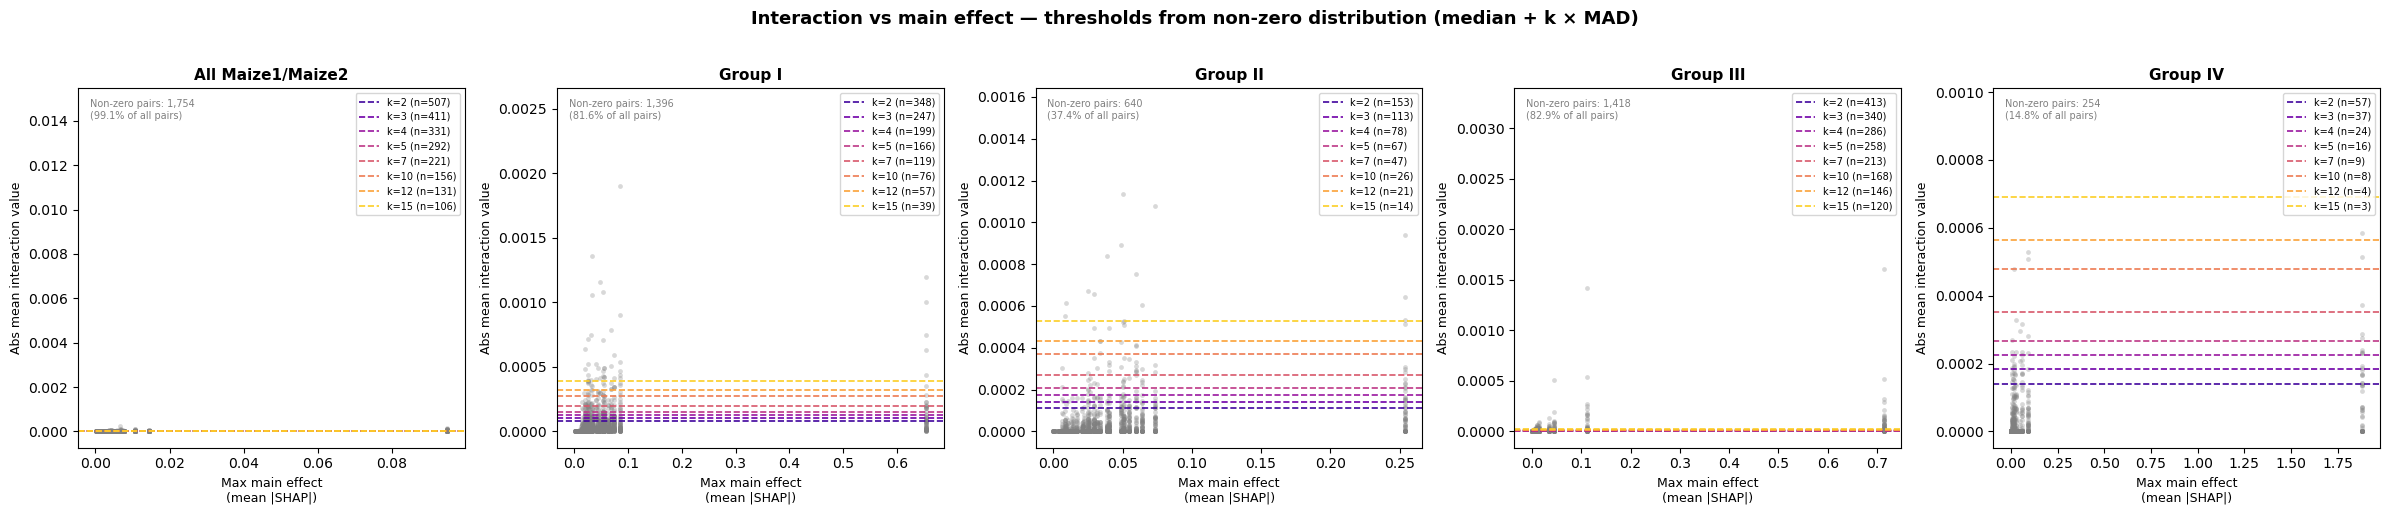

In [50]:
# ============================================================
# K-SWEEP (REVISED): MEDIAN + k × MAD THRESHOLD
# COMPUTED FROM NON-ZERO PAIRS ONLY
# ============================================================
# 
# WHY WE RESTRICT TO NON-ZERO PAIRS:
# From the retention table, Groups II and IV have 62.6% and
# 85.2% of all pairs at exactly zero interaction. When the
# majority of values are zero, the median is zero and the
# MAD (which measures typical distance from the median) is
# also zero. This means the threshold becomes:
#   median + k × 0 = 0  for any k
# Every non-zero pair passes regardless of k — the sweep
# has no effect, which is what we saw in the flat lines.
#
# Restricting to non-zero pairs changes the question from:
#   "Is this pair unusual among ALL 1711 pairs?"
# to:
#   "Is this pair unusual among pairs that actually show
#    a detectable interaction?"
#
# The zero pairs are TRUE zeros — those feature combinations
# have no interaction effect in the model whatsoever. They
# should not define the noise floor. The noise floor should
# come from the distribution of pairs that DO have some
# interaction, however small. This is the biologically
# meaningful comparison.
#
# For Groups I and III this makes little practical difference
# since most pairs are non-zero. For Groups II and IV it
# gives us a meaningful threshold for the first time.
#
# The threshold for a given k and group is:
#   threshold = median(nonzero_abs_interactions)
#               + k × MAD(nonzero_abs_interactions)
#
# Any pair with abs mean interaction > threshold is retained.
# Pairs that are exactly zero are always excluded — they have
# no interaction to report regardless of k.
# ============================================================

from scipy.stats import median_abs_deviation

# --- Step 1: Compute non-zero absolute mean interactions ---
# We need this before computing medians and MADs.
# Also store which pairs are non-zero for later plotting.

print("Non-zero pair counts and threshold components per group:\n")

abs_means_nonzero = {}   # non-zero abs interactions only
n_total           = {}   # total upper-triangle pairs
n_nonzero         = {}   # pairs with abs interaction > 0
group_medians_nz  = {}   # median of non-zero values
group_mads_nz     = {}   # MAD of non-zero values

for group in GROUPS:
    # abs_means was computed in Step 1 of the exploratory
    # analysis — abs mean interaction per upper-triangle pair
    abs_vals = np.abs(mean_interaction_per_pair[group])

    # Identify non-zero pairs
    # Using a small epsilon rather than strict == 0 to account
    # for floating point representation of true zeros
    nonzero_mask = abs_vals > 0.0
    nonzero_vals = abs_vals[nonzero_mask]

    # Store for downstream use
    abs_means_nonzero[group] = nonzero_vals
    n_total[group]           = len(abs_vals)
    n_nonzero[group]         = nonzero_mask.sum()

    # Compute median and MAD from non-zero values only
    med = np.median(nonzero_vals)
    mad = median_abs_deviation(nonzero_vals, scale=1)

    group_medians_nz[group] = med
    group_mads_nz[group]    = mad

    # Report: what fraction of pairs are non-zero, and what
    # does the threshold look like at a few representative k
    pct_nonzero = 100 * n_nonzero[group] / n_total[group]
    print(f"Group {group} ({GROUP_LABELS[group]}):")
    print(f"  Total pairs     : {n_total[group]:,}")
    print(f"  Non-zero pairs  : {n_nonzero[group]:,} "
          f"({pct_nonzero:.1f}% of all pairs)")
    print(f"  Median (nonzero): {med:.8f}")
    print(f"  MAD   (nonzero): {mad:.8f}")
    if mad > 0:
        print(f"  Ratio med/MAD   : {med/mad:.2f}")
    else:
        # MAD of zero would mean all non-zero values are
        # identical — very unlikely but worth flagging
        print(f"  WARNING: MAD is zero even among non-zero pairs.")
        print(f"  All non-zero pairs have identical values.")
    print(f"  Example thresholds:")
    for k_ex in [3, 5, 7, 10, 12, 15]:
        t = med + k_ex * mad
        n = (nonzero_vals > t).sum()
        print(f"    k={k_ex:2d}: threshold={t:.8f}, "
              f"pairs retained={n:,}")
    print()

# --- Step 2: Sweep k values ---
# For each group and each k, count how many NON-ZERO pairs
# survive the threshold. Zero pairs are always excluded and
# do not contribute to the count at any k.

k_values = np.arange(1, 15.5, 0.5)

print("\nEdges retained (non-zero pairs only) per group across k:\n")

retention_rows_nz = []
for k in k_values:
    row = {"k": k}
    for group in GROUPS:
        # Threshold derived from non-zero distribution
        threshold  = group_medians_nz[group] + k * group_mads_nz[group]
        # Count non-zero pairs that exceed this threshold
        n_retained = (abs_means_nonzero[group] > threshold).sum()
        row[group] = n_retained
    retention_rows_nz.append(row)

retention_df_nz = pd.DataFrame(retention_rows_nz).set_index("k")
print(retention_df_nz.to_string())
print()

# Save the revised table
retention_table_path_nz = os.path.join(
    NETWORK_DIR, "interaction_ksweep_retention_table_nonzero.csv"
)
retention_df_nz.to_csv(retention_table_path_nz)
print(f"Saved retention table: {retention_table_path_nz}\n")

# ============================================================
# PLOT 1: RETENTION CURVES ACROSS K (NON-ZERO VERSION)
# ============================================================
# Same layout as before — Groups I-IV left, All right —
# but now reflecting non-zero pair retention only.
# The y-axis maximum is now the number of non-zero pairs
# per group rather than the total 1711.
# ============================================================

fig, (ax_groups, ax_all) = plt.subplots(1, 2, figsize=(14, 6))

group_colors_sweep = {
    "I"  : "#1f77b4",
    "II" : "#ff7f0e",
    "III": "#2ca02c",
    "IV" : "#d62728",
}

# Left panel: Groups I-IV
for group in ["I", "II", "III", "IV"]:
    ax_groups.plot(
        k_values,
        retention_df_nz[group].values,
        label     = (f"{GROUP_LABELS[group]} "
                     f"(n_nonzero={n_nonzero[group]:,})"),
        color     = group_colors_sweep[group],
        linewidth = 2.0,
        marker    = "o",
        markersize= 4,
    )

ax_groups.set_xlabel(
    "k  (threshold = median + k × MAD, non-zero pairs only)",
    fontsize=11
)
ax_groups.set_ylabel(
    "Non-zero feature pairs retained", fontsize=11
)
ax_groups.set_title("Groups I–IV", fontsize=12, fontweight="bold")
ax_groups.legend(fontsize=9)
ax_groups.set_xticks(k_values[::2])

# Right panel: All group
ax_all.plot(
    k_values,
    retention_df_nz["All"].values,
    color     = "black",
    linewidth = 2.0,
    marker    = "o",
    markersize= 4,
    label     = (f"{GROUP_LABELS['All']} "
                 f"(n_nonzero={n_nonzero['All']:,})"),
)
ax_all.set_xlabel(
    "k  (threshold = median + k × MAD, non-zero pairs only)",
    fontsize=11
)
ax_all.set_ylabel("Non-zero feature pairs retained", fontsize=11)
ax_all.set_title("All Maize1/Maize2", fontsize=12, fontweight="bold")
ax_all.legend(fontsize=9)
ax_all.set_xticks(k_values[::2])

fig.suptitle(
    "Non-zero feature pairs retained vs k (median + k × MAD threshold)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_path = os.path.join(
    NETWORK_DIR, "interaction_ksweep_retention_curves_nonzero.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

# ============================================================
# PLOT 2: SCATTER WITH K THRESHOLDS OVERLAID (NON-ZERO)
# ============================================================
# Recreates the interaction vs main effect scatter but now
# the threshold lines are derived from the non-zero
# distribution. Gray points are ALL pairs. Colored threshold
# lines show which pairs survive at each k.
#
# An additional panel annotation reports n_nonzero so you
# can see the starting pool for each group's threshold.
# ============================================================

k_to_show  = [2, 3, 4, 5, 7, 10, 12, 15]
k_colors   = plt.cm.plasma(np.linspace(0.1, 0.9, len(k_to_show)))

fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax_idx, group in enumerate(GROUPS):
    ax = axes[ax_idx]

    # Recompute pair-level main effect and abs interaction
    # (same as Step 3 of exploratory analysis)
    shap_array    = shap_data[group]["shap_all"]
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    interact      = shap_data[group]["shap_interaction_all"]
    mean_matrix   = interact.mean(axis=0)
    n_features    = len(feature_names[group])

    pair_main  = []
    pair_inter = []
    for j in range(n_features):
        for k_idx in range(j + 1, n_features):
            pair_main.append(
                max(mean_abs_shap[j], mean_abs_shap[k_idx])
            )
            pair_inter.append(abs(mean_matrix[j, k_idx]))

    pair_main  = np.array(pair_main)
    pair_inter = np.array(pair_inter)

    # All pairs in gray — including zeros
    ax.scatter(
        pair_main, pair_inter,
        alpha=0.3, s=12, color="gray", linewidths=0,
        zorder=1, label="_nolegend_",
    )

    # Threshold lines from NON-ZERO distribution
    for k_line, color in zip(k_to_show, k_colors):
        threshold = (group_medians_nz[group]
                     + k_line * group_mads_nz[group])
        # Count how many pairs (including zeros) survive —
        # zeros never survive since threshold > 0 now
        n_above   = (pair_inter > threshold).sum()
        ax.axhline(
            threshold,
            color=color, linewidth=1.2, linestyle="--",
            label=f"k={k_line} (n={n_above})",
            zorder=2,
        )

    # Annotate with non-zero pair count so context is clear
    ax.annotate(
        f"Non-zero pairs: {n_nonzero[group]:,}\n"
        f"({100*n_nonzero[group]/n_total[group]:.1f}% of all pairs)",
        xy=(0.03, 0.97), xycoords="axes fraction",
        fontsize=7, ha="left", va="top", color="gray",
        bbox=dict(boxstyle="round,pad=0.2",
                  fc="white", alpha=0.7, ec="none")
    )

    ax.set_title(GROUP_LABELS[group],
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Max main effect\n(mean |SHAP|)", fontsize=9)
    ax.set_ylabel("Abs mean interaction value", fontsize=9)
    ax.legend(fontsize=7, loc="upper right")

fig.suptitle(
    "Interaction vs main effect — thresholds from non-zero "
    "distribution (median + k × MAD)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
save_path = os.path.join(
    NETWORK_DIR,
    "interaction_ksweep_scatter_overlay_nonzero.png"
)
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Saved: {save_path}")
plt.show()
plt.close()

## SHAP Interaction Networks

In [51]:
# ============================================================
# PARAMETER: INTERACTION EFFECT SIZE THRESHOLD
# ============================================================
# K_INTERACTION controls the stringency of the effect size
# threshold applied to Shapley interaction networks.
#
# The threshold for each group is:
#   threshold = median(nonzero_abs_interactions)
#               + K_INTERACTION × MAD(nonzero_abs_interactions)
#
# where median and MAD are computed from the all-samples
# interaction array (shap_interaction_all) for that group,
# using only pairs with non-zero absolute mean interaction
# values. This threshold is then applied uniformly to all
# three label subsets (all, Maize1, Maize2) within that group.
#
# K_INTERACTION = 12 was selected based on exploratory
# analysis of the non-zero interaction value distributions
# across groups (see interaction_ksweep_retention_table_nonzero.csv).
# At k=12 the threshold sits well above the bulk of near-zero
# pairs while retaining biologically interpretable numbers of
# edges across groups. Because the threshold is group-specific
# (each group has its own median and MAD), the same k applies
# a consistent standard of evidence across groups regardless
# of their different absolute interaction value scales.
#
# To adjust stringency: increase K_INTERACTION to retain fewer
# edges (stricter), decrease to retain more (more permissive).
# ============================================================

# ============================================================
# FUNCTION: compute_interaction_significance
# ============================================================
# Filters Shapley interaction feature pairs using a robust
# effect size threshold rather than a parametric significance
# test.
#
# METHODS NOTE:
# Initial analysis used a one-sample t-test with BH FDR
# correction to identify significant interactions. However,
# with n=362-3536 samples per label subset, statistical power
# is very high and even biologically trivial interactions
# pass significance at stringent thresholds (q<=0.0005).
# Exploratory analysis of the interaction value distributions
# revealed heavy negative skew across all groups, violating
# t-test assumptions, and confirmed that the over-detection
# problem is one of effect size rather than significance.
#
# The adopted approach filters by effect size relative to
# each group's own noise floor. For each group, the threshold
# is derived from the all-samples interaction array:
#   threshold = median(abs_mean_interactions, nonzero only)
#               + K_INTERACTION × MAD(abs_mean_interactions,
#                                     nonzero only)
#
# Only non-zero pairs are used to compute the noise floor
# because Groups II and IV have 62.6% and 85.2% of pairs at
# exactly zero respectively — including zeros drives the
# median and MAD to zero, making the threshold uninformative.
# Zero pairs are true zeros (no interaction in the model)
# and are excluded from both the threshold computation and
# the retained edge set.
#
# The same threshold is applied to all three label subsets
# (all samples, Maize1/dominant, Maize2/submissive) within
# each group, ensuring that differences in retained edges
# between subgenomes reflect biology rather than different
# noise floors. The threshold is always derived from the
# all-samples array — the largest and most stable sample —
# regardless of which label subset is being filtered.
#
# Edge weight is the mean Shapley interaction value across
# samples in the relevant subset. Sign is preserved: positive
# values indicate synergistic interactions (features amplify
# each other's importance), negative values indicate
# antagonistic interactions (features suppress each other).
# ============================================================
def compute_interaction_significance(
    interaction_array,
    feature_labels,
    threshold,
):
    """
    Filter pairwise Shapley interaction values by a
    pre-computed robust effect size threshold.

    For each upper-triangle feature pair (j, k), computes
    the mean Shapley interaction value across all samples in
    interaction_array. Pairs whose absolute mean interaction
    exceeds the threshold are retained as meaningful edges.
    Pairs at exactly zero are always excluded.

    The threshold must be pre-computed from the all-samples
    interaction array for this group using the helper
    compute_interaction_threshold(), and passed in here.
    This ensures the same noise floor is applied to all
    label subsets (all, Maize1, Maize2) within a group.

    Parameters
    ----------
    interaction_array : np.ndarray, shape
                        (n_samples, n_features, n_features)
        Shapley interaction values. Entry [i, j, k] is the
        interaction index between features j and k for
        sample i. Can be the all-samples array or a
        label-specific subset — the threshold is the same
        regardless of which subset is passed.
    feature_labels : list of str
        Feature names corresponding to array axes 1 and 2.
        Must match the feature order used when computing
        the threshold.
    threshold : float
        Pre-computed effect size threshold for this group.
        Derived from all-samples non-zero distribution as:
        median(abs_mean) + K_INTERACTION × MAD(abs_mean).
        Use compute_interaction_threshold() to produce this.

    Returns
    -------
    sig_edges : pd.DataFrame
        Retained edges (abs_weight > threshold), columns:
        source, target, weight, abs_weight, threshold.
        Sorted by abs_weight descending.
        Edge weight is the signed mean interaction value —
        positive = synergistic, negative = antagonistic.
    all_edges : pd.DataFrame
        All upper-triangle pairs including those below
        threshold and zero pairs, with columns:
        source, target, weight, abs_weight, above_threshold.
        Useful for supplemental reporting and QC.
    """
    n_features = len(feature_labels)

    sources  = []
    targets  = []
    weights  = []   # signed mean interaction value per pair

    for j in range(n_features):
        for k in range(j + 1, n_features):
            # Mean interaction across all samples in this
            # subset — this is the edge weight in the network
            pair_values = interaction_array[:, j, k]
            sources.append(feature_labels[j])
            targets.append(feature_labels[k])
            weights.append(pair_values.mean())

    weights     = np.array(weights)
    abs_weights = np.abs(weights)

    # A pair is retained if:
    #   1. Its absolute mean interaction exceeds the threshold
    #   2. It is not exactly zero (true zeros have no
    #      interaction in the model and are never retained)
    above_threshold = (abs_weights > threshold) & (abs_weights > 0.0)

    all_edges = pd.DataFrame({
        "source"          : sources,
        "target"          : targets,
        "weight"          : weights,
        "abs_weight"      : abs_weights,
        "above_threshold" : above_threshold,
    })

    sig_edges = all_edges[above_threshold].copy()
    sig_edges["threshold"] = threshold
    sig_edges = sig_edges.drop(
        columns=["above_threshold"]
    ).sort_values(
        by="abs_weight", ascending=False
    ).reset_index(drop=True)

    return sig_edges, all_edges


def compute_interaction_threshold(
    interaction_array_all,
    feature_labels,
    k,
):
    """
    Compute the robust effect size threshold for a group's
    Shapley interaction networks from the all-samples array.

    Threshold = median(abs_mean_nonzero)
                + k × MAD(abs_mean_nonzero)

    where abs_mean_nonzero is the set of absolute mean
    interaction values across all upper-triangle feature
    pairs that are strictly greater than zero.

    Parameters
    ----------
    interaction_array_all : np.ndarray, shape
                            (n_samples, n_features, n_features)
        All-samples Shapley interaction array for this group.
        Always use shap_interaction_all here — never a
        label-specific subset — to ensure the threshold
        reflects the most stable noise floor estimate.
    feature_labels : list of str
        Feature names corresponding to array axes 1 and 2.
    k : float or int
        Number of MADs above the median to set the threshold.
        Higher k = stricter = fewer retained edges.
        K_INTERACTION = 12 was selected via exploratory
        sweep (see interaction_ksweep_retention_table_nonzero.csv).

    Returns
    -------
    threshold : float
        The computed threshold value in interaction value
        units. Pass directly to compute_interaction_significance().
    diagnostics : dict
        Median, MAD, n_total_pairs, n_nonzero_pairs, and
        pct_nonzero for QC and methods reporting.
    """
    n_features = len(feature_labels)

    # Compute mean interaction per upper-triangle pair
    mean_matrix = interaction_array_all.mean(axis=0)
    upper_mask  = np.triu(
        np.ones((n_features, n_features), dtype=bool), k=1
    )
    abs_means   = np.abs(mean_matrix[upper_mask])

    # Restrict to non-zero pairs for noise floor estimation
    nonzero_mask = abs_means > 0.0
    nonzero_vals = abs_means[nonzero_mask]

    if len(nonzero_vals) == 0:
        # Pathological case: all pairs are exactly zero
        # Return zero threshold — no edges will be retained
        print("  WARNING: all pairs are zero. Threshold set to 0.")
        return 0.0, {
            "median"       : 0.0,
            "mad"          : 0.0,
            "threshold"    : 0.0,
            "n_total_pairs": int(upper_mask.sum()),
            "n_nonzero"    : 0,
            "pct_nonzero"  : 0.0,
            "k"            : k,
        }

    med       = np.median(nonzero_vals)
    mad       = median_abs_deviation(nonzero_vals, scale=1)
    threshold = med + k * mad

    diagnostics = {
        "median"        : med,
        "mad"           : mad,
        "threshold"     : threshold,
        "n_total_pairs" : int(upper_mask.sum()),
        "n_nonzero"     : int(nonzero_mask.sum()),
        "pct_nonzero"   : 100 * nonzero_mask.sum() / len(abs_means),
        "k"             : k,
    }

    return threshold, diagnostics


In [52]:
# ============================================================
# COMBINED INTERACTION FIGURES
# ============================================================
# Figure 1: All-samples networks, 3×2 layout.
#   [ All       | Node legend ]
#   [ Group I   | Group II    ]
#   [ Group III | Group IV    ]
#
# Figure 2: Label comparison, 6-row × 2-col layout.
#   Rows 0–4: one group per row (All, I, II, III, IV)
#   Columns: Maize1 dominant (left) vs Maize2 submissive (right)
#   Row 5: node size legend spanning both columns
#
# Edges shown are those whose absolute mean Shapley interaction
# value exceeds the group-specific robust effect size threshold:
#   threshold = median(abs_mean, nonzero pairs)
#               + K_INTERACTION × MAD(abs_mean, nonzero pairs)
#
# The threshold is derived from the all-samples interaction
# array for each group and applied uniformly to all label
# subsets within that group (see compute_interaction_threshold).
#
# Edge widths are scaled globally within each figure so that
# interaction magnitudes are directly comparable across panels.
# Scaling is independent between Figure 1 and Figure 2 —
# do not compare edge thickness across figures.
# ============================================================


def _draw_node_legend(ax, global_max_degree, node_scaling_factor):
    """
    Draw a node size legend on ax.
    Shows representative degree values up to global_max_degree.
    Reused by both combined figure functions.
    Node size is scaled linearly by degree using node_scaling_factor,
    consistent with assign_node_size() used in all network panels.
    """
    ax.set_axis_off()
    ax.text(
        0.5, 0.95, "Node Degree",
        transform   = ax.transAxes,
        fontsize    = 13,
        fontweight  = 'bold',
        ha          = 'center',
        va          = 'top',
    )
    y_cursor     = 0.80
    node_x       = 0.30
    label_x      = 0.48
    example_degs = [1, 5, 10, 20]

    for deg in example_degs:
        if deg > global_max_degree:
            continue
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        ax.scatter(
            node_x, y_cursor,
            s          = size,
            color      = 'gray',
            alpha      = 0.4,
            edgecolors = 'black',
            linewidths = 0.8,
            transform  = ax.transAxes,
            zorder     = 3,
            clip_on    = False,
        )
        ax.text(
            label_x, y_cursor,
            f"Degree {deg}",
            transform = ax.transAxes,
            fontsize  = 10,
            va        = 'center',
            ha        = 'left',
        )
        y_cursor -= 0.22

        
def _draw_edge_legend(ax):
    """
    Draw edge direction legend (synergistic/antagonistic) on ax.
    Separated from _draw_node_legend so the two legends can
    occupy independent panels in the label comparison figure.
    """
    ax.set_axis_off()
    ax.text(
        0.5, 0.95, "Edge direction",
        transform  = ax.transAxes,
        fontsize   = 13,
        fontweight = 'bold',
        ha         = 'center',
        va         = 'top',
    )
    for color, label, y in [
        ("#ffa09b", "Synergistic (features amplify each other's importance)", 0.65),
        ("#0047ab", "Antagonistic (features suppress each other's importance)", 0.40),
    ]:
        ax.plot(
            [0.05, 0.25], [y, y],
            transform      = ax.transAxes,
            color          = color,
            lw             = 3,
            solid_capstyle = 'round',
        )
        ax.text(
            0.30, y, label,
            transform = ax.transAxes,
            fontsize  = 10,
            va        = 'center',
            ha        = 'left',
        )


def _draw_combined_legend(ax, global_max_degree, node_scaling_factor):
    """
    Draws BOTH the node degree and edge direction legends vertically 
    stacked on a single axis. Specifically designed for the 3x2 
    all-samples interaction figure.
    """
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # 1. Node Degree Block (Top Half)
    ax.text(
        0.5, 1.02, "Node Degree",
        transform=ax.transAxes, fontsize=15, fontweight='bold',
        ha='center', va='top'
    )
    
    optimal_y_spacings = [0.90, 0.77, 0.62, 0.45] 
    node_x  = 0.30
    label_x = 0.55
    example_degs = [1, 5, 10, 20]
    valid_degrees = [deg for deg in example_degs if deg <= global_max_degree]

    for i, deg in enumerate(valid_degrees):
        y_cursor = optimal_y_spacings[i]
        size = assign_node_size(deg, scaling_factor=node_scaling_factor)
        ax.scatter(
            node_x, y_cursor, s=size, color='gray', alpha=0.4,
            edgecolors='black', linewidths=1.0, transform=ax.transAxes, 
            zorder=3, clip_on=False
        )
        ax.text(
            label_x, y_cursor, f"Degree {deg}",
            transform=ax.transAxes, fontsize=12, va='center', ha='left'
        )

    # 2. Edge Co-variation Block (Bottom Half)
    ax.text(
        0.5, 0.30, "Edge Co-variation",
        transform=ax.transAxes, fontsize=15, fontweight='bold',
        ha='center', va='top'
    )
    
    for color, label, y in [
        ("#ffa09b", "Synergistic\n(features amplify each other)", 0.20),
        ("#0047ab", "Antagonistic\n(features suppress each other)", 0.12),
    ]:
        ax.plot(
            [0.15, 0.35], [y, y],
            transform=ax.transAxes, color=color, lw=4, solid_capstyle='round'
        )
        ax.text(
            0.40, y, label,
            transform=ax.transAxes, fontsize=11, va='center', ha='left'
        )
        
        
def _draw_network_panel(
    ax,
    Gx,
    layout,
    title,
    global_edge_thickness_fn,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    node_scaling_factor,
    k_interaction,
    row_label=None,
):
    """
    Draw a single interaction network panel onto ax.
    Reused by both combined figure functions.

    Parameters
    ----------
    ax                       : matplotlib Axes
    Gx                       : nx.Graph
        Contains only edges that passed the effect size
        threshold (abs_mean > median + k × MAD).
    layout                   : dict, node positions
    title                    : str, panel title
    global_edge_thickness_fn : callable
        Takes a raw edge weight and returns line thickness.
        Derived from the global max weight across all panels
        in this figure so edge widths are comparable.
    feature_rename_dict      : dict
    feature_to_group         : dict
    group_to_color           : dict
    node_scaling_factor      : int
    k_interaction            : int or float
        The K_INTERACTION value used for thresholding.
        Included in the empty-network annotation so it is
        clear what standard was applied even when no edges
        survive.
    row_label                : str or None
        If provided, set as the y-axis label on the left
        edge of the panel — used as the group row identifier
        in the label comparison figure.
    """
    if Gx.number_of_nodes() == 0:
        # No pairs exceeded the effect size threshold for
        # this group/label combination. This is a genuine
        # biological result — not a methodological failure.
        ax.set_title(
            f"{title}\n"
            f"(no interactions above threshold\n"
            f"median + {k_interaction}×MAD)",
            fontsize   = 11,
            fontweight = 'bold',
        )
        ax.axis('off')
        if row_label:
            ax.set_ylabel(
                row_label,
                fontsize   = 11,
                fontweight = 'bold',
                rotation   = 90,
                labelpad   = 10,
            )
        return

    # --- Edge attributes ---
    # Weight is signed mean interaction value:
    #   positive = synergistic (red/pink)
    #   negative = antagonistic (blue)
    edge_weights = [Gx[u][v]['weight'] for u, v in Gx.edges()]
    edge_colours = [assign_colour(w) for w in edge_weights]
    edge_widths  = [global_edge_thickness_fn(w) for w in edge_weights]

    # --- Node attributes ---
    # Size scaled by degree; color by feature group membership
    node_sizes = [
        assign_node_size(deg, scaling_factor=node_scaling_factor)
        for _, deg in Gx.degree()
    ]
    node_colors = make_colors_transparent(
        assign_node_colors_by_group(Gx, feature_to_group, group_to_color),
        alpha=0.7,
    )
    labels = {
        node: feature_rename_dict.get(node, node)
        for node in Gx.nodes()
    }

    nx.draw(
        Gx,
        pos         = layout,
        ax          = ax,
        with_labels = True,
        labels      = labels,
        node_size   = node_sizes,
        node_color  = node_colors,
        edge_color  = edge_colours,
        width       = edge_widths,
        font_size   = 9,
        font_weight = "bold",
    )

    # Panel annotation: node and edge counts for reference
    degrees = [deg for _, deg in Gx.degree()]
    ax.annotate(
        f"Nodes: {Gx.number_of_nodes()}  |  "
        f"Edges: {Gx.number_of_edges()}\n"
        f"Degree range: {min(degrees)}–{max(degrees)}",
        xy       = (0.02, 0.02),
        xycoords = 'axes fraction',
        fontsize = 9,
        va       = 'bottom',
        ha       = 'left',
        bbox     = dict(
            boxstyle = 'round,pad=0.3',
            fc       = 'white',
            alpha    = 0.7,
            ec       = 'none',
        ),
    )
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)

    if row_label:
        ax.set_ylabel(
            row_label,
            fontsize   = 11,
            fontweight = 'bold',
            rotation   = 90,
            labelpad   = 10,
        )


def plot_interaction_combined_all(
    interaction_network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    k_interaction,
    node_scaling_factor = 200,
    max_edge_thickness  = 4.0,
):
    """
    Plot a 3×2 combined figure of all-samples interaction networks.

    Layout:
        [ All Maize1/Maize2  | Node/edge legend ]
        [ Group I            | Group II         ]
        [ Group III          | Group IV         ]

    Edges shown are those exceeding each group's robust effect
    size threshold (median + k × MAD of non-zero all-samples
    interactions). Edge widths are scaled globally across all
    five panels so that interaction magnitudes are directly
    comparable across groups.

    Parameters
    ----------
    interaction_network_data : dict
        Keyed by group then label_key. Each entry contains
        'Gx', 'layout', 'sig_edges'. Produced by the
        interaction network loop using
        compute_interaction_significance().
    group_labels        : dict
    feature_rename_dict : dict
    feature_to_group    : dict
    group_to_color      : dict
    save_path           : str
    k_interaction       : int or float
        The K_INTERACTION value used for thresholding.
        Passed through to panel titles and empty-network
        annotations so the figure is self-documenting.
    node_scaling_factor : int
    max_edge_thickness  : float
    """
    # Panel positions: (group_key, row, col)
    # Legend occupies (row=0, col=1)
    panel_order = [
        ("All", 0, 0),
        ("I",   1, 0),
        ("II",  1, 1),
        ("III", 2, 0),
        ("IV",  2, 1),
    ]

    # --- Global edge weight scaling across all 5 panels ---
    # Collecting weights from all panels before drawing so
    # that the thickest edge represents the globally strongest
    # interaction — not just the strongest within one group.
    all_abs_weights = []
    for group, _, _ in panel_order:
        Gx = interaction_network_data[group]["all"]["Gx"]
        for u, v in Gx.edges():
            all_abs_weights.append(abs(Gx[u][v]['weight']))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight (all-samples figure): "
          f"{global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    # --- Collect degrees for legend range ---
    all_degrees = []
    for group, _, _ in panel_order:
        Gx = interaction_network_data[group]["all"]["Gx"]
        all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # --- Build figure ---
    fig = plt.figure(figsize=(16, 20), layout='constrained')
    gs  = fig.add_gridspec(3, 2)

    # --- Draw network panels ---
    for group, row, col in panel_order:
        ax     = fig.add_subplot(gs[row, col])
        Gx     = interaction_network_data[group]["all"]["Gx"]
        layout = interaction_network_data[group]["all"]["layout"]
        _draw_network_panel(
            ax                       = ax,
            Gx                       = Gx,
            layout                   = layout,
            title                    = (
                f"{group_labels[group]}\n"
                f"(median + {k_interaction}×MAD threshold)"
            ),
            global_edge_thickness_fn = global_edge_thickness,
            feature_rename_dict      = feature_rename_dict,
            feature_to_group         = feature_to_group,
            group_to_color           = group_to_color,
            node_scaling_factor      = node_scaling_factor,
            k_interaction            = k_interaction,
        )

    # --- Legend panel (top right) ---
    ax_legend = fig.add_subplot(gs[0, 1])
    
    # Use the unified stacked legend instead of just the node legend
    _draw_combined_legend(ax_legend, global_max_degree, node_scaling_factor)

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)


def plot_interaction_combined_label(
    interaction_network_data,
    group_labels,
    feature_rename_dict,
    feature_to_group,
    group_to_color,
    save_path,
    k_interaction,
    node_scaling_factor = 200,
    max_edge_thickness  = 4.0,
):
    """
    Plot a 6×2 label comparison figure (Maize1 vs Maize2).

    Layout:
        Col headers: [ Maize1 (dominant) | Maize2 (submissive) ]
        Row 0: All Maize1/Maize2
        Row 1: Group I
        Row 2: Group II
        Row 3: Group III
        Row 4: Group IV
        Row 5: Node size legend (spanning both columns)

    The same group-specific threshold (median + k × MAD,
    derived from all-samples) is applied to both the Maize1
    and Maize2 subsets for each group. This ensures that
    differences in retained edges between subgenomes reflect
    biology rather than different noise floors.

    Edge widths are scaled globally across all 10 network
    panels so that interaction magnitudes are directly
    comparable within and across groups and subgenomes.
    Do not compare edge thickness between this figure and
    the all-samples figure — they use independent scales.

    Parameters
    ----------
    interaction_network_data : dict
    group_labels        : dict
    feature_rename_dict : dict
    feature_to_group    : dict
    group_to_color      : dict
    save_path           : str
    k_interaction       : int or float
        The K_INTERACTION value used for thresholding.
        Passed through to panel titles and empty-network
        annotations so the figure is self-documenting.
    node_scaling_factor : int
    max_edge_thickness  : float
    """
    groups_in_order = ["All", "I", "II", "III", "IV"]
    label_keys      = ["label0", "label1"]

    # --- Global edge weight scaling across all 10 panels ---
    all_abs_weights = []
    for group in groups_in_order:
        for lk in label_keys:
            Gx = interaction_network_data[group][lk]["Gx"]
            for u, v in Gx.edges():
                all_abs_weights.append(abs(Gx[u][v]['weight']))

    global_max_weight = max(all_abs_weights) if all_abs_weights else 1.0
    print(f"Global max abs edge weight (label comparison figure): "
          f"{global_max_weight:.6f}")

    def global_edge_thickness(weight):
        return max_edge_thickness * (abs(weight) / global_max_weight)

    # --- Collect degrees for legend range ---
    all_degrees = []
    for group in groups_in_order:
        for lk in label_keys:
            Gx = interaction_network_data[group][lk]["Gx"]
            all_degrees.extend([deg for _, deg in Gx.degree()])
    global_max_degree = max(all_degrees) if all_degrees else 1

    # --- Build figure ---
    # 5 network rows + 1 shorter legend row
    fig = plt.figure(figsize=(16, 44), layout='constrained')
    gs  = fig.add_gridspec(
        6, 2,
        height_ratios=[1, 1, 1, 1, 1, 0.50],
    )
    # hspace adds proportional vertical space between rows.
    # This requires accessing the constrained layout engine
    # directly — hspace cannot be passed to add_gridspec
    # when layout='constrained' is set on the figure.
    fig.get_layout_engine().set(hspace=0.12)

    # --- Column headers ---
    col_header_labels = {
        0: "Maize1 (dominant)",
        1: "Maize2 (submissive)",
    }
    # x positions in figure fraction — centered over each column
    col_positions = {0: 0.26, 1: 0.74}
    for col, label in col_header_labels.items():
        fig.text(
            col_positions[col], 1.005,
            label,
            fontsize   = 14,
            fontweight = 'bold',
            ha         = 'center',
            va         = 'bottom',
            transform  = fig.transFigure,
        )

    # --- Network panels ---
    # Store axes per row so we can place centered subheadings
    # above each group's row pair after layout is finalized.
    row_axes = {}   # row index -> (ax_left, ax_right)

    for row, group in enumerate(groups_in_order):
        row_axes[row] = {}
        for col, lk in enumerate(label_keys):
            ax     = fig.add_subplot(gs[row, col])
            Gx     = interaction_network_data[group][lk]["Gx"]
            layout = interaction_network_data[group][lk]["layout"]

            row_axes[row][col] = ax   # store for subheading placement

            _draw_network_panel(
                ax                       = ax,
                Gx                       = Gx,
                layout                   = layout,
                title                    = "",
                global_edge_thickness_fn = global_edge_thickness,
                feature_rename_dict      = feature_rename_dict,
                feature_to_group         = feature_to_group,
                group_to_color           = group_to_color,
                node_scaling_factor      = node_scaling_factor,
                k_interaction            = k_interaction,
                row_label                = None,   # replaced by subheadings below
            )

    # --- ADD subheadings centered above each row pair ---
    # Positions are read from the axes bounding boxes after
    # matplotlib finalizes the constrained layout.
    # Must call fig.canvas.draw() first to lock in positions.
    subheading_labels = {
        0: GROUP_LABELS["All"],
        1: GROUP_LABELS["I"],
        2: GROUP_LABELS["II"],
        3: GROUP_LABELS["III"],
        4: GROUP_LABELS["IV"],
    }
    fig.canvas.draw()   # finalize constrained layout positions
    for row in range(len(groups_in_order)):
        ax_left  = row_axes[row][0]
        ax_right = row_axes[row][1]
        pos_left  = ax_left.get_position()
        pos_right = ax_right.get_position()
        # Center x between left edge of left panel and right
        # edge of right panel; y just above the top of the row
        x_center = (pos_left.x0 + pos_right.x1) / 2
        y_top    = pos_left.y1 + 0.004
        fig.text(
            x_center, y_top,
            subheading_labels[row],
            fontsize   = 13,
            fontweight = 'bold',
            ha         = 'center',
            va         = 'bottom',
            transform  = fig.transFigure,
        )

    # --- Node + edge legend (bottom row, spanning both cols) ---
    ax_legend_degree = fig.add_subplot(gs[5, 0])
    ax_legend_edge   = fig.add_subplot(gs[5, 1])
    _draw_node_legend(ax_legend_degree, global_max_degree, node_scaling_factor)
    _draw_edge_legend(ax_legend_edge)

    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    print(f"Saved: {save_path}")
    plt.show()
    plt.close(fig)




### Interaction Individual Networks


Group All (All Maize1/Maize2)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 1,770
    Non-zero pairs  : 1,754 (99.1%)
    Median          : 0.00000138
    MAD             : 0.00000126
    K_INTERACTION   : 12
    Threshold       : 0.00001654
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 1,770
    Non-zero pairs       : 1,754
    Pairs above threshold: 131
    Saved edge tables: groupAll_interaction_all_*.csv
    Saved degree table: groupAll_interaction_all_node_degrees.csv
  Nodes: 50  |  Edges: 131  |  Degree range: 1–30
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_interaction_all_network.png


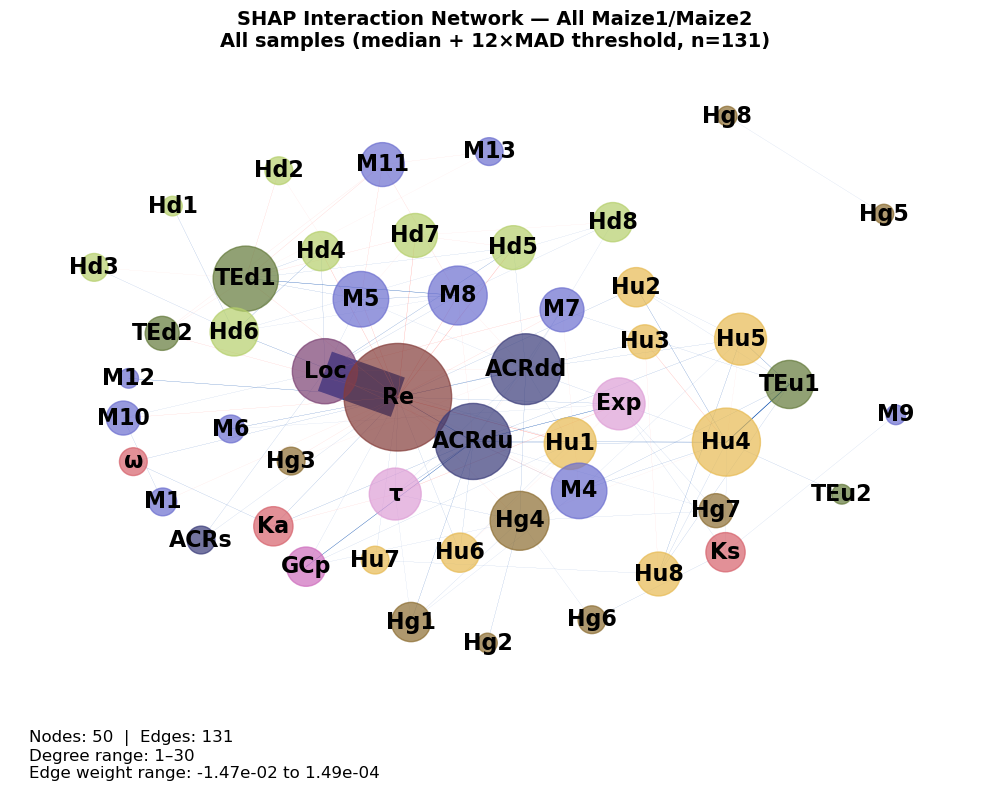


  --- Maize1 (dominant) ---
    Total pairs          : 1,770
    Non-zero pairs       : 1,754
    Pairs above threshold: 138
    Saved edge tables: groupAll_interaction_label0_*.csv
    Saved degree table: groupAll_interaction_label0_node_degrees.csv
  Nodes: 51  |  Edges: 138  |  Degree range: 1–31
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_interaction_label0_network.png


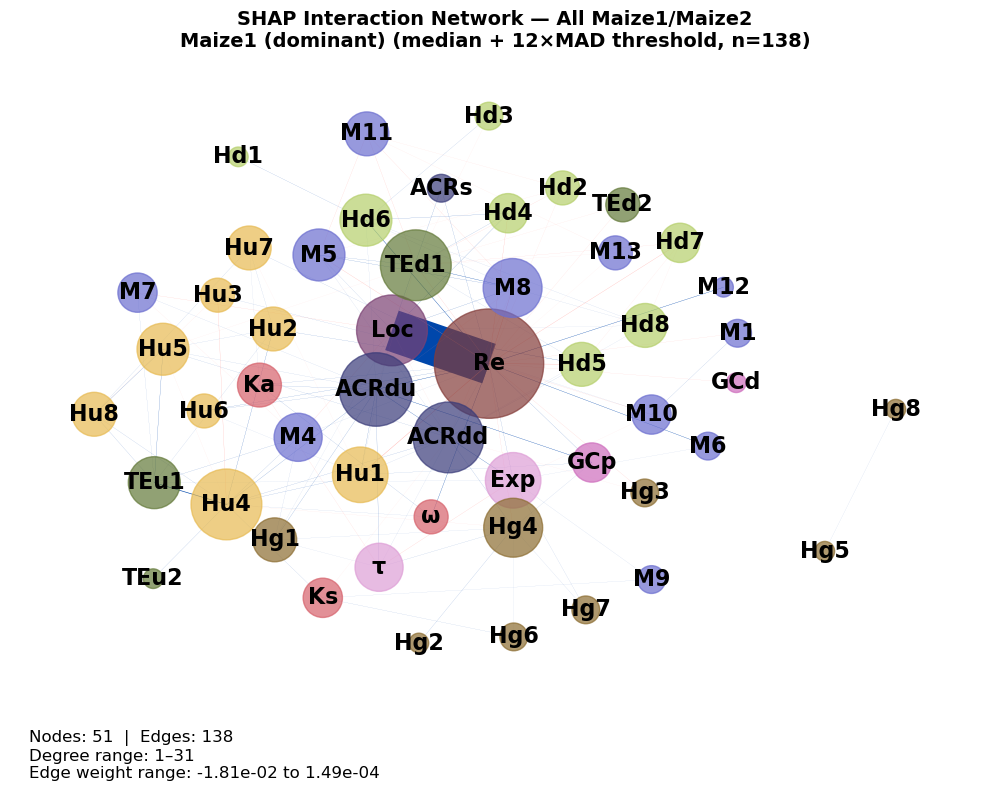


  --- Maize2 (submissive) ---
    Total pairs          : 1,770
    Non-zero pairs       : 1,754
    Pairs above threshold: 133
    Saved edge tables: groupAll_interaction_label1_*.csv
    Saved degree table: groupAll_interaction_label1_node_degrees.csv
  Nodes: 50  |  Edges: 133  |  Degree range: 1–32
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupAll_interaction_label1_network.png


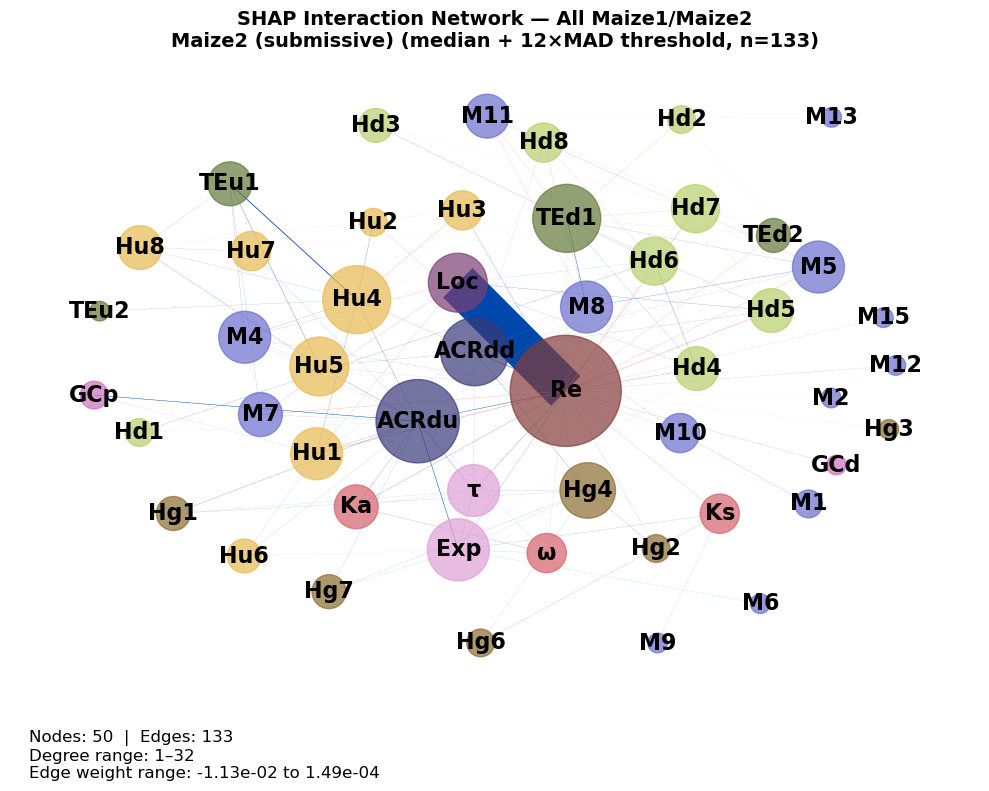


Group I (Group I)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 1,711
    Non-zero pairs  : 1,396 (81.6%)
    Median          : 0.00003018
    MAD             : 0.00002405
    K_INTERACTION   : 12
    Threshold       : 0.00031881
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,396
    Pairs above threshold: 57
    Saved edge tables: groupI_interaction_all_*.csv
    Saved degree table: groupI_interaction_all_node_degrees.csv
  Nodes: 40  |  Edges: 57  |  Degree range: 1–9
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_interaction_all_network.png


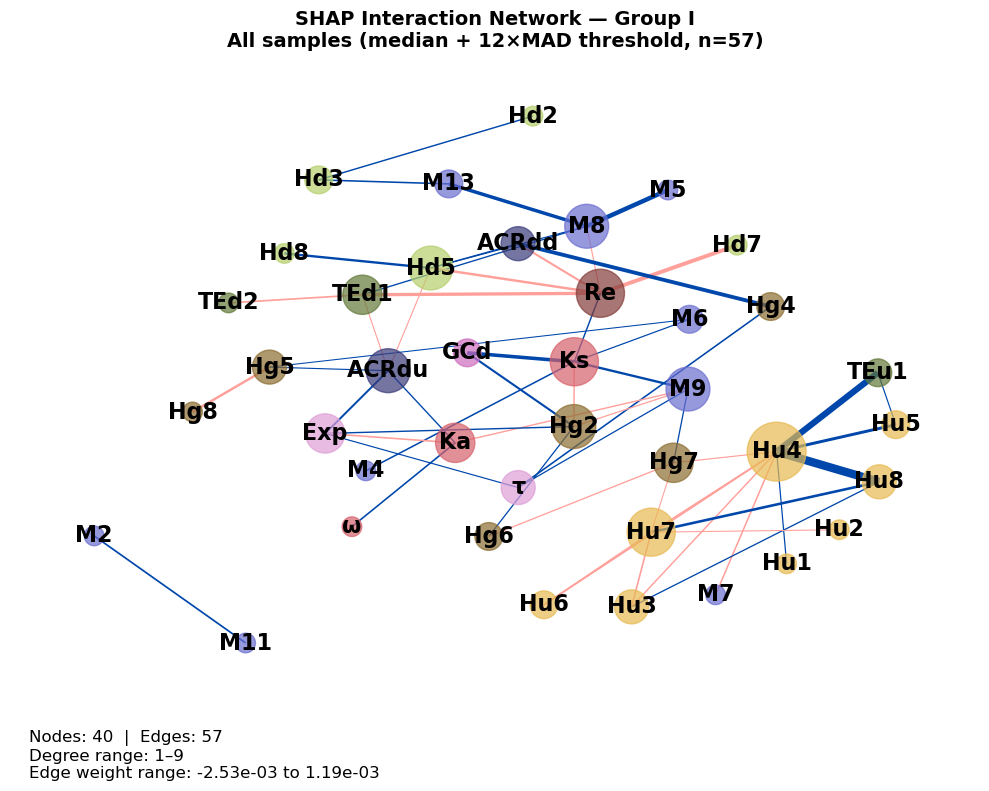


  --- Maize1 (dominant) ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,396
    Pairs above threshold: 70
    Saved edge tables: groupI_interaction_label0_*.csv
    Saved degree table: groupI_interaction_label0_node_degrees.csv
  Nodes: 45  |  Edges: 70  |  Degree range: 1–10
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_interaction_label0_network.png


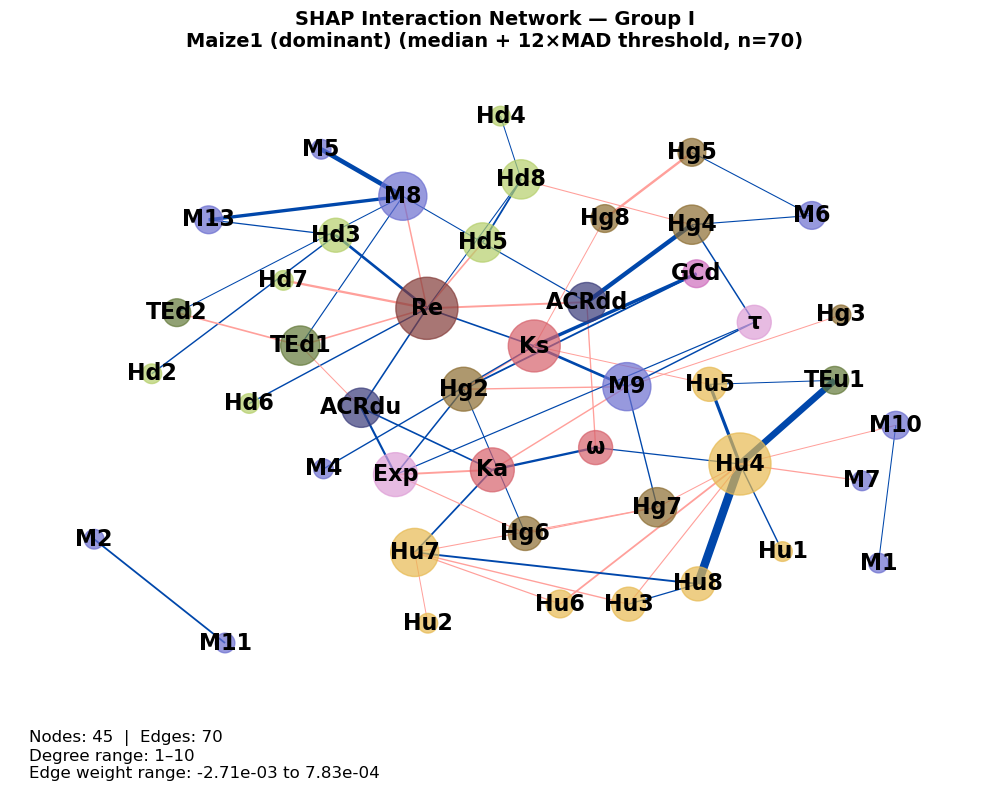


  --- Maize2 (submissive) ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,396
    Pairs above threshold: 65
    Saved edge tables: groupI_interaction_label1_*.csv
    Saved degree table: groupI_interaction_label1_node_degrees.csv
  Nodes: 43  |  Edges: 65  |  Degree range: 1–14
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupI_interaction_label1_network.png


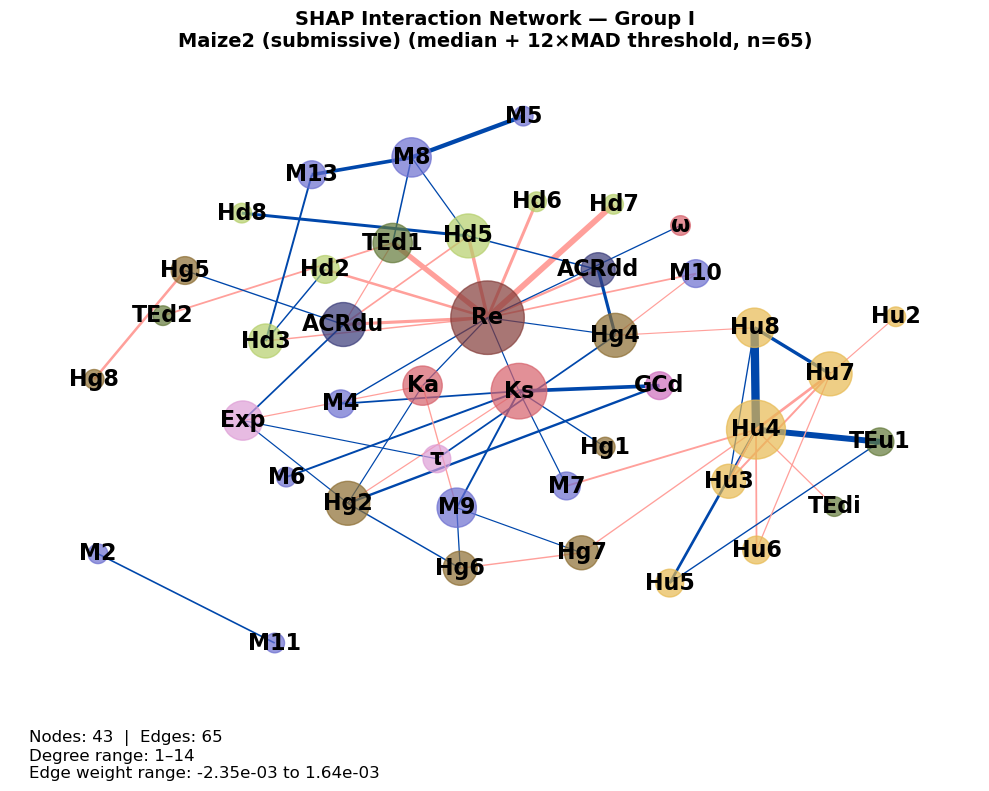


Group II (Group II)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 1,711
    Non-zero pairs  : 640 (37.4%)
    Median          : 0.00004490
    MAD             : 0.00003237
    K_INTERACTION   : 12
    Threshold       : 0.00043332
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 1,711
    Non-zero pairs       : 640
    Pairs above threshold: 21
    Saved edge tables: groupII_interaction_all_*.csv
    Saved degree table: groupII_interaction_all_node_degrees.csv
  Nodes: 24  |  Edges: 21  |  Degree range: 1–4
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_interaction_all_network.png


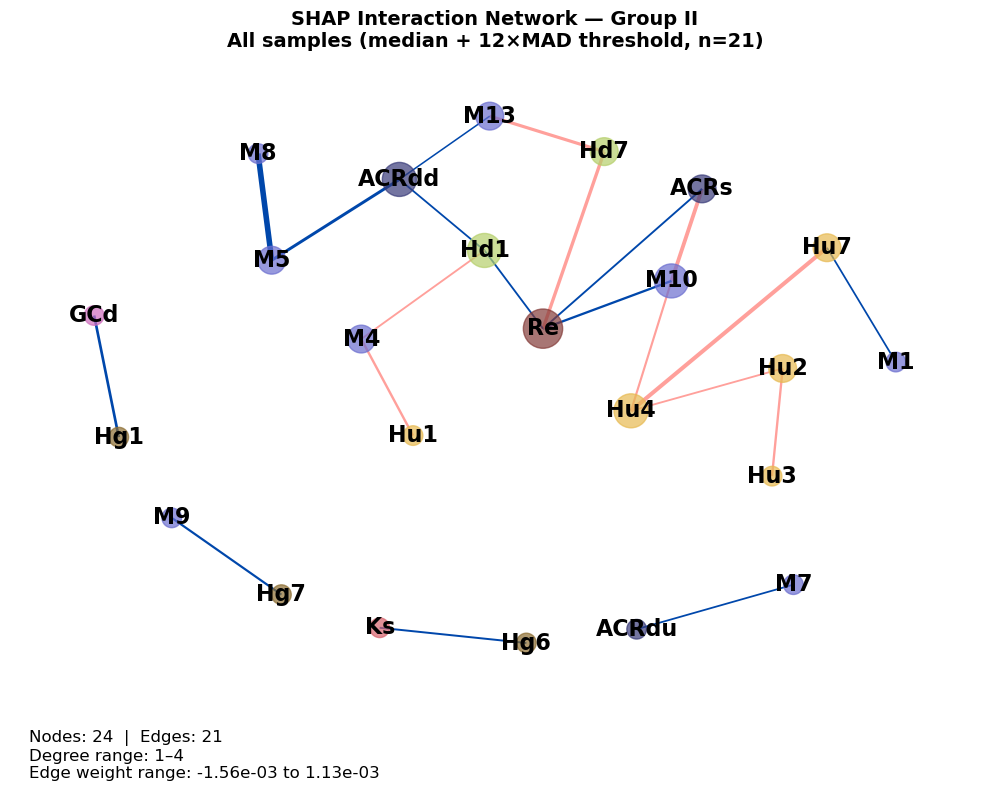


  --- Maize1 (dominant) ---
    Total pairs          : 1,711
    Non-zero pairs       : 640
    Pairs above threshold: 29
    Saved edge tables: groupII_interaction_label0_*.csv
    Saved degree table: groupII_interaction_label0_node_degrees.csv
  Nodes: 27  |  Edges: 29  |  Degree range: 1–7
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_interaction_label0_network.png


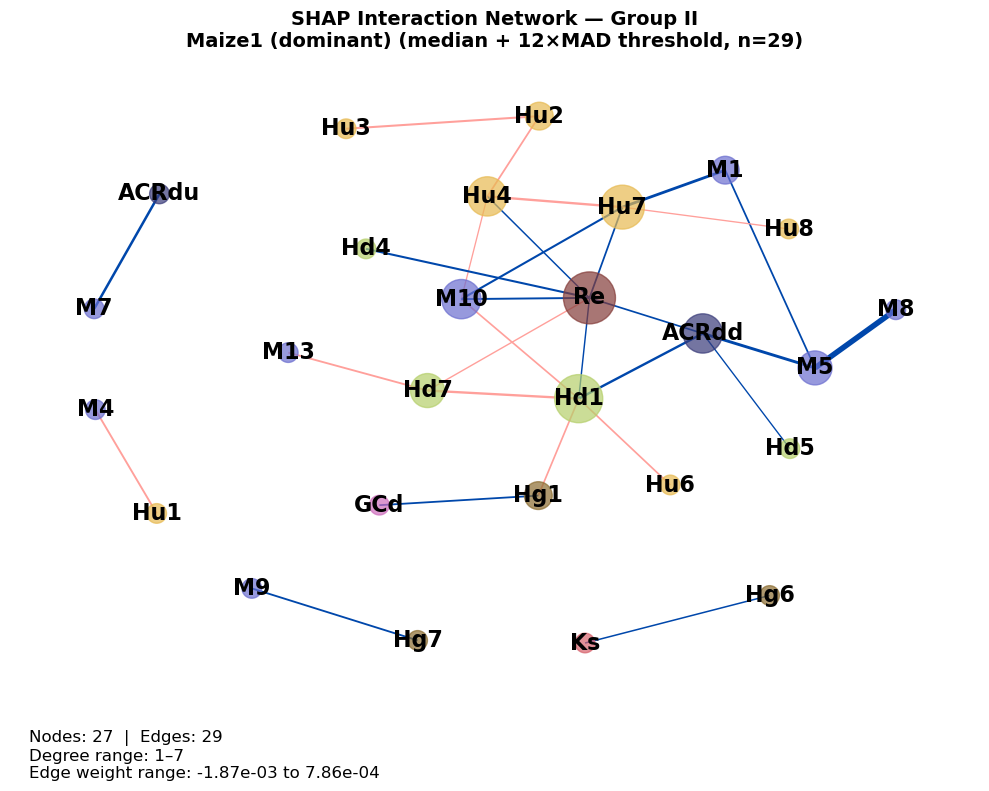


  --- Maize2 (submissive) ---
    Total pairs          : 1,711
    Non-zero pairs       : 640
    Pairs above threshold: 26
    Saved edge tables: groupII_interaction_label1_*.csv
    Saved degree table: groupII_interaction_label1_node_degrees.csv
  Nodes: 28  |  Edges: 26  |  Degree range: 1–8
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupII_interaction_label1_network.png


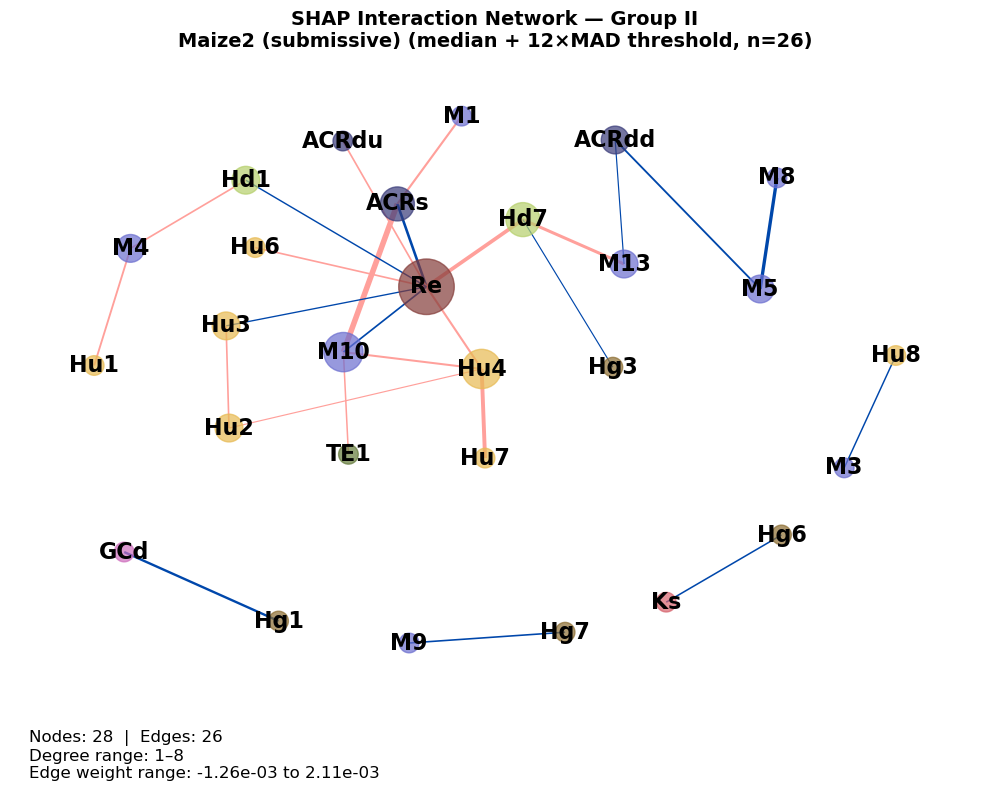


Group III (Group III)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 1,711
    Non-zero pairs  : 1,418 (82.9%)
    Median          : 0.00000146
    MAD             : 0.00000124
    K_INTERACTION   : 12
    Threshold       : 0.00001632
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,418
    Pairs above threshold: 146
    Saved edge tables: groupIII_interaction_all_*.csv
    Saved degree table: groupIII_interaction_all_node_degrees.csv
  Nodes: 51  |  Edges: 146  |  Degree range: 1–39
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_interaction_all_network.png


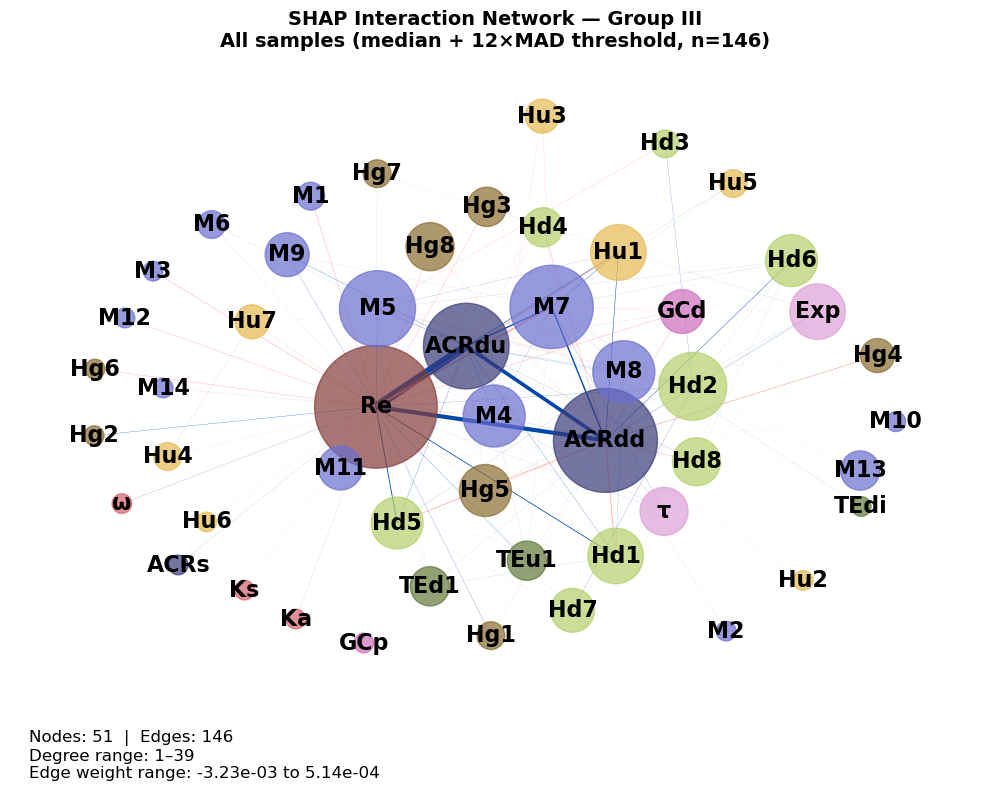


  --- Maize1 (dominant) ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,418
    Pairs above threshold: 164
    Saved edge tables: groupIII_interaction_label0_*.csv
    Saved degree table: groupIII_interaction_label0_node_degrees.csv
  Nodes: 51  |  Edges: 164  |  Degree range: 1–41
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_interaction_label0_network.png


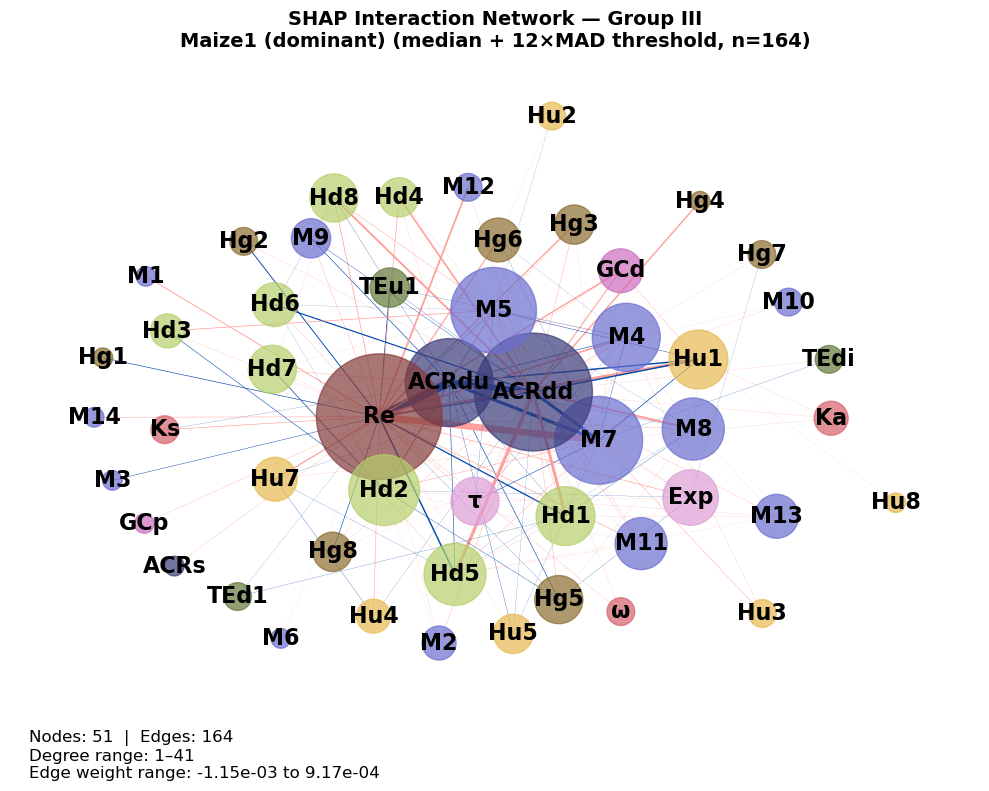


  --- Maize2 (submissive) ---
    Total pairs          : 1,711
    Non-zero pairs       : 1,418
    Pairs above threshold: 175
    Saved edge tables: groupIII_interaction_label1_*.csv
    Saved degree table: groupIII_interaction_label1_node_degrees.csv
  Nodes: 49  |  Edges: 175  |  Degree range: 1–36
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIII_interaction_label1_network.png


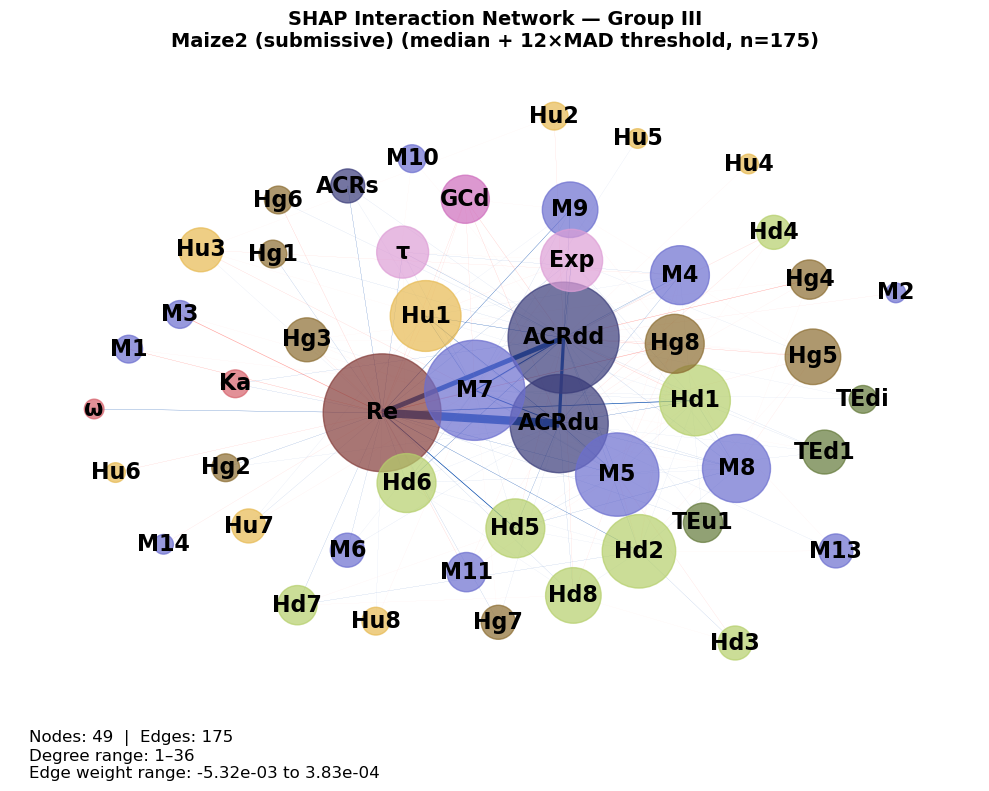


Group IV (Group IV)
  Threshold computation (all-samples, non-zero pairs):
    Total pairs     : 1,711
    Non-zero pairs  : 254 (14.8%)
    Median          : 0.00005605
    MAD             : 0.00004228
    K_INTERACTION   : 12
    Threshold       : 0.00056340
    Saved diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_interaction_threshold_diagnostics.csv

  --- All samples ---
    Total pairs          : 1,711
    Non-zero pairs       : 254
    Pairs above threshold: 4
    Saved edge tables: groupIV_interaction_all_*.csv
    Saved degree table: groupIV_interaction_all_node_degrees.csv
  Nodes: 6  |  Edges: 4  |  Degree range: 1–3
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_interaction_all_network.png


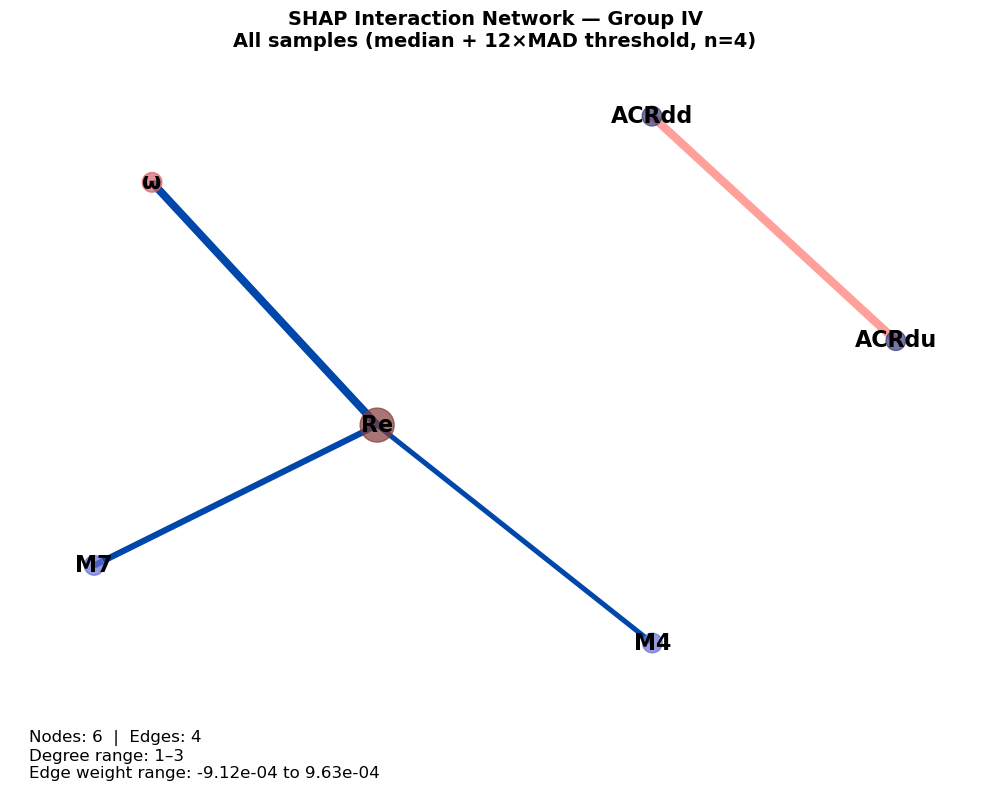


  --- Maize1 (dominant) ---
    Total pairs          : 1,711
    Non-zero pairs       : 254
    Pairs above threshold: 9
    Saved edge tables: groupIV_interaction_label0_*.csv
    Saved degree table: groupIV_interaction_label0_node_degrees.csv
  Nodes: 10  |  Edges: 9  |  Degree range: 1–6
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_interaction_label0_network.png


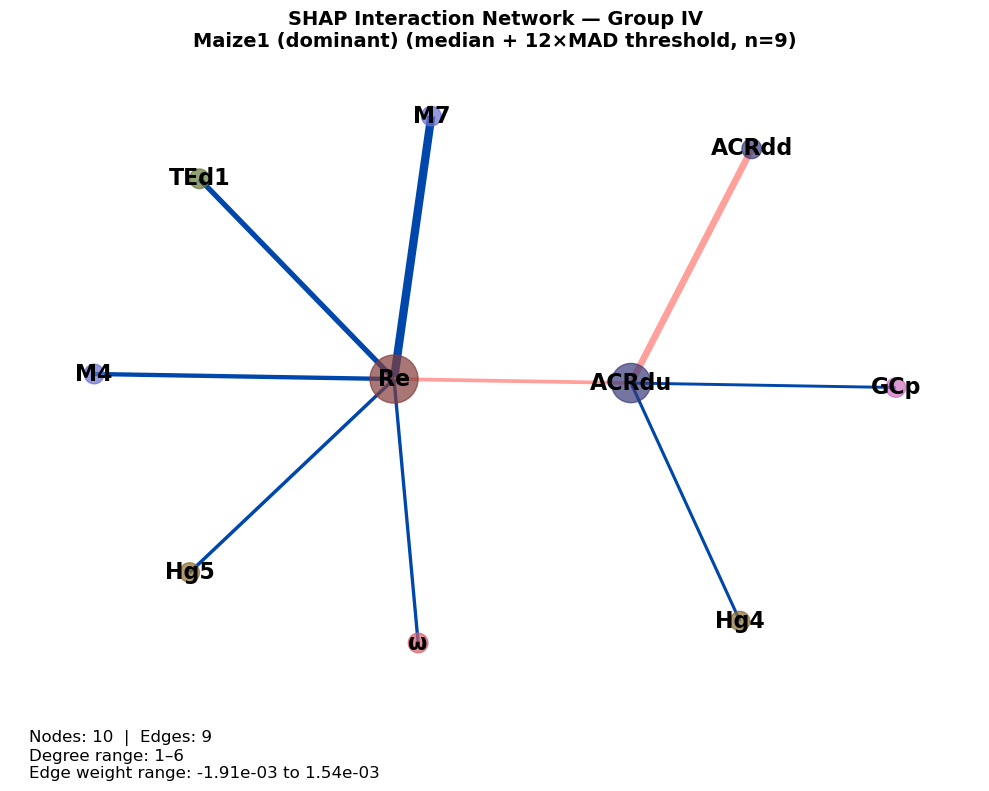


  --- Maize2 (submissive) ---
    Total pairs          : 1,711
    Non-zero pairs       : 254
    Pairs above threshold: 4
    Saved edge tables: groupIV_interaction_label1_*.csv
    Saved degree table: groupIV_interaction_label1_node_degrees.csv
  Nodes: 6  |  Edges: 4  |  Degree range: 1–3
  Saved: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/groupIV_interaction_label1_network.png


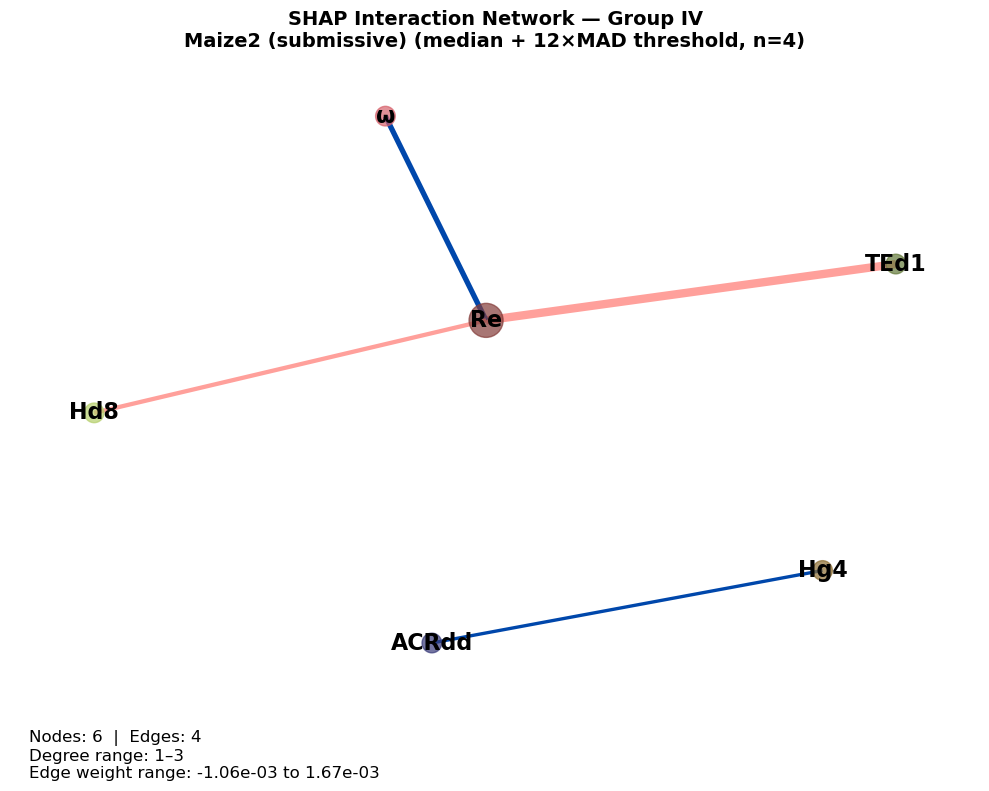


Saved combined threshold diagnostics: /blue/meixiazhao/laylaaschuster/maizeGDM/final_network/interaction_threshold_diagnostics_all_groups.csv


In [53]:
# ============================================================
# INDIVIDUAL NETWORK PLOTS — INTERACTION METHOD
# ============================================================
# Constructs and plots Shapley interaction networks for all
# 5 groups × 3 label subsets (all / Maize1 / Maize2),
# giving 15 individual networks total.
#
# For each group:
#   1. The group-specific threshold is computed ONCE from
#      the all-samples interaction array using
#      compute_interaction_threshold() at K_INTERACTION=12.
#   2. That same threshold is applied to all three label
#      subsets — ensuring Maize1 vs Maize2 comparisons
#      are not confounded by different noise floors.
#   3. Retained pairs become edges; edge weight is the
#      signed mean interaction value for that subset.
#   4. build_network_and_layout() and plot_single_network()
#      are reused from the co-variation network section.
#
# Threshold diagnostics are printed and saved per group
# for methods reporting. All edge tables are saved including
# the full all_edges table (not just significant) for
# supplemental reference.
# ============================================================

# Label subsets to analyse: key, shap_data key, display label
INTERACTION_LABELS = [
    ("all",    "shap_interaction_all",    "All samples"),
    ("label0", "shap_interaction_label0", "Maize1 (dominant)"),
    ("label1", "shap_interaction_label1", "Maize2 (submissive)"),
]

interaction_network_data = {
    group: {} for group in GROUPS
}

# Store threshold diagnostics for all groups — useful for
# methods section reporting and supplemental tables
threshold_diagnostics_all = {}

custom_thickness = {
    "All": 30.0,
    "I": 6.0,
    "II": 4.0,
    "III": 6.0,
    "IV": 6.0
}

for group in GROUPS:
    print(f"\n{'='*60}")
    print(f"Group {group} ({GROUP_LABELS[group]})")
    print(f"{'='*60}")

    # --- Step 1: Compute threshold from all-samples array ---
    # Done once per group. This threshold is shared across
    # all three label subsets for this group.
    interaction_array_all = shap_data[group]["shap_interaction_all"]
    feat_labels           = feature_names[group]

    threshold, diagnostics = compute_interaction_threshold(
        interaction_array_all = interaction_array_all,
        feature_labels        = feat_labels,
        k                     = K_INTERACTION,
    )
    threshold_diagnostics_all[group] = diagnostics

    print(f"  Threshold computation (all-samples, non-zero pairs):")
    print(f"    Total pairs     : {diagnostics['n_total_pairs']:,}")
    print(f"    Non-zero pairs  : {diagnostics['n_nonzero']:,} "
          f"({diagnostics['pct_nonzero']:.1f}%)")
    print(f"    Median          : {diagnostics['median']:.8f}")
    print(f"    MAD             : {diagnostics['mad']:.8f}")
    print(f"    K_INTERACTION   : {K_INTERACTION}")
    print(f"    Threshold       : {threshold:.8f}")

    # Save threshold diagnostics for this group
    diag_path = os.path.join(
        NETWORK_DIR,
        f"{PREFIXES[group]}_interaction_threshold_diagnostics.csv"
    )
    pd.DataFrame([diagnostics]).to_csv(diag_path, index=False)
    print(f"    Saved diagnostics: {diag_path}")

    # --- Step 2: Apply threshold to all three label subsets ---
    for label_key, data_key, label_display in INTERACTION_LABELS:
        print(f"\n  --- {label_display} ---")

        interaction_array = shap_data[group][data_key]

        # Filter pairs using the group threshold derived above
        sig_edges, all_edges = compute_interaction_significance(
            interaction_array = interaction_array,
            feature_labels    = feat_labels,
            threshold         = threshold,
        )

        n_total    = len(all_edges)
        n_nonzero  = (all_edges["abs_weight"] > 0).sum()
        n_retained = len(sig_edges)
        print(f"    Total pairs          : {n_total:,}")
        print(f"    Non-zero pairs       : {n_nonzero:,}")
        print(f"    Pairs above threshold: {n_retained:,}")

        # Save edge tables
        suffix = f"_interaction_{label_key}"
        
        all_edges_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}{suffix}_all_edges.csv"
        )
        sig_edges_path = os.path.join(
            NETWORK_DIR,
            f"{PREFIXES[group]}{suffix}_significant_edges.csv"
        )
        
        all_edges.assign(
            source=all_edges['source'].map(feature_rename_dict).fillna(all_edges['source']),
            target=all_edges['target'].map(feature_rename_dict).fillna(all_edges['target'])
        ).to_csv(all_edges_path, index=False)

        sig_edges.assign(
            source=sig_edges['source'].map(feature_rename_dict).fillna(sig_edges['source']),
            target=sig_edges['target'].map(feature_rename_dict).fillna(sig_edges['target'])
        ).to_csv(sig_edges_path, index=False)
        
        print(f"    Saved edge tables: {PREFIXES[group]}{suffix}_*.csv")

        # Build graph and layout
        Gx, layout = build_network_and_layout(sig_edges)

        # Save degree table
        if Gx.number_of_nodes() > 0:
            degree_df = pd.DataFrame(
                Gx.degree, columns=["node", "degree"]
            ).sort_values(
                by="degree", ascending=False
            ).reset_index(drop=True)
            degree_path = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}{suffix}_node_degrees.csv"
            )
            degree_df.assign(
                node=degree_df['node'].map(feature_rename_dict).fillna(degree_df['node'])
            ).to_csv(degree_path, index=False)
            print(f"    Saved degree table: "
                  f"{PREFIXES[group]}{suffix}_node_degrees.csv")

        # Store for combined figures
        interaction_network_data[group][label_key] = {
            "Gx"       : Gx,
            "layout"   : layout,
            "sig_edges": sig_edges,
        }
        
        thickness = custom_thickness.get(group, 8.0)

        # Plot individual network
        plot_single_network(
            Gx                  = Gx,
            layout              = layout,
            title               = (
                f"SHAP Interaction Network — {GROUP_LABELS[group]}\n"
                f"{label_display} "
                f"(median + {K_INTERACTION}×MAD threshold, "
                f"n={n_retained})"
            ),
            save_path           = os.path.join(
                NETWORK_DIR,
                f"{PREFIXES[group]}{suffix}_network.png"
            ),
            feature_rename_dict = feature_rename_dict,
            feature_to_group    = feature_to_group,
            group_to_color      = group_to_color,
            max_edge_thickness  = thickness,
        )

# --- Save combined threshold diagnostics table ---
# One row per group — useful for methods section and
# supplemental materials reporting the threshold values
# applied to each group's networks.
diag_combined_path = os.path.join(
    NETWORK_DIR, "interaction_threshold_diagnostics_all_groups.csv"
)
pd.DataFrame(threshold_diagnostics_all).T.to_csv(diag_combined_path)
print(f"\nSaved combined threshold diagnostics: {diag_combined_path}")

### Combined Interaction Networks

In [ ]:
# --- Calls ---
# K_INTERACTION is passed explicitly to both functions so
# that panel titles and empty-network annotations reflect
# the parameter value without hardcoding it in the functions.

plot_interaction_combined_all(
    interaction_network_data = interaction_network_data,
    group_labels             = GROUP_LABELS,
    feature_rename_dict      = feature_rename_dict,
    feature_to_group         = feature_to_group,
    group_to_color           = group_to_color,
    save_path                = os.path.join(
        NETWORK_DIR, "combined_interaction_all.png"
    ),
    k_interaction            = K_INTERACTION,
)


### Combined Interaction Networks by Label

In [ ]:
plot_interaction_combined_label(
    interaction_network_data = interaction_network_data,
    group_labels             = GROUP_LABELS,
    feature_rename_dict      = feature_rename_dict,
    feature_to_group         = feature_to_group,
    group_to_color           = group_to_color,
    save_path                = os.path.join(
        NETWORK_DIR, "combined_interaction_label.png"
    ),
    k_interaction            = K_INTERACTION,
)

## Interaction Heatmaps

In [ ]:
# ============================================================
# INTERACTION HEATMAPS — ALL 15
# ============================================================
# For each group × label subset (all / label0 / label1),
# computes the mean Shapley interaction value across samples
# for each feature pair and plots a clustered heatmap.
#
# METHODS NOTE:
# The diagonal is set to zero before plotting — main effects
# (diagonal entries) are orders of magnitude larger than
# off-diagonal interaction terms and would compress the
# colorscale, obscuring the interaction signal of interest.
# Features are clustered using Ward linkage with Euclidean
# distance, computed independently per heatmap so that each
# group's interaction structure determines its own feature
# ordering. The colorscale is symmetric around zero
# (vmin = -abs_max, vmax = abs_max): red = synergistic
# interaction (positive mean φ_jk), blue = antagonistic
# (negative mean φ_jk).
#
# These heatmaps are complementary to the interaction network
# figures and show the full pairwise interaction landscape
# regardless of the effect size threshold applied to the
# networks. The networks retain only pairs whose absolute
# mean interaction exceeds the group-specific robust
# threshold (median + K_INTERACTION × MAD of non-zero
# all-samples pairs). The heatmaps intentionally include
# all pairs — including those below the threshold — so that
# the global structure of feature relationships within each
# group is visible and the threshold decision can be
# visually evaluated by the reader.
#
# Resolution is 300 dpi (sufficient for heatmaps; 15 files
# at 600 dpi would be prohibitively large).
# ============================================================
def plot_interaction_heatmap(
    interaction_array,
    feature_labels,
    feature_rename_dict,
    title,
    save_path,
):
    """
    Plot a clustered heatmap of mean Shapley interaction values
    for one group × label subset combination.

    Averages the 3D interaction array across samples to produce
    a (n_features × n_features) mean interaction matrix, zeros
    the diagonal to suppress main effects, renames features to
    short display names, then calls plot_clustered_heatmap().

    All feature pairs are included regardless of whether they
    exceed the effect size threshold used in the network
    figures (median + K_INTERACTION × MAD). These heatmaps
    show the full interaction landscape so that the threshold
    decision can be evaluated in context. See
    compute_interaction_threshold() for threshold derivation.

    Parameters
    ----------
    interaction_array : np.ndarray, shape
                        (n_samples, n_features, n_features)
        Shapley interaction values for one group and label
        subset. Can be shap_interaction_all,
        shap_interaction_label0, or shap_interaction_label1.
    feature_labels    : list of str
        Original feature names corresponding to array axes
        1 and 2. Used for renaming via feature_rename_dict.
    feature_rename_dict : dict
        Maps original feature name -> short display name.
        Names not in the dict are displayed as-is.
    title             : str
        Panel title displayed above the heatmap.
    save_path         : str
        Full path for the saved .png file.
    """
    mean_matrix = interaction_array.mean(axis=0)
    np.fill_diagonal(mean_matrix, 0)
    short_labels = [feature_rename_dict.get(f, f) for f in feature_labels]
    matrix_df = pd.DataFrame(
        mean_matrix,
        index   = short_labels,
        columns = short_labels,
    )
    plot_clustered_heatmap(
        matrix_df      = matrix_df,
        title          = title,
        save_path      = save_path,
        colorbar_label = 'Mean Shapley interaction value',
    )

In [ ]:
# ============================================================
# RUN INTERACTION HEATMAPS — ALL 15
# ============================================================
# Generates one heatmap per group × label subset combination:
#   5 groups (All, I, II, III, IV)
#   × 3 label subsets (all samples, Maize1, Maize2)
#   = 15 heatmaps total
#
# Each heatmap shows the full pairwise mean Shapley interaction
# landscape for that group and label subset, including all
# pairs regardless of whether they exceed the effect size
# threshold used in the network figures. See the methods note
# in plot_interaction_heatmap() for full discussion.
#
# Titles include the label subset so each saved file is
# self-identifying when reviewed alongside the network figures.
# Resolution is 300 dpi — sufficient for heatmaps and keeps
# file sizes manageable across 15 outputs.
# ============================================================

from unittest.mock import patch

with patch('matplotlib.pyplot.show'):
    for group in GROUPS:
        for label_key, data_key, label_display in INTERACTION_LABELS:
            print(f"\n--- Group {group} ({GROUP_LABELS[group]}) "
                  f"— {label_display} ---")

            plot_interaction_heatmap(
                interaction_array   = shap_data[group][data_key],
                feature_labels      = feature_names[group],
                feature_rename_dict = feature_rename_dict,
                title               = (
                    f"SHAP Interaction Heatmap — {GROUP_LABELS[group]}\n"
                    f"{label_display}"
                ),
                save_path           = os.path.join(
                    NETWORK_DIR,
                    f"{PREFIXES[group]}_interaction_{label_key}_heatmap.png"
                ),
            )